# American Options and Numerical Pricing Methods

In [18]:
import json
import math
import os
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", str(min(8, max(1, (os.cpu_count() or 1) - 1))))
os.environ.setdefault("NUMBA_NUM_THREADS", str(min(8, max(1, (os.cpu_count() or 1) - 1))))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display
from numba import njit, prange

from quantfinlab.dataio import load_option_chain, load_par_yield_curve
from quantfinlab.fixed_income.bootstrap import build_zero_curve_panel_from_par_yields
from quantfinlab.options.rates_dividends import attach_rates, add_discount_factors
from quantfinlab.plotting.diagrams import tree_structure, overlay_payoffs

pd.set_option("display.max_columns", 80)
palette = ["#069AF3","#FE420F", "#00008B", "#008080" , "#CC79A7",
          "#9614fa", "#DC143C", "#7BC8F6", "#0072B2","#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})
project_root = Path.cwd()
data_dir = project_root / "../data"
cache_dir = data_dir / "cache" / "project13"
cache_dir.mkdir(parents=True, exist_ok=True)
ann_days = 365.25
spy_option_path = data_dir / "spy_options_chain_202201_202312.parquet"
spy_underlying_path = data_dir / "spy_yfinance.csv"
rates_path = data_dir / "par-yield-curve-rates-1990-2026.csv"


In [19]:
option_columns = [
    "quote_date", "quote_readtime", "expire_date", "underlying_last", "strike",
    "c_bid", "c_ask", "p_bid", "p_ask", "c_iv", "p_iv",
    "c_delta", "p_delta", "c_gamma", "p_gamma", "c_vega", "p_vega",
    "c_theta", "p_theta", "c_volume", "p_volume",
]
raw_quotes = load_option_chain(spy_option_path, source="optionsdx_spy", columns=option_columns)
raw_quotes["date"] = pd.to_datetime(raw_quotes["date"]).dt.normalize()
raw_quotes["expiry"] = pd.to_datetime(raw_quotes["expiry"]).dt.normalize()
raw_quotes["dte_days"] = pd.to_numeric(raw_quotes["dte_calendar"], errors="coerce")
raw_quotes["moneyness"] = pd.to_numeric(raw_quotes["strike"], errors="coerce") / pd.to_numeric(raw_quotes["spot"], errors="coerce")
raw_quotes["log_moneyness"] = np.log(raw_quotes["moneyness"].where(raw_quotes["moneyness"] > 0.0))
raw_quotes["relative_spread"] = pd.to_numeric(raw_quotes["rel_spread"], errors="coerce")
raw_quotes["iv_mid"] = pd.to_numeric(raw_quotes["iv"], errors="coerce")

cleaning_rows = []
def record_step(name, frame):
    removed = np.nan if not cleaning_rows else cleaning_rows[-1]["rows"] - len(frame)
    cleaning_rows.append({"step": name, "rows": len(frame), "removed": removed})

quotes = raw_quotes.copy()
record_step("raw rows", quotes)
quotes = quotes[quotes["date"].notna() & quotes["expiry"].notna() & quotes["spot"].gt(0) & quotes["strike"].gt(0)].copy()
record_step("after schema normalization", quotes)
quotes = quotes[quotes["bid"].gt(0) & quotes["ask"].gt(0) & quotes["mid"].gt(0) & quotes["ask"].ge(quotes["bid"])].copy()
record_step("after positive quote filter", quotes)
quotes = quotes[quotes["relative_spread"].le(0.35)].copy()
record_step("after spread filter", quotes)
quotes = quotes[quotes["dte_days"].between(7, 180)].copy()
record_step("after DTE filter", quotes)
quotes = quotes[quotes["moneyness"].between(0.65, 1.45)].copy()
record_step("after moneyness filter", quotes)
quotes = quotes[quotes["iv_mid"].between(0.03, 2.50)].copy()
record_step("after IV/sigma filter", quotes)

quotes["m_bucket_for_sigma"] = pd.cut(quotes["moneyness"], np.linspace(0.65, 1.45, 17), include_lowest=True)
sigma_smooth = quotes.groupby(["date", "expiry", "m_bucket_for_sigma"], observed=True)["iv_mid"].median().rename("sigma_smooth").reset_index()
quotes = quotes.merge(sigma_smooth, on=["date", "expiry", "m_bucket_for_sigma"], how="left")
quotes["sigma_used"] = (0.75 * quotes["iv_mid"] + 0.25 * quotes["sigma_smooth"].fillna(quotes["iv_mid"])).clip(0.03, 2.50)


In [20]:
par_yields = load_par_yield_curve(rates_path, source="us_treasury")
zero_curve = build_zero_curve_panel_from_par_yields(par_yields, method="pchip")
quotes = attach_rates(quotes, curve_panel=zero_curve)
quotes = add_discount_factors(quotes)


In [21]:
underlying_raw = pd.read_csv(spy_underlying_path)
underlying_raw["date"] = pd.to_datetime(underlying_raw["Date"], errors="coerce").dt.normalize()
underlying_raw = underlying_raw.rename(columns={"Close": "close", "Adj Close": "adj_close", "Dividends": "dividend", "Stock Splits": "split", "Volume": "volume"})
underlying = underlying_raw.set_index("date").sort_index()
underlying_2022_2023 = underlying.loc["2022-01-01":"2023-12-31"].copy()
dividend_events = underlying_2022_2023.loc[pd.to_numeric(underlying_2022_2023["dividend"], errors="coerce").fillna(0.0) > 0.0, ["dividend", "close"]].reset_index()


In [22]:
div_dates = dividend_events["date"].to_numpy("datetime64[ns]")
div_amt = dividend_events["dividend"].to_numpy(float)
q_dates = quotes["date"].to_numpy("datetime64[ns]")
q_exp = quotes["expiry"].to_numpy("datetime64[ns]")
q_rate = pd.to_numeric(quotes["rate"], errors="coerce").fillna(0.0).to_numpy(float)
next_dividend = np.zeros(len(quotes), dtype=float)
days_to_next_dividend = np.full(len(quotes), np.nan, dtype=float)
dividend_in_life = np.zeros(len(quotes), dtype=float)
pv_dividends = np.zeros(len(quotes), dtype=float)
for ex_date, amount in zip(div_dates, div_amt):
    days = (ex_date - q_dates).astype("timedelta64[D]").astype(float)
    inside = (ex_date > q_dates) & (ex_date <= q_exp)
    dividend_in_life[inside] += amount
    pv_dividends[inside] += amount * np.exp(-q_rate[inside] * days[inside] / ann_days)
    is_next = (ex_date > q_dates) & (np.isnan(days_to_next_dividend) | (days < days_to_next_dividend))
    next_dividend[is_next] = amount
    days_to_next_dividend[is_next] = days[is_next]

quotes["next_dividend"] = next_dividend
quotes["days_to_next_dividend"] = days_to_next_dividend
quotes["dividend_in_life"] = dividend_in_life
quotes["pv_dividends"] = pv_dividends
spot = pd.to_numeric(quotes["spot"], errors="coerce")
tau = pd.to_numeric(quotes["tau"], errors="coerce")
adjusted_spot_ratio = ((spot - quotes["pv_dividends"]).clip(lower=1e-6) / spot).clip(lower=1e-8, upper=1.0)
quotes["dividend_yield"] = (-np.log(adjusted_spot_ratio) / tau.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0.0)


In [23]:
intrinsic = np.where(quotes["option_type"].astype(str).str.startswith("c"), np.maximum(quotes["spot"] - quotes["strike"], 0.0), np.maximum(quotes["strike"] - quotes["spot"], 0.0))
quotes["time_value"] = quotes["mid"] - intrinsic
spy_quotes = quotes.dropna(subset=["date", "expiry", "spot", "strike", "tau", "rate", "sigma_used", "mid"]).sort_values(["date", "expiry", "option_type", "strike"]).reset_index(drop=True)
record_step("final rows", spy_quotes)
cleaning_steps = pd.DataFrame(cleaning_rows)

coverage_summary = pd.DataFrame([{
    "dates": spy_quotes["date"].nunique(),
    "expiries": spy_quotes["expiry"].nunique(),
    "listed_contracts": spy_quotes[["expiry", "option_type", "strike"]].drop_duplicates().shape[0],
    "quote_rows": len(spy_quotes),
    "first_date": spy_quotes["date"].min(),
    "last_date": spy_quotes["date"].max(),
}])
dte_counts = spy_quotes.assign(dte_bucket=pd.cut(spy_quotes["dte_days"], [0, 14, 30, 60, 90, 120, 180], include_lowest=True)).groupby(["option_type", "dte_bucket"], observed=True).size().rename("rows").reset_index()
moneyness_counts = spy_quotes.assign(moneyness_bucket=pd.cut(spy_quotes["moneyness"], np.linspace(0.65, 1.45, 9), include_lowest=True)).groupby(["option_type", "moneyness_bucket"], observed=True).size().rename("rows").reset_index()
type_counts = spy_quotes.groupby("option_type").size().rename("rows").reset_index()
rows_per_date = spy_quotes.groupby("date").size().rename("rows").describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).reset_index().rename(columns={"index": "statistic"})

display(cleaning_steps)
display(coverage_summary)
display(rows_per_date)
display(dte_counts)
display(moneyness_counts)
display(type_counts)
display(dividend_events)


,step,rows,removed
0,raw rows,4238284,NaN
1,after schema normalization,4238284,0.0
2,after positive quote filter,3943422,294862.0
3,after spread filter,3650579,292843.0
4,after DTE filter,2146155,1504424.0
5,after moneyness filter,1988763,157392.0
6,after IV/sigma filter,1839734,149029.0
7,final rows,1839734,0.0


,dates,expiries,listed_contracts,quote_rows,first_date,last_date
0,506,435,107727,1839734,2022-01-03,2023-12-29


,statistic,rows
0,count,506.000000
1,mean,3635.837945
2,std,766.723843
3,min,2135.000000
4,5%,2627.000000
5,25%,2972.750000
6,50%,3411.000000
7,75%,4362.000000
8,95%,4828.250000
9,max,5307.000000


,option_type,dte_bucket,rows
0,call,"(-0.001, 14.0]",153852
1,call,"(14.0, 30.0]",221275
2,call,"(30.0, 60.0]",206104
3,call,"(60.0, 90.0]",95812
4,call,"(90.0, 120.0]",82832
5,call,"(120.0, 180.0]",133245
6,put,"(-0.001, 14.0]",181203
7,put,"(14.0, 30.0]",235624
8,put,"(30.0, 60.0]",212650
9,put,"(60.0, 90.0]",95996


,option_type,moneyness_bucket,rows
0,call,"(0.649, 0.75]",43876
1,call,"(0.75, 0.85]",95669
2,call,"(0.85, 0.95]",218632
3,call,"(0.95, 1.05]",307505
4,call,"(1.05, 1.15]",161983
5,call,"(1.15, 1.25]",48595
6,call,"(1.25, 1.35]",13855
7,call,"(1.35, 1.45]",3005
8,put,"(0.649, 0.75]",45939
9,put,"(0.75, 0.85]",103725


,option_type,rows
0,call,893120
1,put,946614


,date,dividend,close
0,2022-03-18,1.366,444.519989
1,2022-06-17,1.577,365.859985
2,2022-09-16,1.596,385.559998
3,2022-12-16,1.781,383.269989
4,2023-03-17,1.506,389.989990
5,2023-06-16,1.638,439.459992
6,2023-09-15,1.583,443.369995
7,2023-12-15,1.906,469.329987


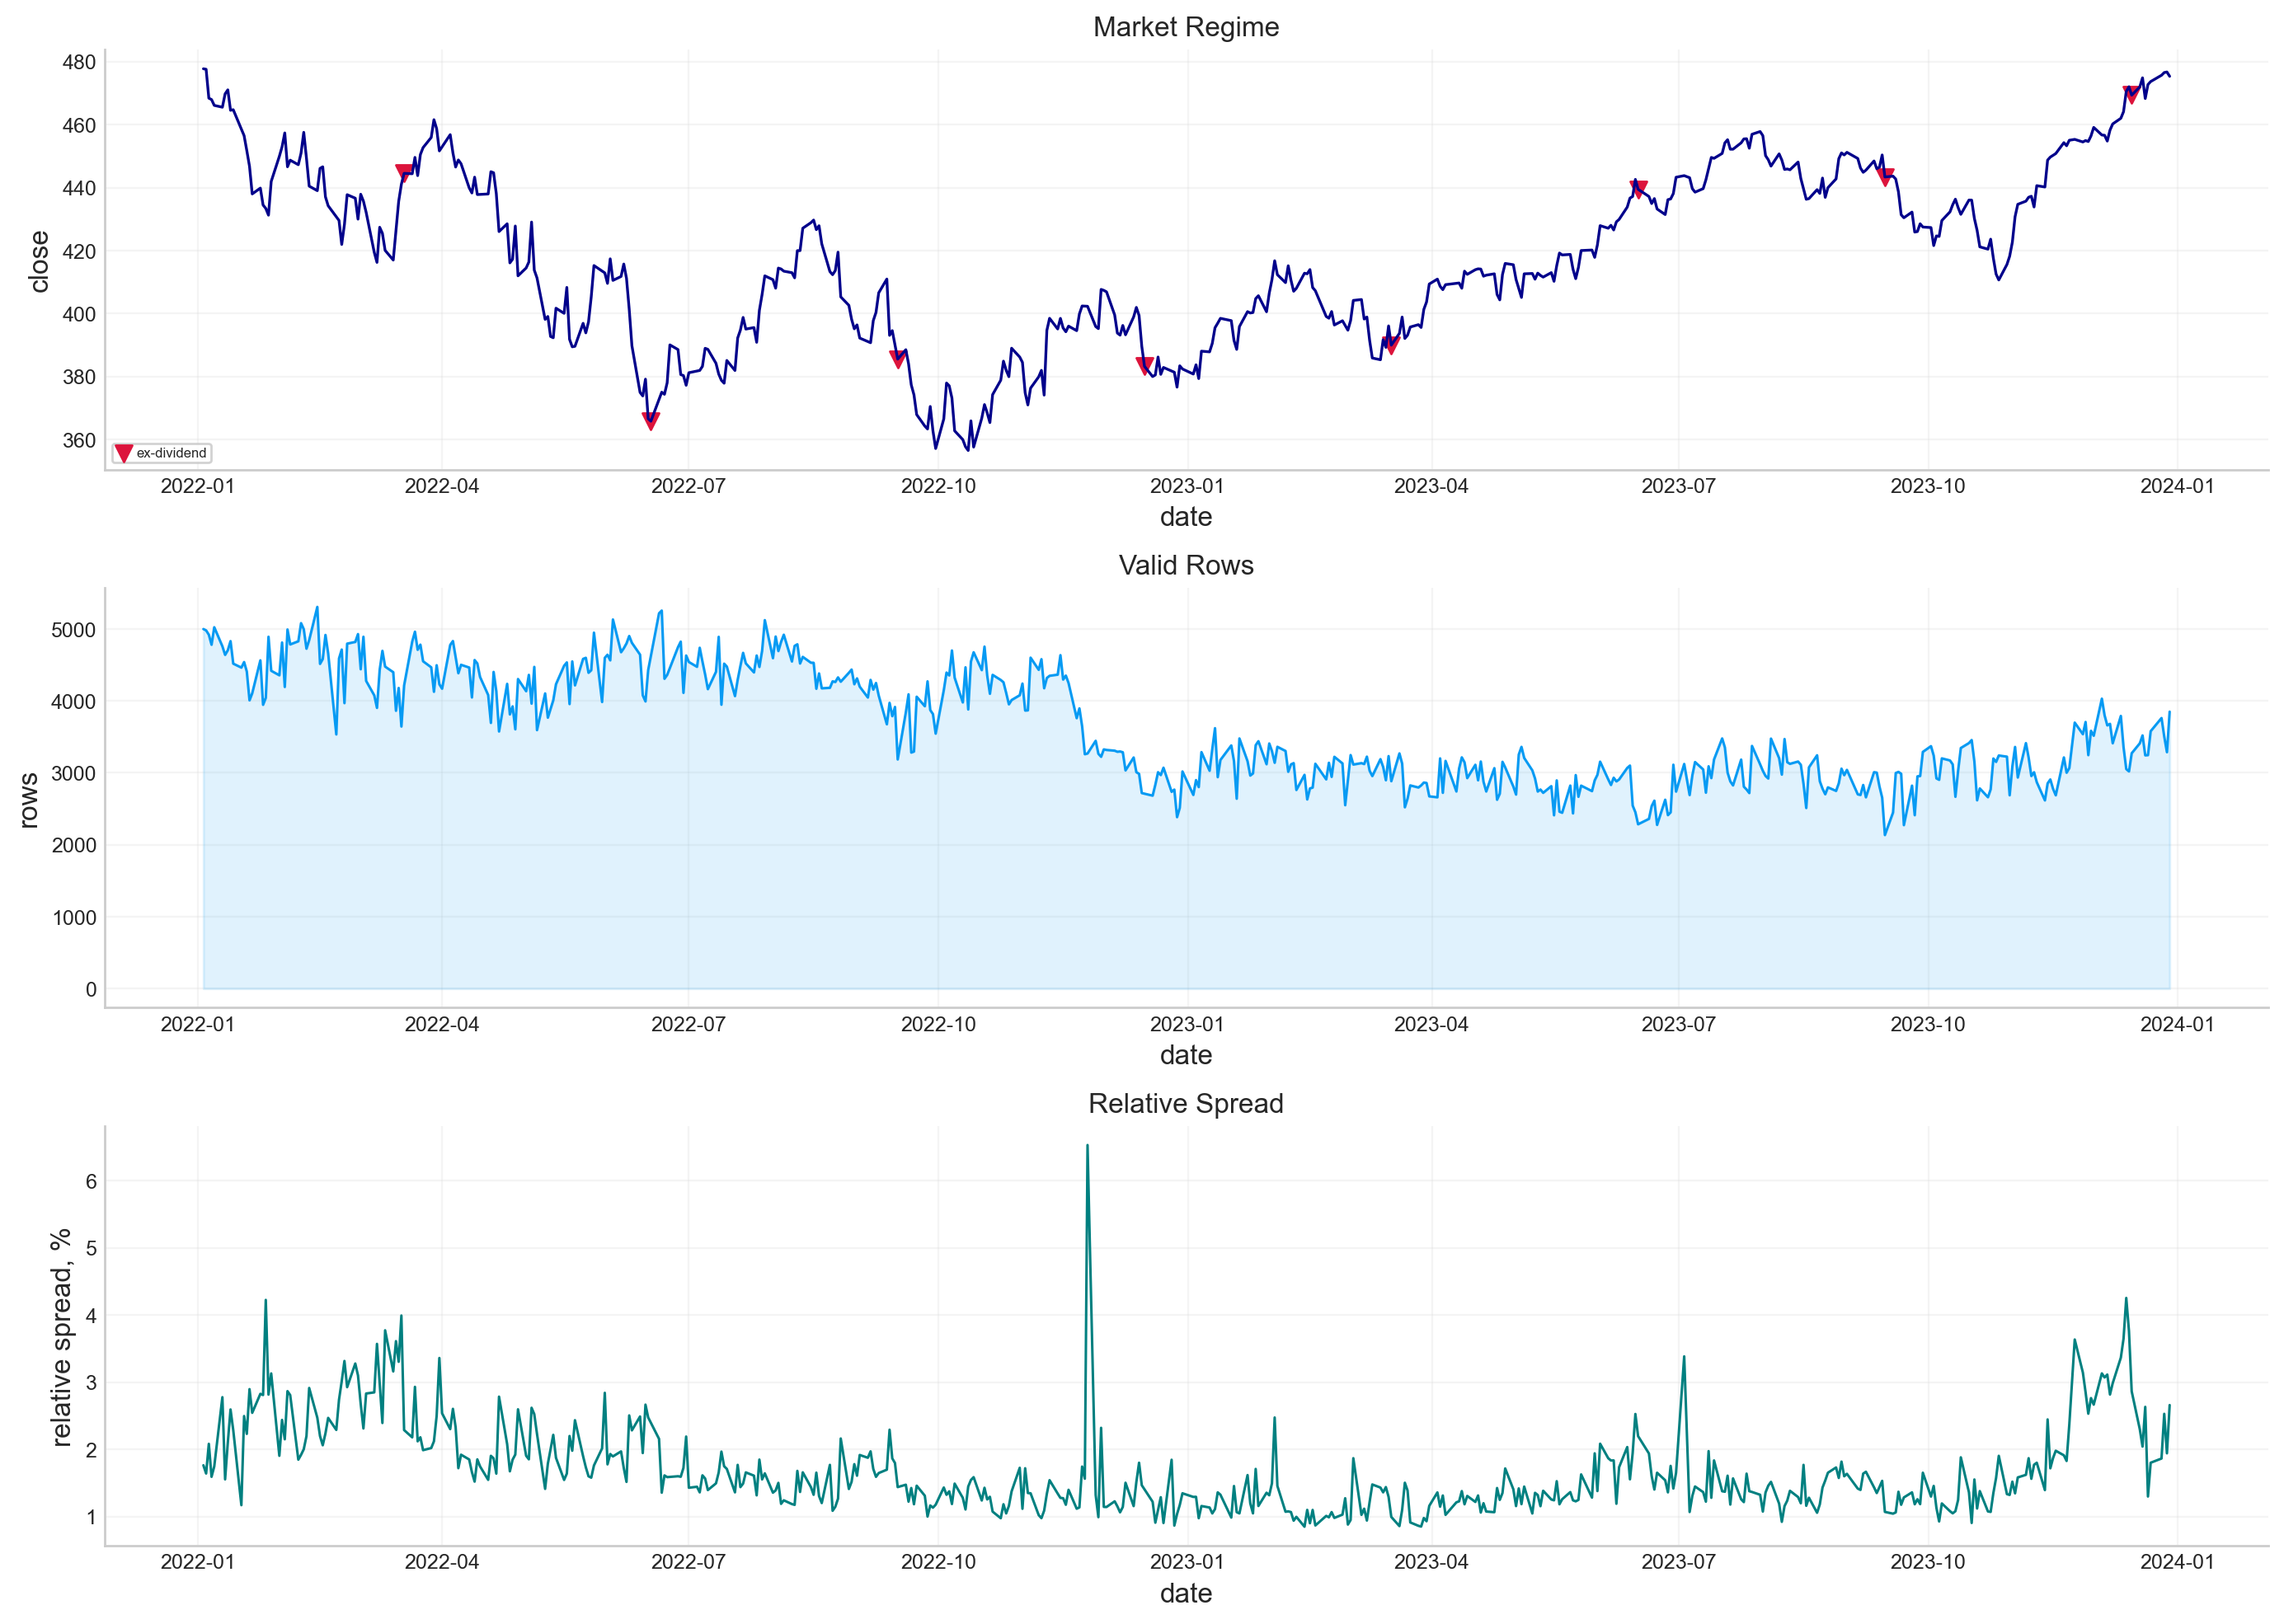

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
date_counts = spy_quotes.groupby("date").size()
spread_by_date = spy_quotes.groupby("date")["relative_spread"].median()
axes[0].plot(underlying_2022_2023.index, underlying_2022_2023["close"], lw=1.2, color=palette[2])
axes[0].scatter(dividend_events["date"], dividend_events["close"], marker="v", s=52, color=palette[6], label="ex-dividend")
axes[0].set_title("Market Regime")
axes[0].set_xlabel("date")
axes[0].set_ylabel("close")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
axes[1].plot(date_counts.index, date_counts.values, lw=1.1, color=palette[0])
axes[1].fill_between(date_counts.index, date_counts.values, 0, color=palette[0], alpha=0.12)
axes[1].set_title("Valid Rows")
axes[1].set_xlabel("date")
axes[1].set_ylabel("rows")
axes[2].plot(spread_by_date.index, spread_by_date.values * 100.0, lw=1.1, color=palette[3])
axes[2].set_title("Relative Spread")
axes[2].set_xlabel("date")
axes[2].set_ylabel("relative spread, %")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


In [25]:
def choose_contracts(q):
    data = q.copy()
    div = pd.to_numeric(data["dividend_in_life"], errors="coerce").fillna(0.0)
    tv = pd.to_numeric(data["time_value"], errors="coerce").fillna(np.inf)
    specs = [
        ("atm_put_30_60", data["option_type"].eq("put") & data["dte_days"].between(30, 60), 1.00, 45.0),
        ("itm_put_30_90", data["option_type"].eq("put") & data["dte_days"].between(30, 90) & data["moneyness"].between(1.08, 1.25), 1.15, 60.0),
        ("otm_put_60_120", data["option_type"].eq("put") & data["dte_days"].between(60, 120) & data["moneyness"].between(0.80, 0.95), 0.90, 90.0),
        ("atm_call_30_60", data["option_type"].eq("call") & data["dte_days"].between(30, 60), 1.00, 45.0),
        ("dividend_call", data["option_type"].eq("call") & data["dte_days"].between(7, 45) & (div > 0.0) & data["moneyness"].between(0.92, 1.03), 0.97, 21.0),
    ]
    rows = []
    for label, mask, m0, d0 in specs:
        sub = data.loc[mask].copy()
        if sub.empty:
            continue
        score = (sub["moneyness"] - m0).abs() + (sub["dte_days"] - d0).abs() / ann_days + 0.1 * sub["relative_spread"]
        if label == "dividend_call":
            score = score + 0.03 * tv.loc[sub.index] / sub["spot"] - 0.05 * div.loc[sub.index]
        row = sub.loc[score.idxmin()].copy()
        row["contract_role"] = label
        rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)

representative_contracts = choose_contracts(spy_quotes)
display(representative_contracts[["contract_role", "date", "expiry", "option_type", "spot", "strike", "moneyness", "dte_days", "sigma_used", "mid", "dividend_in_life", "days_to_next_dividend", "time_value"]].round(6))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3660\4035844165.py:26: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(representative_contracts[["contract_role", "date", "expiry", "option_type", "spot", "strike", "moneyness", "dte_days", "sigma_used", "mid", "dividend_in_life", "days_to_next_dividend", "time_value"]].round(6))


,contract_role,date,expiry,option_type,spot,strike,moneyness,dte_days,sigma_used,mid,dividend_in_life,days_to_next_dividend,time_value
0,atm_put_30_60,2023-05-15,2023-06-30,put,413.02,413.0,0.999952,45.333333,0.154856,8.205,1.638,32.0,8.205
1,itm_put_30_90,2022-03-21,2022-05-20,put,444.38,511.0,1.149917,59.333333,0.180359,66.675,0.000,88.0,0.055
2,otm_put_60_120,2023-09-15,2023-12-15,put,443.35,399.0,0.899966,90.333333,0.202299,2.355,1.906,91.0,2.355
3,atm_call_30_60,2023-04-03,2023-05-19,call,410.93,411.0,1.000170,45.333333,0.165052,11.150,0.000,74.0,11.150
4,dividend_call,2023-11-29,2023-12-22,call,454.63,441.0,0.970020,22.333333,0.129889,15.620,1.906,16.0,1.990


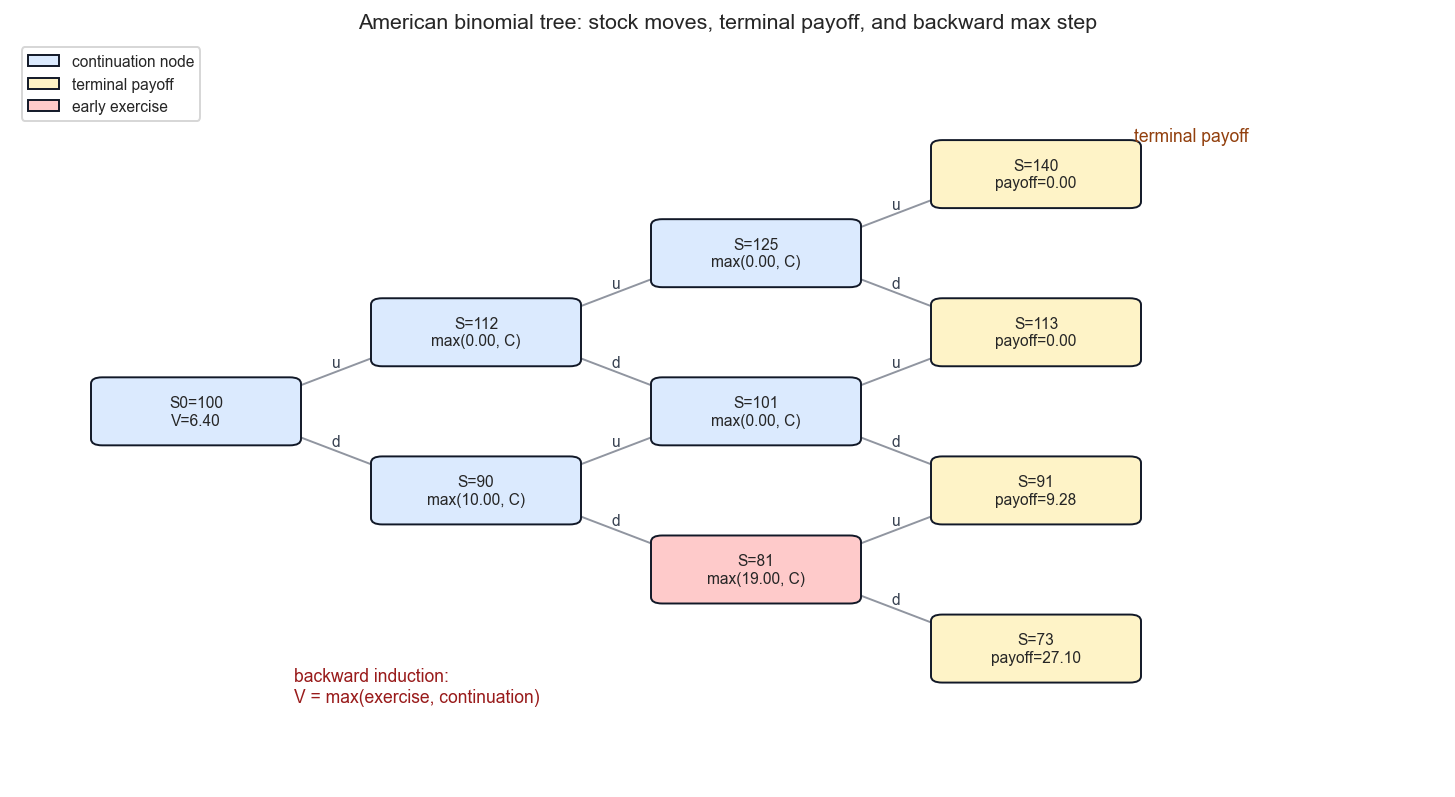

In [26]:
tree_structure()
plt.show()


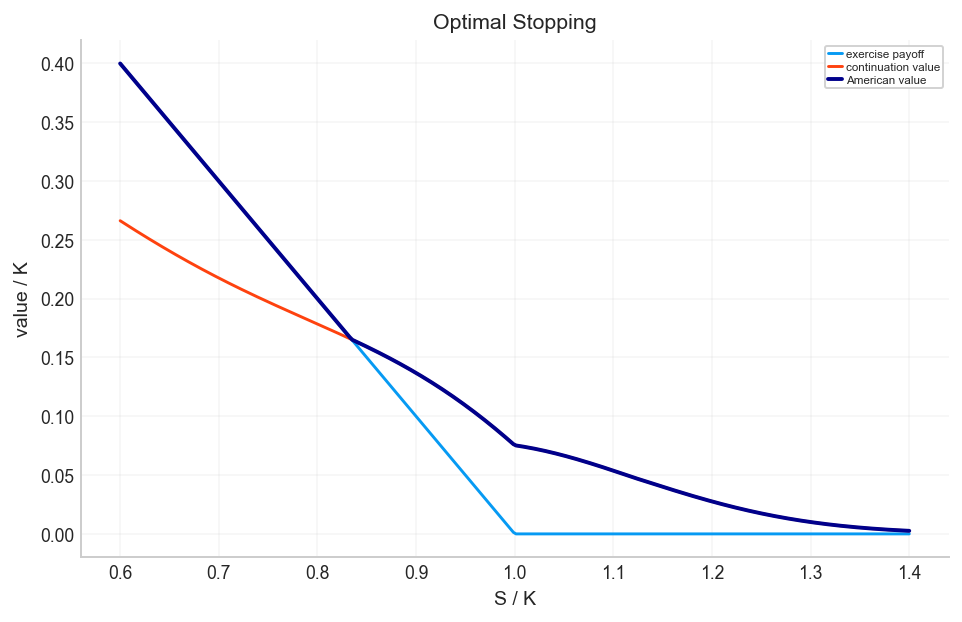

In [27]:
s_demo = np.linspace(60, 140, 300)
k_demo = 100.0
payoff_demo = np.maximum(k_demo - s_demo, 0.0)
continuation_demo = 0.62 * payoff_demo + 7.5 * np.exp(-((s_demo - 96.0) / 24.0) ** 2) + 0.02 * np.maximum(112.0 - s_demo, 0.0)
value_demo = np.maximum(payoff_demo, continuation_demo)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(s_demo / k_demo, payoff_demo / k_demo, label="exercise payoff")
ax.plot(s_demo / k_demo, continuation_demo / k_demo, label="continuation value")
ax.plot(s_demo / k_demo, value_demo / k_demo, lw=2.0, label="American value")
ax.fill_between(s_demo / k_demo, payoff_demo / k_demo, value_demo / k_demo, where=payoff_demo >= continuation_demo, color=palette[6], alpha=0.18)
ax.set_xlabel("S / K")
ax.set_ylabel("value / K")
ax.set_title("Optimal Stopping")
ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
plt.show()


In [28]:
@njit
def payoff(s, k, flag):
    if flag > 0:
        return max(s - k, 0.0)
    return max(k - s, 0.0)

@njit
def crr_params(r, q, sigma, dt):
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    p = (math.exp((r - q) * dt) - d) / (u - d)
    if p < 1e-10:
        p = 1e-10
    if p > 1.0 - 1e-10:
        p = 1.0 - 1e-10
    return u, d, p

@njit
def tree_price_one(s, k, r, q, sigma, tau, flag, steps, american):
    if tau <= 0.0 or sigma <= 0.0:
        return payoff(s, k, flag)
    n = max(2, steps)
    dt = tau / n
    u, d, p = crr_params(r, q, sigma, dt)
    disc = math.exp(-r * dt)
    values = np.empty(n + 1)
    for j in range(n + 1):
        st = s * (u ** j) * (d ** (n - j))
        values[j] = payoff(st, k, flag)
    for i in range(n - 1, -1, -1):
        for j in range(i + 1):
            cont = disc * (p * values[j + 1] + (1.0 - p) * values[j])
            if american:
                st = s * (u ** j) * (d ** (i - j))
                ex = payoff(st, k, flag)
                values[j] = max(ex, cont)
            else:
                values[j] = cont
    return values[0]

@njit(parallel=True)
def tree_batch_numba(s, k, r, q, sigma, tau, flag, steps, american):
    out = np.empty(s.size)
    for i in prange(s.size):
        out[i] = tree_price_one(s[i], k[i], r[i], q[i], sigma[i], tau[i], flag[i], steps, american)
    return out

@njit
def tree_boundary_one(s, k, r, q, sigma, tau, flag, steps):
    n = max(2, steps)
    dt = tau / n
    u, d, p = crr_params(r, q, sigma, dt)
    disc = math.exp(-r * dt)
    values = np.empty(n + 1)
    exercise = np.zeros((n + 1, n + 1))
    boundary = np.empty(n + 1)
    for i in range(n + 1):
        boundary[i] = np.nan
    for j in range(n + 1):
        st = s * (u ** j) * (d ** (n - j))
        values[j] = payoff(st, k, flag)
    boundary[n] = k
    for i in range(n - 1, -1, -1):
        level = np.nan
        for j in range(i + 1):
            st = s * (u ** j) * (d ** (i - j))
            ex = payoff(st, k, flag)
            cont = disc * (p * values[j + 1] + (1.0 - p) * values[j])
            bind = ex > cont + 1e-10
            if bind:
                exercise[i, j] = 1.0
                if flag > 0:
                    if math.isnan(level) or st < level:
                        level = st
                else:
                    if math.isnan(level) or st > level:
                        level = st
            values[j] = max(ex, cont)
        boundary[i] = level
    return boundary, exercise

def option_flag(values):
    text = np.asarray(values).astype(str)
    return np.where(np.char.startswith(np.char.lower(text), "c"), 1, -1).astype(np.int32)


,steps,american_price,european_price,american_premium,richardson_price,abs_error,richardson_abs_error,runtime_sec
0,50,66.841839,66.710480,0.131359,66.843863,0.005046,0.003022,0.000024
1,100,66.846807,66.717721,0.129086,66.851776,0.000078,0.004891,0.000059
2,200,66.846881,66.718556,0.128324,66.846954,0.000004,0.000070,0.000244
3,300,66.846743,66.718645,0.128098,66.848038,0.000142,0.001154,0.000590
4,600,66.846912,66.719093,0.127819,66.847081,0.000027,0.000196,0.002610
5,800,66.846436,66.718549,0.127887,66.846683,0.000449,0.000202,0.004783
6,1200,66.846758,66.719023,0.127734,66.846603,0.000127,0.000281,0.011693
7,1600,66.846885,66.719220,0.127665,66.847334,0.000000,0.000449,0.033811


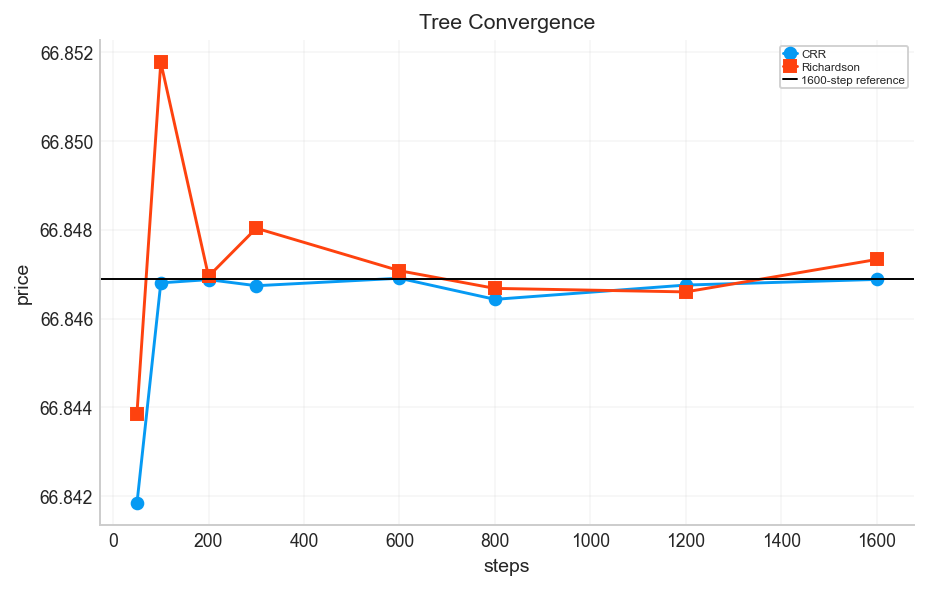

In [29]:
put_row = representative_contracts.loc[representative_contracts["contract_role"].eq("itm_put_30_90")].iloc[0]
s0 = float(put_row["spot"])
k0 = float(put_row["strike"])
r0 = float(put_row["rate"])
q0 = float(put_row["dividend_yield"])
sigma0 = float(put_row["sigma_used"])
tau0 = float(put_row["tau"])
flag0 = int(option_flag([put_row["option_type"]])[0])

steps_list = [50, 100, 200, 300, 600, 800, 1200, 1600]
ref = tree_price_one(s0, k0, r0, q0, sigma0, tau0, flag0, 1600, True)
tree_rows = []
for n in steps_list:
    t0 = time.perf_counter()
    american_price = tree_price_one(s0, k0, r0, q0, sigma0, tau0, flag0, n, True)
    european_price = tree_price_one(s0, k0, r0, q0, sigma0, tau0, flag0, n, False)
    elapsed = time.perf_counter() - t0
    richardson = 2.0 * tree_price_one(s0, k0, r0, q0, sigma0, tau0, flag0, n, True) - tree_price_one(s0, k0, r0, q0, sigma0, tau0, flag0, max(2, n // 2), True)
    tree_rows.append({"steps": n, "american_price": american_price, "european_price": european_price, "american_premium": american_price - european_price, "richardson_price": richardson, "abs_error": abs(american_price - ref), "richardson_abs_error": abs(richardson - ref), "runtime_sec": elapsed})
tree_convergence = pd.DataFrame(tree_rows)
boundary_values, exercise_map = tree_boundary_one(s0, k0, r0, q0, sigma0, tau0, flag0, 300)
dt_tree = tau0 / 300
u_tree, d_tree, _ = crr_params(r0, q0, sigma0, dt_tree)
exercise_rows = []
for i in range(exercise_map.shape[0]):
    for j in range(i + 1):
        st = s0 * (u_tree ** j) * (d_tree ** (i - j))
        exercise_rows.append({"time_to_expiry": tau0 - i * dt_tree, "s_over_k": st / k0, "exercise": exercise_map[i, j]})
tree_exercise_df = pd.DataFrame(exercise_rows)
tree_boundary_df = pd.DataFrame({"time_to_expiry": tau0 - np.linspace(0.0, tau0, len(boundary_values)), "boundary": boundary_values, "boundary_over_k": boundary_values / k0})
display(tree_convergence.round(8))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(tree_convergence["steps"], tree_convergence["american_price"], marker="o", label="CRR")
ax.plot(tree_convergence["steps"], tree_convergence["richardson_price"], marker="s", label="Richardson")
ax.axhline(ref, color="black", lw=1.0, label="1600-step reference")
ax.set_xlabel("steps")
ax.set_ylabel("price")
ax.set_title("Tree Convergence")
ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
plt.show()


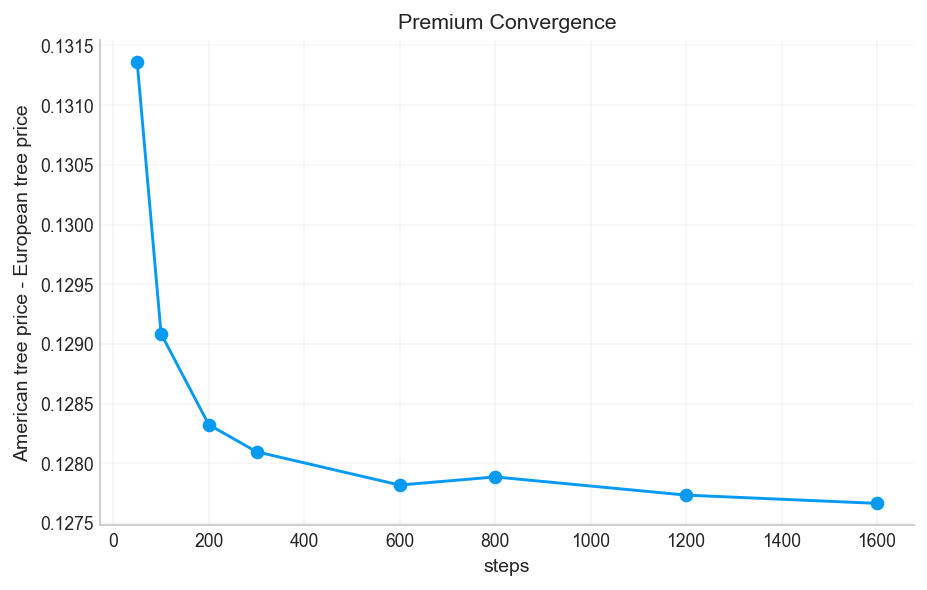

In [30]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(tree_convergence["steps"], tree_convergence["american_premium"], marker="o")
ax.set_xlabel("steps")
ax.set_ylabel("American tree price - European tree price")
ax.set_title("Premium Convergence")
plt.show()


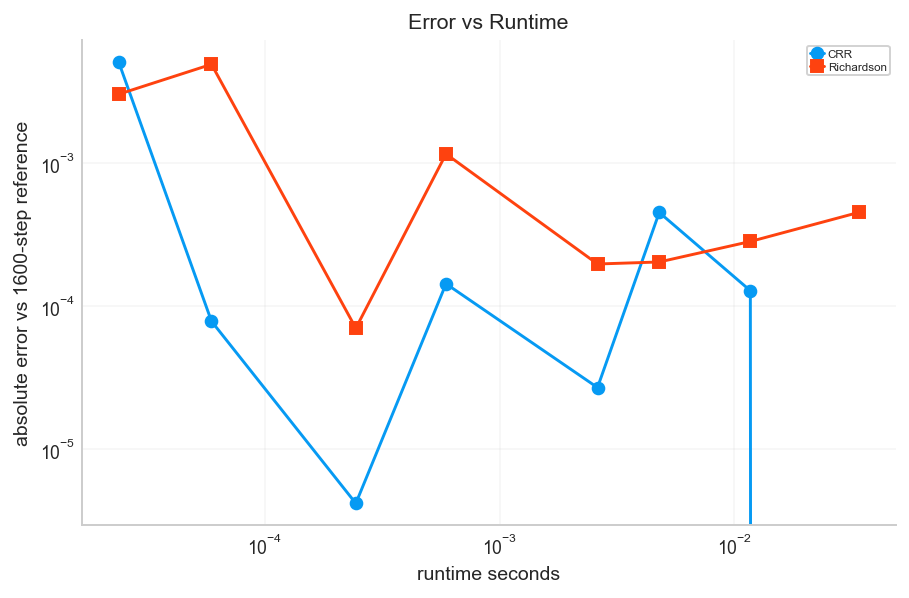

In [31]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(tree_convergence["runtime_sec"], tree_convergence["abs_error"], marker="o", label="CRR")
ax.loglog(tree_convergence["runtime_sec"], tree_convergence["richardson_abs_error"], marker="s", label="Richardson")
ax.set_xlabel("runtime seconds")
ax.set_ylabel("absolute error vs 1600-step reference")
ax.set_title("Error vs Runtime")
ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
plt.show()


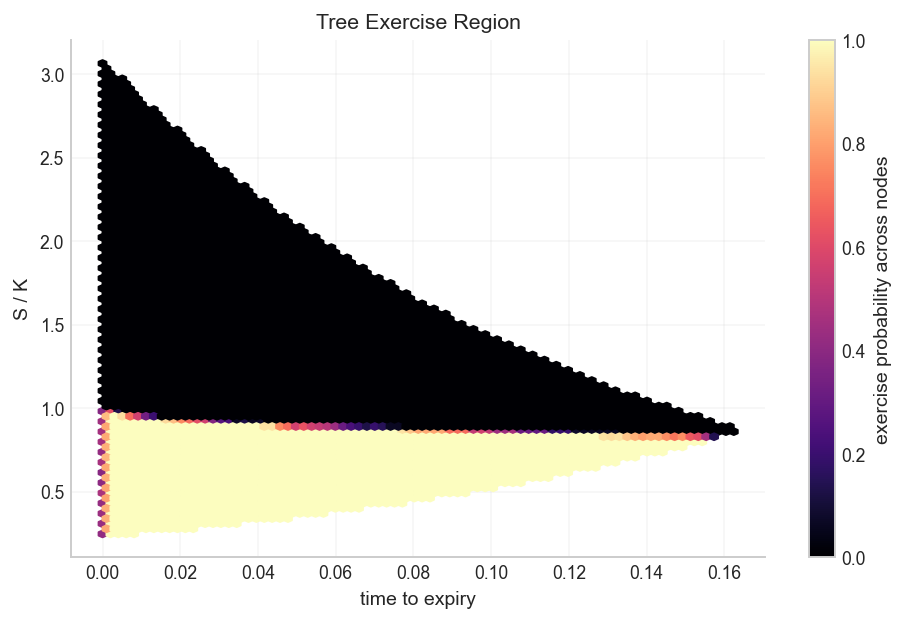

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.8))
hb = ax.hexbin(tree_exercise_df["time_to_expiry"], tree_exercise_df["s_over_k"], C=tree_exercise_df["exercise"], reduce_C_function=np.mean, gridsize=80, mincnt=1, cmap="magma", vmin=0, vmax=1)
ax.set_xlabel("time to expiry")
ax.set_ylabel("S / K")
ax.set_title("Tree Exercise Region")
fig.colorbar(hb, ax=ax, label="exercise probability across nodes")
plt.show()


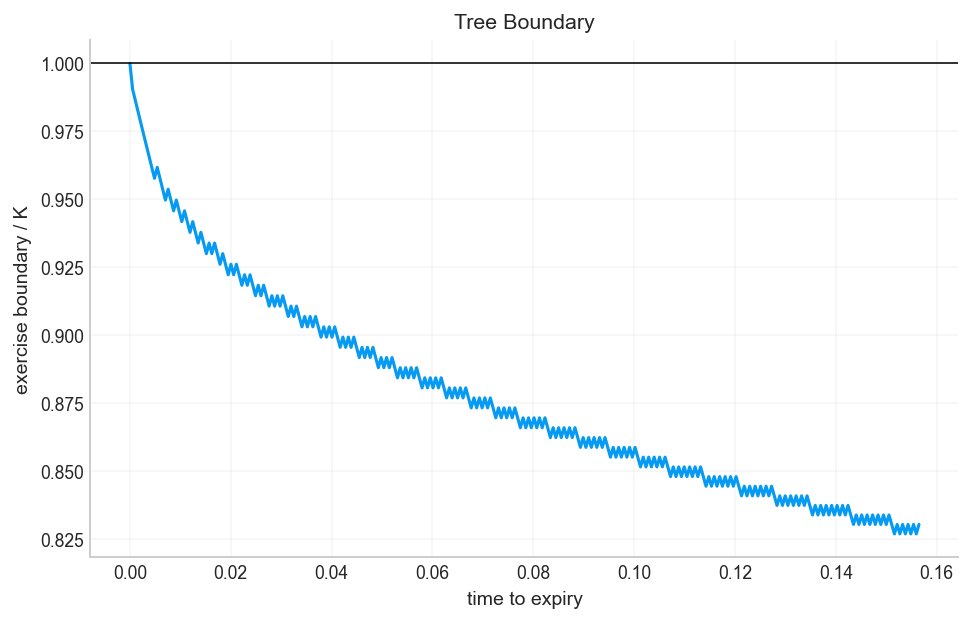

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(tree_boundary_df["time_to_expiry"], tree_boundary_df["boundary_over_k"], lw=1.6)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_xlabel("time to expiry")
ax.set_ylabel("exercise boundary / K")
ax.set_title("Tree Boundary")
plt.show()


,rows,steps,repeats,numba_median_sec,cpp_median_sec,max_abs_diff,mean_abs_diff,cpp_rows_per_sec,numba_rows_per_sec
0,1839734,120,3,33.434059,4.865987,0.0,0.0,378080.304935,55025.745513


,run,numba_sec,cpp_sec,numba_rows_per_sec,cpp_rows_per_sec
0,1,33.397450,5.149794,55086.062785,357244.213492
1,2,33.841510,4.757478,54363.236316,386703.643683
2,3,33.434059,4.865987,55025.745513,378080.304935


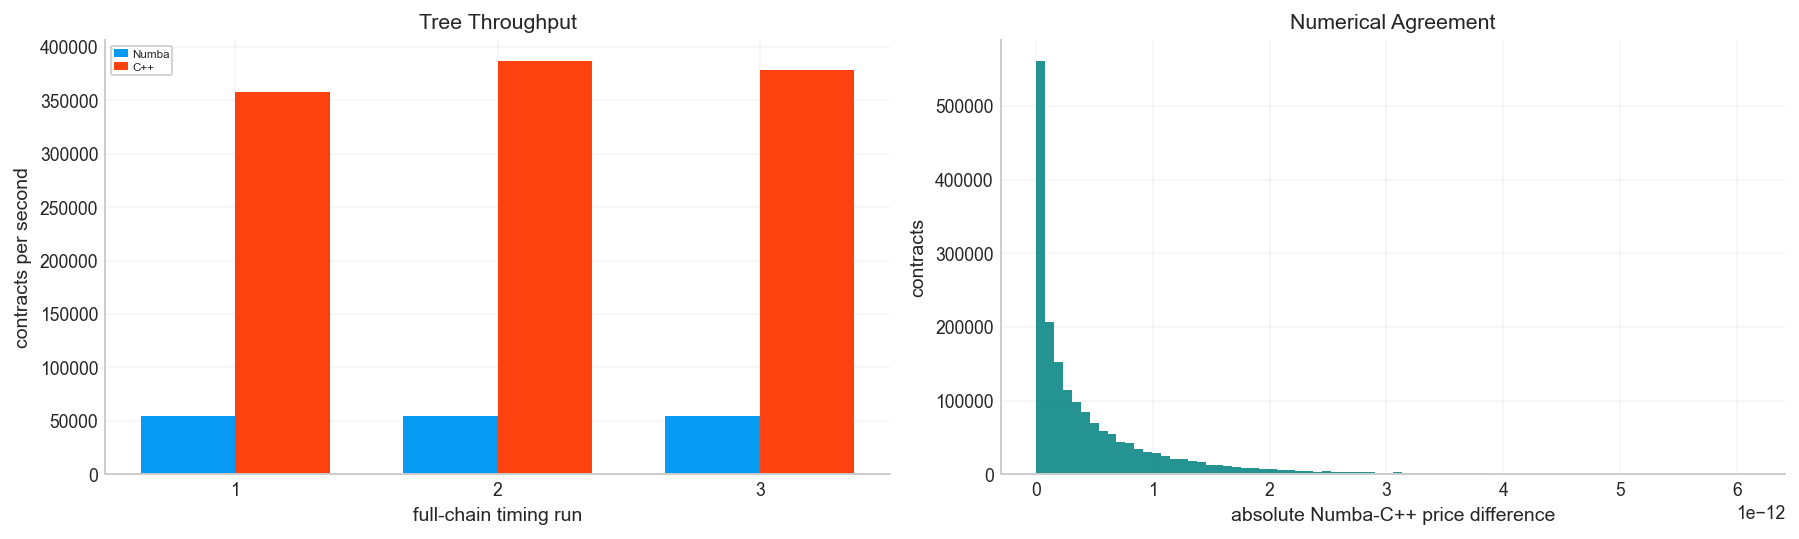

In [34]:
from quantfinlab import _kernels

tree_arrays = (
    spy_quotes["spot"].to_numpy(float),
    spy_quotes["strike"].to_numpy(float),
    spy_quotes["rate"].to_numpy(float),
    spy_quotes["dividend_yield"].to_numpy(float),
    spy_quotes["sigma_used"].to_numpy(float),
    spy_quotes["tau"].to_numpy(float),
    option_flag(spy_quotes["option_type"].to_numpy()),
)
_ = tree_batch_numba(*(arr[:32] for arr in tree_arrays), 64, True)
_ = _kernels.american_tree_batch(*(arr[:32] for arr in tree_arrays), 64, 0, True)

speed_steps = 120
speed_repeats = 3
full_rows = len(spy_quotes)
numba_times = []
cpp_times = []
for _i in range(speed_repeats):
    t0 = time.perf_counter()
    px_numba = tree_batch_numba(*tree_arrays, speed_steps, True)
    numba_times.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    px_cpp = _kernels.american_tree_batch(*tree_arrays, speed_steps, 0, True)
    cpp_times.append(time.perf_counter() - t0)
diff = np.abs(px_numba - px_cpp)
tree_cpp_speed = pd.DataFrame([{"rows": full_rows, "steps": speed_steps, "repeats": speed_repeats, "numba_median_sec": float(np.median(numba_times)), "cpp_median_sec": float(np.median(cpp_times)), "max_abs_diff": float(np.max(diff)), "mean_abs_diff": float(np.mean(diff)), "cpp_rows_per_sec": full_rows / max(float(np.median(cpp_times)), 1e-12), "numba_rows_per_sec": full_rows / max(float(np.median(numba_times)), 1e-12)}])
tree_cpp_speed_runs = pd.DataFrame({"run": np.arange(1, speed_repeats + 1), "numba_sec": numba_times, "cpp_sec": cpp_times, "numba_rows_per_sec": full_rows / np.maximum(numba_times, 1e-12), "cpp_rows_per_sec": full_rows / np.maximum(cpp_times, 1e-12)})
display(tree_cpp_speed.round(8))
display(tree_cpp_speed_runs.round(8))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(speed_repeats)
width = 0.36
axes[0].bar(x - width / 2, tree_cpp_speed_runs["numba_rows_per_sec"], width=width, label="Numba")
axes[0].bar(x + width / 2, tree_cpp_speed_runs["cpp_rows_per_sec"], width=width, label="C++")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tree_cpp_speed_runs["run"].astype(str))
axes[0].set_xlabel("full-chain timing run")
axes[0].set_ylabel("contracts per second")
axes[0].set_title("Tree Throughput")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
axes[1].hist(diff, bins=80, color=palette[3], alpha=0.85)
axes[1].set_xlabel("absolute Numba-C++ price difference")
axes[1].set_ylabel("contracts")
axes[1].set_title("Numerical Agreement")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


In [35]:
tree_cache = cache_dir / "spy_tree_full_chain.parquet"
tree_meta = cache_dir / "spy_tree_full_chain.meta.json"
tree_settings = {
    "dataset": "SPY OptionsDX 2022-2023",
    "rows": int(len(spy_quotes)),
    "first_date": str(spy_quotes["date"].min().date()),
    "last_date": str(spy_quotes["date"].max().date()),
    "steps": 300,
    "tree_type": "crr",
    "engine": "cpp",
    "filters": {"min_dte": 7, "max_dte": 180, "moneyness": [0.65, 1.45], "max_rel_spread": 0.35, "sigma": [0.03, 2.50]},
}
use_tree_cache = tree_cache.exists() and tree_meta.exists() and json.loads(tree_meta.read_text()).get("settings") == tree_settings
if use_tree_cache:
    tree_full_chain = pd.read_parquet(tree_cache)
else:
    s = spy_quotes["spot"].to_numpy(float)
    k = spy_quotes["strike"].to_numpy(float)
    r = spy_quotes["rate"].to_numpy(float)
    qy = spy_quotes["dividend_yield"].to_numpy(float)
    sigma = spy_quotes["sigma_used"].to_numpy(float)
    tau = spy_quotes["tau"].to_numpy(float)
    flag = option_flag(spy_quotes["option_type"].to_numpy())
    american_price = np.empty(len(spy_quotes), dtype=float)
    european_price = np.empty(len(spy_quotes), dtype=float)
    chunk_size = 25000
    t0 = time.perf_counter()
    for start in range(0, len(spy_quotes), chunk_size):
        stop = min(start + chunk_size, len(spy_quotes))
        sl = slice(start, stop)
        american_price[sl] = _kernels.american_tree_batch(s[sl], k[sl], r[sl], qy[sl], sigma[sl], tau[sl], flag[sl], 300, 0, True)
        european_price[sl] = _kernels.american_tree_batch(s[sl], k[sl], r[sl], qy[sl], sigma[sl], tau[sl], flag[sl], 300, 0, False)
    tree_elapsed = time.perf_counter() - t0
    keep_cols = ["date", "expiry", "option_type", "spot", "strike", "tau", "dte_days", "moneyness", "log_moneyness", "mid", "bid", "ask", "sigma_used", "rate", "dividend_yield", "relative_spread", "rel_spread", "next_dividend", "days_to_next_dividend", "dividend_in_life", "pv_dividends", "time_value"]
    tree_full_chain = spy_quotes[keep_cols].copy()
    tree_full_chain["european_tree_price"] = european_price
    tree_full_chain["american_tree_price"] = american_price
    tree_full_chain["american_premium"] = tree_full_chain["american_tree_price"] - tree_full_chain["european_tree_price"]
    tree_full_chain["pricing_error"] = tree_full_chain["american_tree_price"] - tree_full_chain["mid"]
    tree_full_chain["abs_pricing_error"] = tree_full_chain["pricing_error"].abs()
    tree_full_chain["tree_runtime_sec_total"] = tree_elapsed
    tree_full_chain["tree_contracts_per_sec"] = len(tree_full_chain) / max(tree_elapsed, 1e-12)
    tree_full_chain["tree_steps"] = 300
    tree_full_chain.to_parquet(tree_cache, index=False)
    tree_meta.write_text(json.dumps({"settings": tree_settings, "rows": len(tree_full_chain), "created_utc": pd.Timestamp.now("UTC").isoformat()}, indent=2))

tree_scan_summary = pd.DataFrame([{
    "rows": len(tree_full_chain),
    "dates": tree_full_chain["date"].nunique(),
    "expiries": tree_full_chain["expiry"].nunique(),
    "contracts": tree_full_chain[["expiry", "option_type", "strike"]].drop_duplicates().shape[0],
    "median_american_premium": tree_full_chain["american_premium"].median(),
    "median_abs_pricing_error": tree_full_chain["abs_pricing_error"].median(),
    "contracts_per_sec": tree_full_chain["tree_contracts_per_sec"].median(),
}])
display(tree_scan_summary.round(6))
display(tree_full_chain.groupby("option_type")[["american_premium", "pricing_error", "abs_pricing_error"]].agg(["count", "median", "mean"]).round(6))


,rows,dates,expiries,contracts,median_american_premium,median_abs_pricing_error,contracts_per_sec
0,1839734,506,435,107727,0.000111,0.152524,43640.275095


american_premium                    pricing_error            \
                       count   median      mean         count    median   
option_type                                                               
call                  893120  0.00000  0.049432        893120 -0.121000   
put                   946614  0.00478  0.225202        946614 -0.019968   

                      abs_pricing_error                      
                 mean             count    median      mean  
option_type                                                  
call        -0.207166            893120  0.186928  0.323945  
put          0.055380            946614  0.127333  0.236060

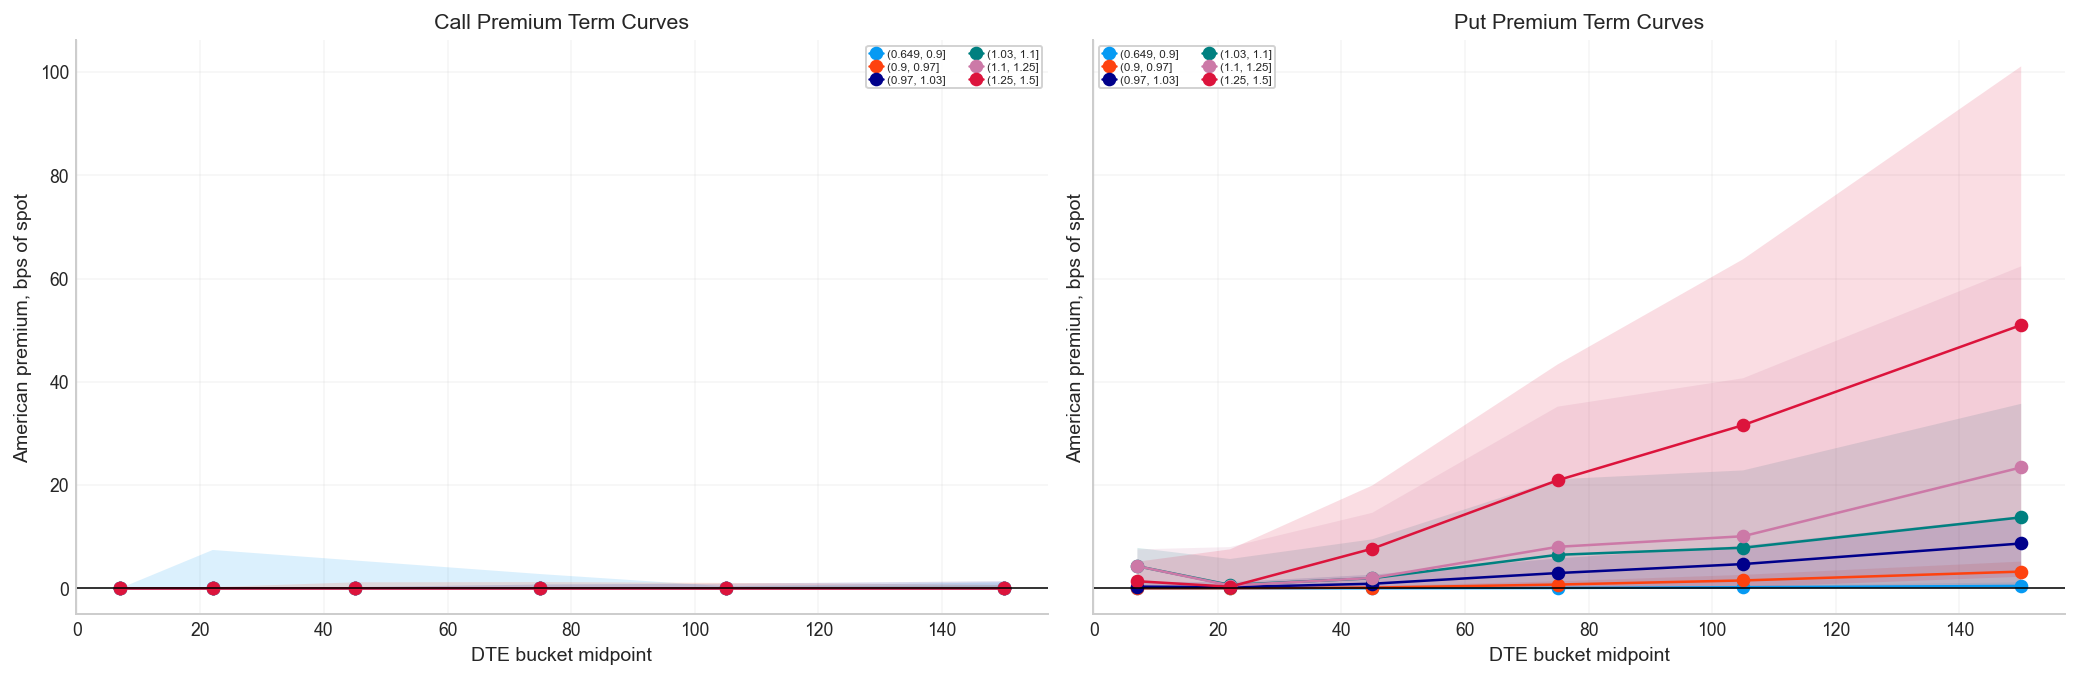

In [36]:
def premium_term_plot(ax, data, opt):
    subset = data[data["option_type"].eq(opt)].copy()
    subset["dte_bucket"] = pd.cut(subset["dte_days"], [0, 14, 30, 60, 90, 120, 180, 365], include_lowest=True)
    subset["m_bucket"] = pd.cut(subset["moneyness"], [0.65, 0.90, 0.97, 1.03, 1.10, 1.25, 1.50], include_lowest=True)
    subset["premium_bps"] = subset["american_premium"] / subset["spot"] * 10000.0
    rows = []
    for (dte_bucket, m_bucket), part in subset.groupby(["dte_bucket", "m_bucket"], observed=True):
        values = part["premium_bps"].replace([np.inf, -np.inf], np.nan).dropna()
        if len(values):
            rows.append({"dte_mid": 0.5 * (dte_bucket.left + dte_bucket.right), "m_bucket": str(m_bucket), "median": values.median(), "q25": values.quantile(0.25), "q75": values.quantile(0.75), "rows": len(values)})
    term = pd.DataFrame(rows)
    for label, part in term.groupby("m_bucket", sort=False):
        part = part.sort_values("dte_mid")
        ax.plot(part["dte_mid"], part["median"], marker="o", lw=1.3, label=label)
        ax.fill_between(part["dte_mid"].to_numpy(float), part["q25"].to_numpy(float), part["q75"].to_numpy(float), alpha=0.14)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_xlabel("DTE bucket midpoint")
    ax.set_ylabel("American premium, bps of spot")
    ax.set_title(f"{opt.title()} Premium Term Curves")
    ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35, ncol=2)
    return term

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
call_premium_terms = premium_term_plot(axes[0], tree_full_chain, "call")
put_premium_terms = premium_term_plot(axes[1], tree_full_chain, "put")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


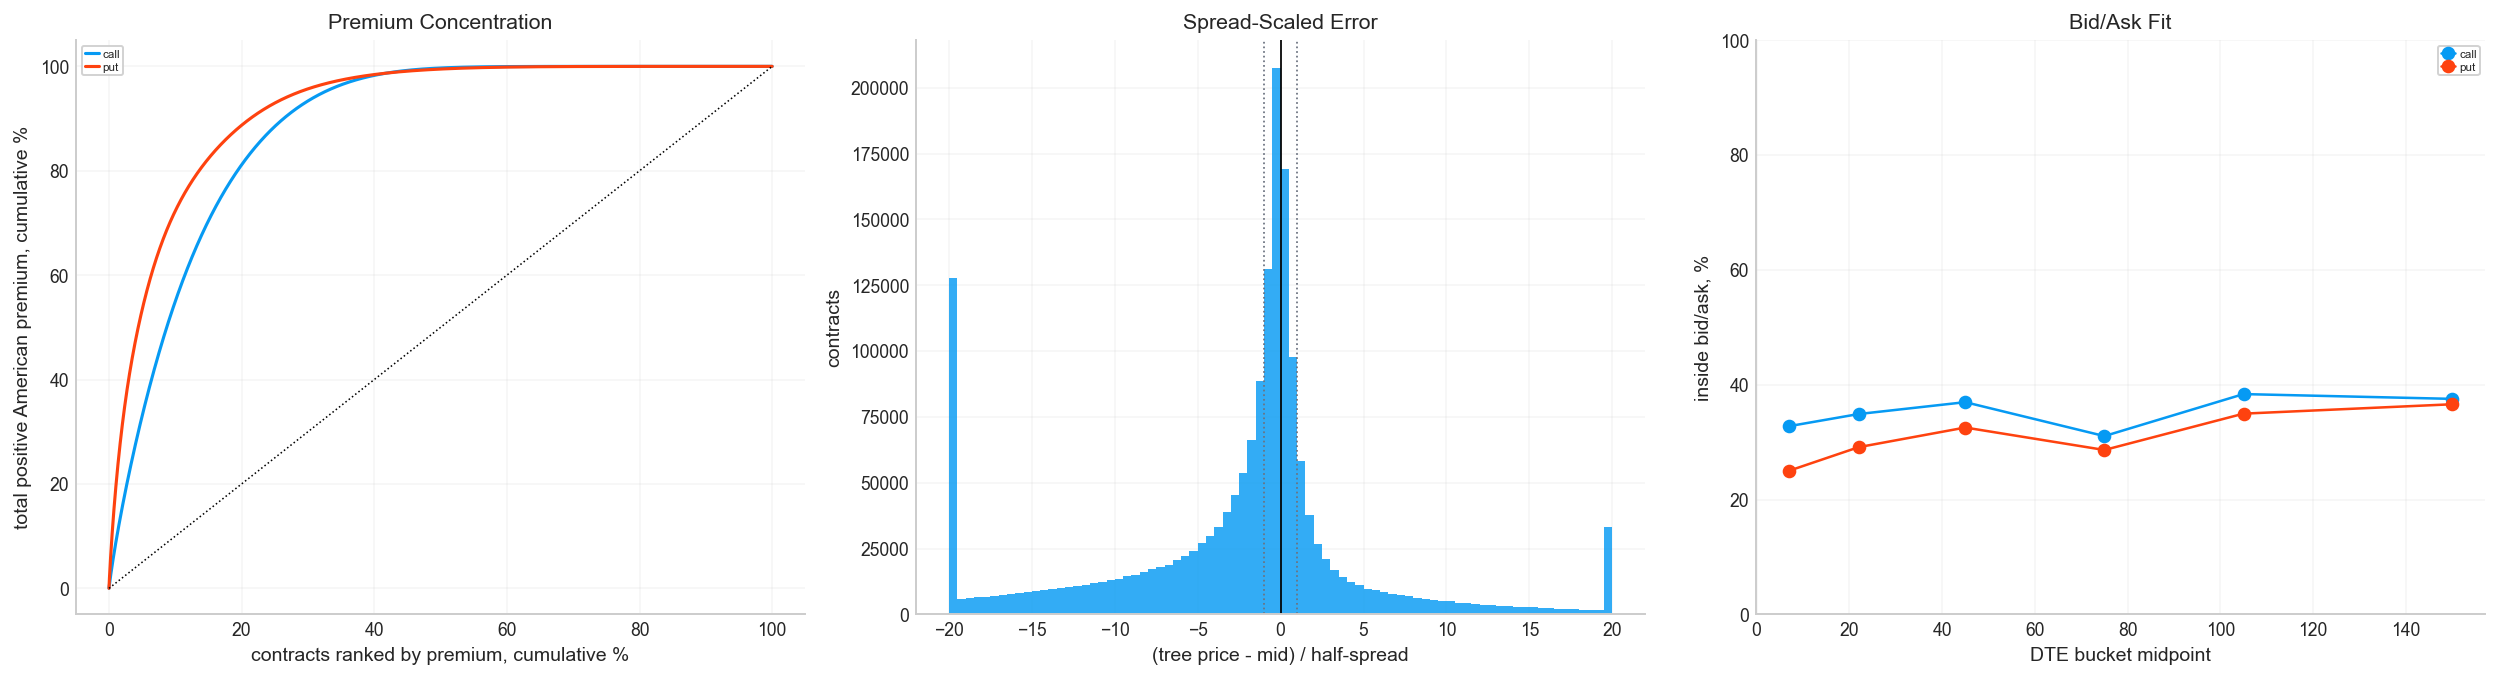

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for opt, group in tree_full_chain.groupby("option_type"):
    values = group["american_premium"].clip(lower=0.0).sort_values(ascending=False)
    values = values[values.gt(0.0)]
    if len(values):
        axes[0].plot(np.arange(1, len(values) + 1) / len(values) * 100.0, values.cumsum() / values.sum() * 100.0, lw=1.6, label=opt)
axes[0].plot([0, 100], [0, 100], color="black", lw=0.8, ls=":")
axes[0].set_xlabel("contracts ranked by premium, cumulative %")
axes[0].set_ylabel("total positive American premium, cumulative %")
axes[0].set_title("Premium Concentration")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
half_spread = 0.5 * (tree_full_chain["ask"] - tree_full_chain["bid"])
scaled_error = (tree_full_chain["pricing_error"] / half_spread.replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna().clip(-20, 20)
axes[1].hist(scaled_error, bins=80, color=palette[0], alpha=0.82)
for x0 in [-1.0, 0.0, 1.0]:
    axes[1].axvline(x0, color="black" if x0 == 0.0 else "#6b7280", lw=0.9, ls="-" if x0 == 0.0 else ":")
axes[1].set_xlabel("(tree price - mid) / half-spread")
axes[1].set_ylabel("contracts")
axes[1].set_title("Spread-Scaled Error")
hit = tree_full_chain.copy()
hit["inside_bid_ask"] = hit["american_tree_price"].between(hit["bid"], hit["ask"])
hit["dte_bucket"] = pd.cut(hit["dte_days"], [0, 14, 30, 60, 90, 120, 180, 365], include_lowest=True)
hit_rate = hit.groupby(["dte_bucket", "option_type"], observed=True)["inside_bid_ask"].mean().reset_index()
for opt, part in hit_rate.groupby("option_type"):
    x = [0.5 * (row["dte_bucket"].left + row["dte_bucket"].right) for _, row in part.iterrows()]
    axes[2].plot(x, part["inside_bid_ask"] * 100.0, marker="o", lw=1.3, label=opt)
axes[2].set_ylim(0, 100)
axes[2].set_xlabel("DTE bucket midpoint")
axes[2].set_ylabel("inside bid/ask, %")
axes[2].set_title("Bid/Ask Fit")
axes[2].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


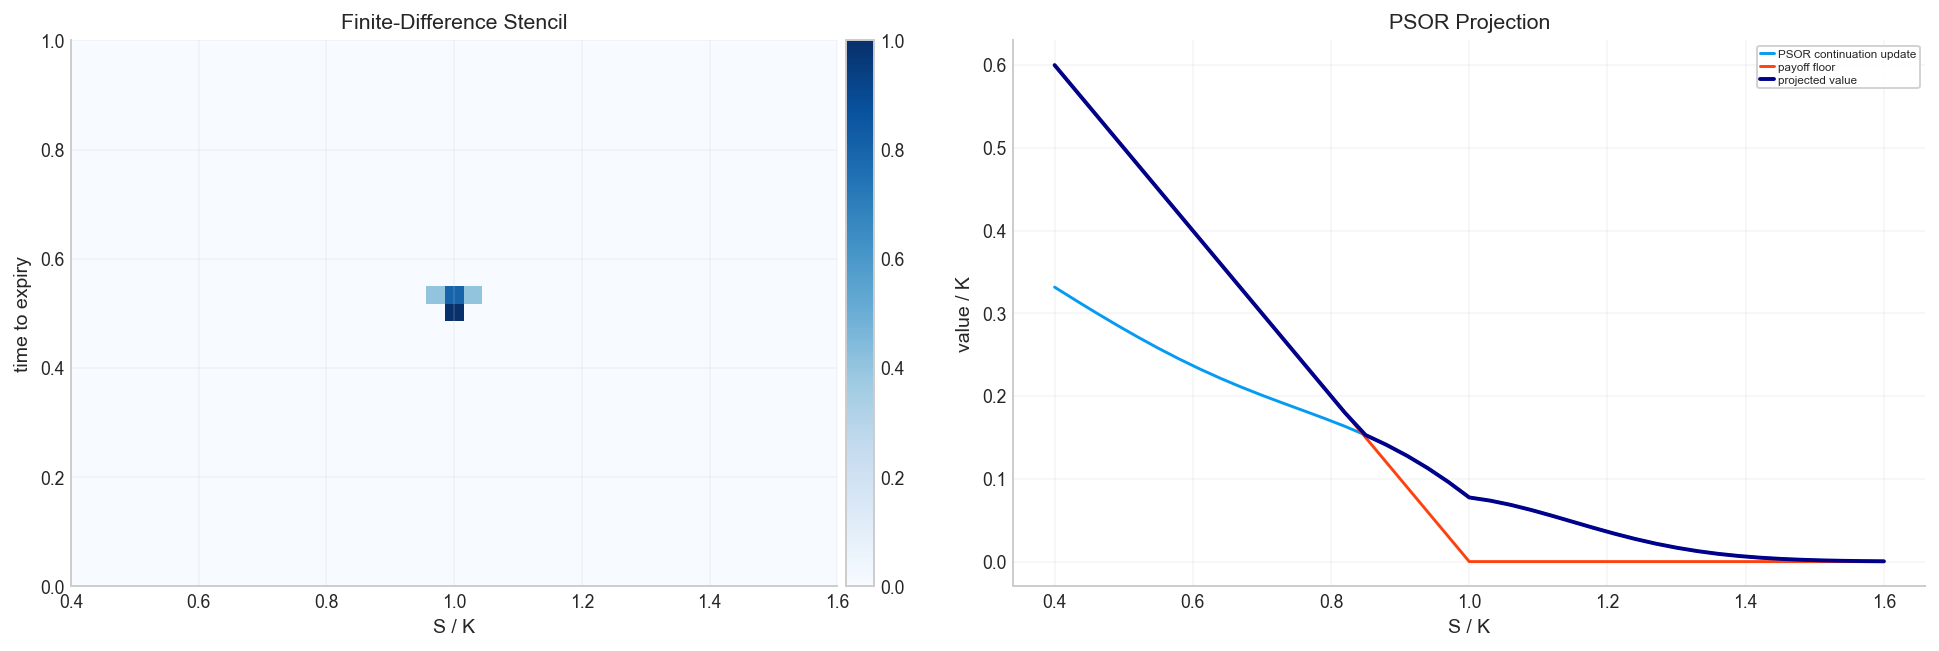

In [38]:
s_grid_demo = np.linspace(0.4, 1.6, 41)
t_grid_demo = np.linspace(1.0, 0.0, 31)
stencil = np.zeros((len(t_grid_demo), len(s_grid_demo)))
mid_t = len(t_grid_demo) // 2
mid_s = len(s_grid_demo) // 2
stencil[mid_t, mid_s] = 1.0
stencil[mid_t + 1, mid_s - 1:mid_s + 2] = [0.4, 0.8, 0.4]
projection_payoff = np.maximum(1.0 - s_grid_demo, 0.0)
continuation_guess = 0.55 * projection_payoff + 0.08 * np.exp(-((s_grid_demo - 0.95) / 0.28) ** 2)
projected_value = np.maximum(projection_payoff, continuation_guess)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
im = axes[0].imshow(stencil, aspect="auto", origin="lower", extent=[s_grid_demo[0], s_grid_demo[-1], t_grid_demo[-1], t_grid_demo[0]], cmap="Blues")
axes[0].set_xlabel("S / K")
axes[0].set_ylabel("time to expiry")
axes[0].set_title("Finite-Difference Stencil")
fig.colorbar(im, ax=axes[0], pad=0.01)
axes[1].plot(s_grid_demo, continuation_guess, label="PSOR continuation update")
axes[1].plot(s_grid_demo, projection_payoff, label="payoff floor")
axes[1].plot(s_grid_demo, projected_value, lw=2.0, label="projected value")
axes[1].set_xlabel("S / K")
axes[1].set_ylabel("value / K")
axes[1].set_title("PSOR Projection")
axes[1].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


In [39]:
@njit
def pde_payoff_grid(s_grid, k, flag):
    out = np.empty(s_grid.size)
    for i in range(s_grid.size):
        out[i] = payoff(s_grid[i], k, flag)
    return out

@njit
def explicit_projected(s, k, r, q, sigma, tau, flag, s_steps, t_steps, s_max_mult):
    m = max(40, s_steps)
    n = max(10, t_steps)
    s_max = max(s_max_mult * max(s, k), 1.5 * max(s, k))
    ds = s_max / m
    dt = tau / n
    grid = np.empty(m + 1)
    value = np.empty(m + 1)
    new_value = np.empty(m + 1)
    for i in range(m + 1):
        grid[i] = i * ds
        value[i] = payoff(grid[i], k, flag)
    for step in range(n - 1, -1, -1):
        new_value[0] = k * math.exp(-r * (n - step) * dt) if flag < 0 else 0.0
        new_value[m] = 0.0 if flag < 0 else s_max * math.exp(-q * (n - step) * dt) - k * math.exp(-r * (n - step) * dt)
        for i in range(1, m):
            ii = float(i)
            delta = (value[i + 1] - value[i - 1]) / (2.0 * ds)
            gamma = (value[i + 1] - 2.0 * value[i] + value[i - 1]) / (ds * ds)
            theta = -0.5 * sigma * sigma * grid[i] * grid[i] * gamma - (r - q) * grid[i] * delta + r * value[i]
            cont = value[i] - dt * theta
            new_value[i] = max(payoff(grid[i], k, flag), cont)
        for i in range(m + 1):
            value[i] = new_value[i]
    j = min(max(int(s / ds), 0), m - 1)
    w = (s - grid[j]) / ds
    return value[j] * (1.0 - w) + value[j + 1] * w, grid, value


In [40]:
@njit
def implicit_psor_pde(s, k, r, q, sigma, tau, flag, s_steps, t_steps, s_max_mult, omega, tol, max_iter):
    m = max(20, s_steps)
    n = max(4, t_steps)
    s_max = max(s_max_mult * max(s, k), 1.5 * max(s, k))
    ds = s_max / m
    dt = max(tau, 1e-10) / n
    grid = np.empty(m + 1)
    payoff_vec = np.empty(m + 1)
    oldv = np.empty(m + 1)
    newv = np.empty(m + 1)
    rhs = np.empty(m + 1)
    values = np.empty((n + 1, m + 1))
    boundary = np.empty(n + 1)
    residuals = np.empty(n)
    iterations = np.empty(n)
    for i in range(m + 1):
        grid[i] = i * ds
        payoff_vec[i] = payoff(grid[i], k, flag)
        oldv[i] = payoff_vec[i]
        newv[i] = payoff_vec[i]
        values[n, i] = oldv[i]
    for step in range(n + 1):
        boundary[step] = np.nan
    boundary[n] = k
    sig2 = sigma * sigma
    for step in range(n - 1, -1, -1):
        t = step * dt
        if flag > 0:
            rhs[0] = 0.0
            rhs[m] = s_max * math.exp(-q * (tau - t)) - k * math.exp(-r * (tau - t))
        else:
            rhs[0] = k * math.exp(-r * (tau - t))
            rhs[m] = 0.0
        rhs[0] = max(rhs[0], payoff_vec[0])
        rhs[m] = max(rhs[m], payoff_vec[m])
        newv[0] = rhs[0]
        newv[m] = rhs[m]
        for i in range(1, m):
            rhs[i] = oldv[i]
            newv[i] = oldv[i]
        max_update = 0.0
        it_count = 0
        for it in range(max_iter):
            max_update = 0.0
            it_count = it + 1
            for i in range(1, m):
                ii = float(i)
                a = -0.5 * dt * (sig2 * ii * ii - (r - q) * ii)
                c = -0.5 * dt * (sig2 * ii * ii + (r - q) * ii)
                diag = 1.0 + dt * (sig2 * ii * ii + r)
                y = (rhs[i] - a * newv[i - 1] - c * newv[i + 1]) / diag
                cand = newv[i] + omega * (y - newv[i])
                cand = max(cand, payoff_vec[i])
                max_update = max(max_update, abs(cand - newv[i]))
                newv[i] = cand
            if max_update < tol:
                break
        residuals[step] = max_update
        iterations[step] = it_count
        level = np.nan
        for i in range(1, m):
            if abs(newv[i] - payoff_vec[i]) < 5e-5 and payoff_vec[i] > 0.0:
                if flag > 0:
                    if math.isnan(level) or grid[i] < level:
                        level = grid[i]
                else:
                    if math.isnan(level) or grid[i] > level:
                        level = grid[i]
        boundary[step] = level
        for i in range(m + 1):
            oldv[i] = newv[i]
            values[step, i] = oldv[i]
    j = min(max(int(math.floor(s / ds)), 0), m - 1)
    w = (s - grid[j]) / ds
    price = oldv[j] * (1.0 - w) + oldv[j + 1] * w
    return price, grid, values, boundary, residuals, iterations, payoff_vec


In [41]:
@njit
def theta_psor_pde(s, k, r, q, sigma, tau, flag, s_steps, t_steps, s_max_mult, theta_base, rannacher, omega, tol, max_iter):
    m = max(20, s_steps)
    n = max(4, t_steps)
    s_max = max(s_max_mult * max(s, k), 1.5 * max(s, k))
    ds = s_max / m
    dt = max(tau, 1e-10) / n
    grid = np.empty(m + 1)
    payoff_vec = np.empty(m + 1)
    oldv = np.empty(m + 1)
    newv = np.empty(m + 1)
    rhs = np.empty(m + 1)
    values = np.empty((n + 1, m + 1))
    boundary = np.empty(n + 1)
    residuals = np.empty(n)
    iterations = np.empty(n)
    for i in range(m + 1):
        grid[i] = i * ds
        payoff_vec[i] = payoff(grid[i], k, flag)
        oldv[i] = payoff_vec[i]
        newv[i] = payoff_vec[i]
        values[n, i] = oldv[i]
    for step in range(n + 1):
        boundary[step] = np.nan
    boundary[n] = k
    sig2 = sigma * sigma
    for step in range(n - 1, -1, -1):
        theta = 1.0 if (n - 1 - step) < rannacher else theta_base
        t = step * dt
        if flag > 0:
            rhs[0] = 0.0
            rhs[m] = s_max * math.exp(-q * (tau - t)) - k * math.exp(-r * (tau - t))
        else:
            rhs[0] = k * math.exp(-r * (tau - t))
            rhs[m] = 0.0
        rhs[0] = max(rhs[0], payoff_vec[0])
        rhs[m] = max(rhs[m], payoff_vec[m])
        newv[0] = rhs[0]
        newv[m] = rhs[m]
        for i in range(1, m):
            ii = float(i)
            left = 0.5 * (sig2 * ii * ii - (r - q) * ii)
            mid = -(sig2 * ii * ii + r)
            right = 0.5 * (sig2 * ii * ii + (r - q) * ii)
            rhs[i] = oldv[i] + (1.0 - theta) * dt * (left * oldv[i - 1] + mid * oldv[i] + right * oldv[i + 1])
            newv[i] = oldv[i]
        max_update = 0.0
        it_count = 0
        for it in range(max_iter):
            max_update = 0.0
            it_count = it + 1
            for i in range(1, m):
                ii = float(i)
                a = -theta * 0.5 * dt * (sig2 * ii * ii - (r - q) * ii)
                c = -theta * 0.5 * dt * (sig2 * ii * ii + (r - q) * ii)
                diag = 1.0 + theta * dt * (sig2 * ii * ii + r)
                y = (rhs[i] - a * newv[i - 1] - c * newv[i + 1]) / diag
                cand = newv[i] + omega * (y - newv[i])
                cand = max(cand, payoff_vec[i])
                max_update = max(max_update, abs(cand - newv[i]))
                newv[i] = cand
            if max_update < tol:
                break
        residuals[step] = max_update
        iterations[step] = it_count
        level = np.nan
        for i in range(1, m):
            if abs(newv[i] - payoff_vec[i]) < 5e-5 and payoff_vec[i] > 0.0:
                if flag > 0:
                    if math.isnan(level) or grid[i] < level:
                        level = grid[i]
                else:
                    if math.isnan(level) or grid[i] > level:
                        level = grid[i]
        boundary[step] = level
        for i in range(m + 1):
            oldv[i] = newv[i]
            values[step, i] = oldv[i]
    j = min(max(int(math.floor(s / ds)), 0), m - 1)
    w = (s - grid[j]) / ds
    price = oldv[j] * (1.0 - w) + oldv[j + 1] * w
    return price, grid, values, boundary, residuals, iterations, payoff_vec


,method,price,tree_reference,abs_error,runtime_sec,max_residual
0,explicit_projected,66.868865,66.846885,0.021980,1.194719,NaN
1,implicit_psor,66.884817,66.846885,0.037932,1.540653,1.000000e-07
2,crank_nicolson_psor,66.881197,66.846885,0.034312,0.008244,1.000000e-07
3,rannacher_cn_psor,66.881158,66.846885,0.034273,0.008174,1.000000e-07


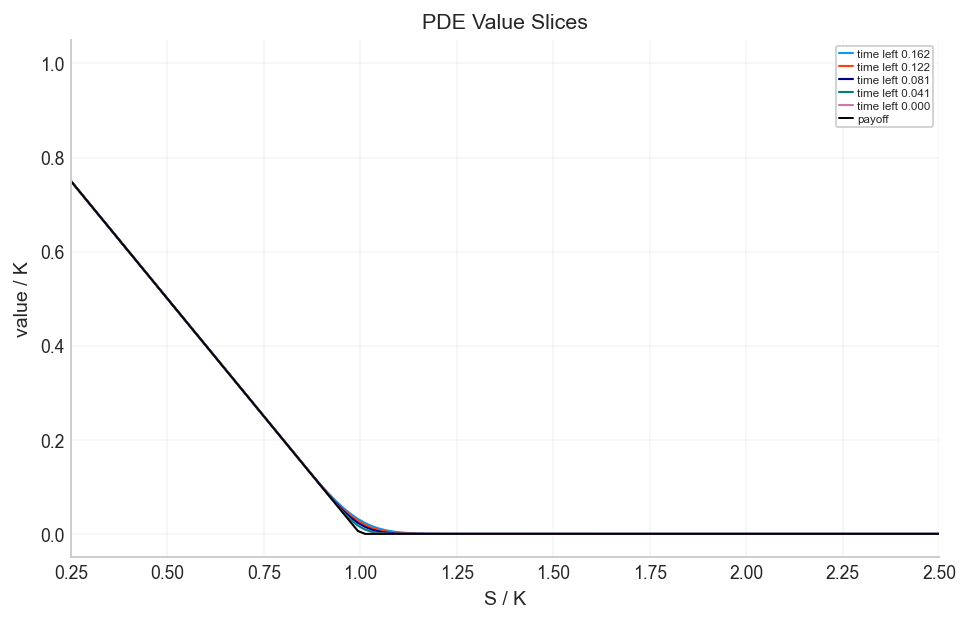

In [42]:
pde_row = put_row
t0 = time.perf_counter()
explicit_price, explicit_grid, explicit_values = explicit_projected(s0, k0, r0, q0, sigma0, tau0, flag0, 120, 1800, 3.0)
explicit_time = time.perf_counter() - t0
t0 = time.perf_counter()
pde_implicit = theta_psor_pde(s0, k0, r0, q0, sigma0, tau0, flag0, 160, 120, 3.0, 1.0, 0, 1.35, 1e-7, 5000)
implicit_time = time.perf_counter() - t0
t0 = time.perf_counter()
pde_cn = theta_psor_pde(s0, k0, r0, q0, sigma0, tau0, flag0, 160, 120, 3.0, 0.5, 0, 1.35, 1e-7, 5000)
cn_time = time.perf_counter() - t0
t0 = time.perf_counter()
pde_rannacher = theta_psor_pde(s0, k0, r0, q0, sigma0, tau0, flag0, 160, 120, 3.0, 0.5, 4, 1.35, 1e-7, 5000)
rannacher_time = time.perf_counter() - t0
pde_price_numba, pde_s_grid, pde_values, pde_boundary_values, pde_residuals, pde_iterations, pde_payoff = pde_rannacher
pde_summary = pd.DataFrame([
    {"method": "explicit_projected", "price": explicit_price, "tree_reference": ref, "abs_error": abs(explicit_price - ref), "runtime_sec": explicit_time, "max_residual": np.nan},
    {"method": "implicit_psor", "price": pde_implicit[0], "tree_reference": ref, "abs_error": abs(pde_implicit[0] - ref), "runtime_sec": implicit_time, "max_residual": np.nanmax(pde_implicit[4])},
    {"method": "crank_nicolson_psor", "price": pde_cn[0], "tree_reference": ref, "abs_error": abs(pde_cn[0] - ref), "runtime_sec": cn_time, "max_residual": np.nanmax(pde_cn[4])},
    {"method": "rannacher_cn_psor", "price": pde_price_numba, "tree_reference": ref, "abs_error": abs(pde_price_numba - ref), "runtime_sec": rannacher_time, "max_residual": np.nanmax(pde_residuals)},
])
display(pde_summary.round(8))

exercise_region = ((pde_values - pde_payoff[None, :]) <= 5e-5) & (pde_payoff[None, :] > 0.0)
time_to_expiry_pde = np.linspace(tau0, 0.0, pde_values.shape[0])
complementarity_gap_values = np.maximum(pde_payoff[None, :] - pde_values, 0.0)
pde_result = {"price": pde_price_numba, "s_grid": pde_s_grid, "values": pde_values, "boundary": pde_boundary_values, "residuals": pde_residuals, "iterations": pde_iterations, "payoff": pde_payoff, "strike": k0, "tau": tau0, "option_type": pde_row["option_type"]}

fig, ax = plt.subplots(figsize=(8, 4.8))
for idx in np.linspace(0, pde_values.shape[0] - 1, 5).astype(int):
    ax.plot(pde_s_grid / k0, pde_values[idx] / k0, lw=1.1, label=f"time left {time_to_expiry_pde[idx]:.3f}")
ax.plot(pde_s_grid / k0, pde_payoff / k0, color="black", lw=1.0, label="payoff")
ax.set_xlim(0.25, min(2.5, pde_s_grid[-1] / k0))
ax.set_xlabel("S / K")
ax.set_ylabel("value / K")
ax.set_title("PDE Value Slices")
ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
plt.show()


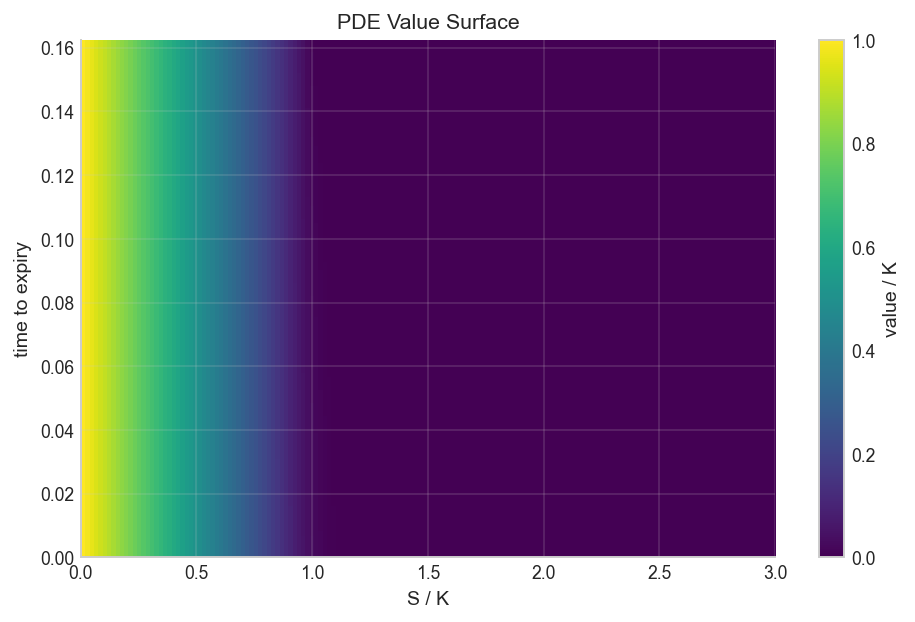

In [43]:
fig, ax = plt.subplots(figsize=(8, 4.8))
extent = [pde_s_grid[0] / k0, pde_s_grid[-1] / k0, time_to_expiry_pde[-1], time_to_expiry_pde[0]]
im = ax.imshow(pde_values / k0, aspect="auto", origin="lower", extent=extent, cmap="viridis")
ax.set_xlabel("S / K")
ax.set_ylabel("time to expiry")
ax.set_title("PDE Value Surface")
fig.colorbar(im, ax=ax, label="value / K")
plt.show()


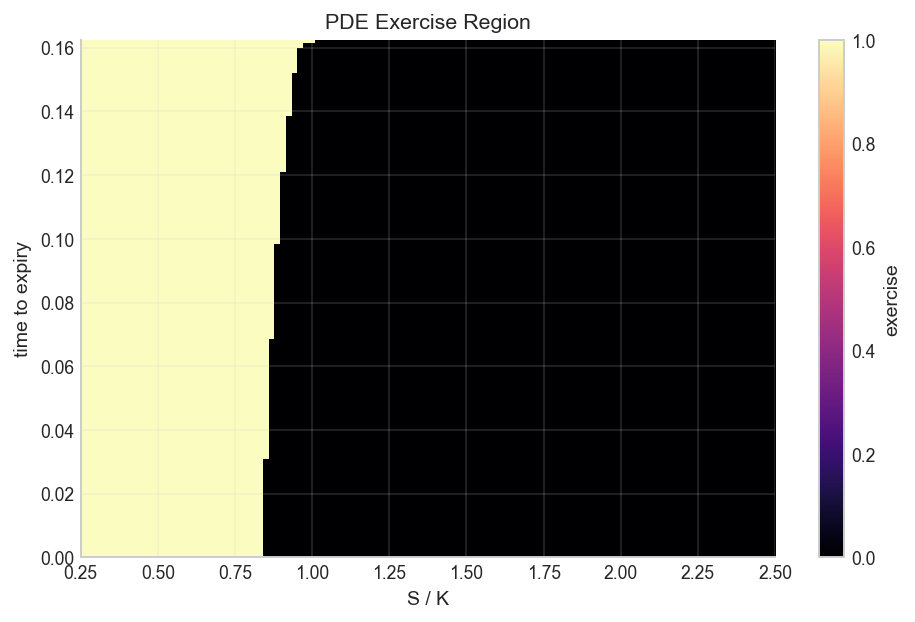

In [44]:
fig, ax = plt.subplots(figsize=(8, 4.8))
extent = [pde_s_grid[0] / k0, pde_s_grid[-1] / k0, time_to_expiry_pde[-1], time_to_expiry_pde[0]]
im = ax.imshow(exercise_region.astype(float), aspect="auto", origin="lower", extent=extent, cmap="magma", vmin=0, vmax=1)
ax.set_xlim(0.25, min(2.5, pde_s_grid[-1] / k0))
ax.set_xlabel("S / K")
ax.set_ylabel("time to expiry")
ax.set_title("PDE Exercise Region")
fig.colorbar(im, ax=ax, label="exercise")
plt.show()


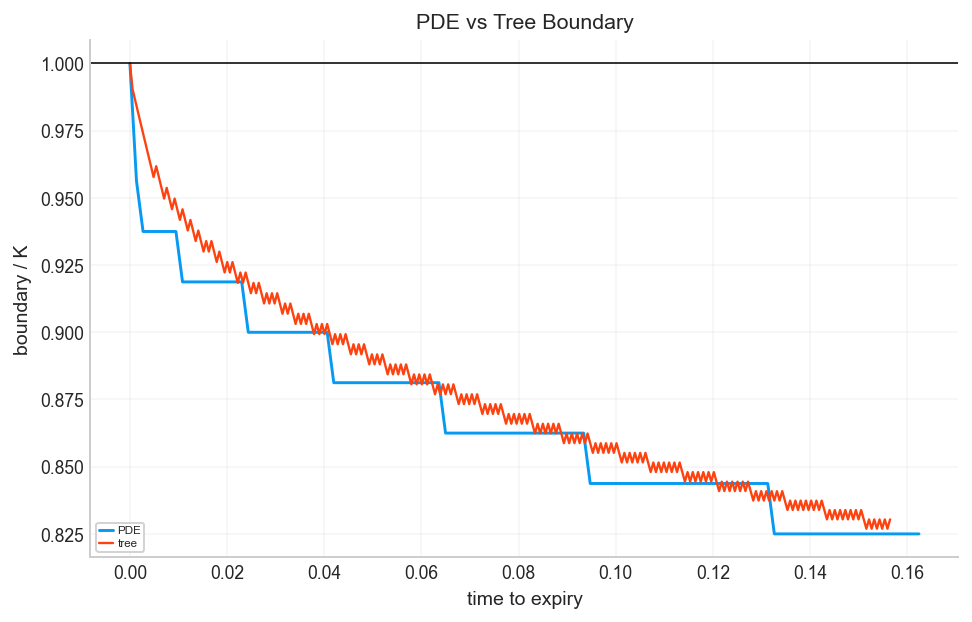

In [45]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(np.linspace(tau0, 0.0, len(pde_boundary_values)), pde_boundary_values / k0, lw=1.5, label="PDE")
ax.plot(tree_boundary_df["time_to_expiry"], tree_boundary_df["boundary_over_k"], lw=1.2, label="tree")
ax.axhline(1.0, color="black", lw=0.8)
ax.set_xlabel("time to expiry")
ax.set_ylabel("boundary / K")
ax.set_title("PDE vs Tree Boundary")
ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
plt.show()


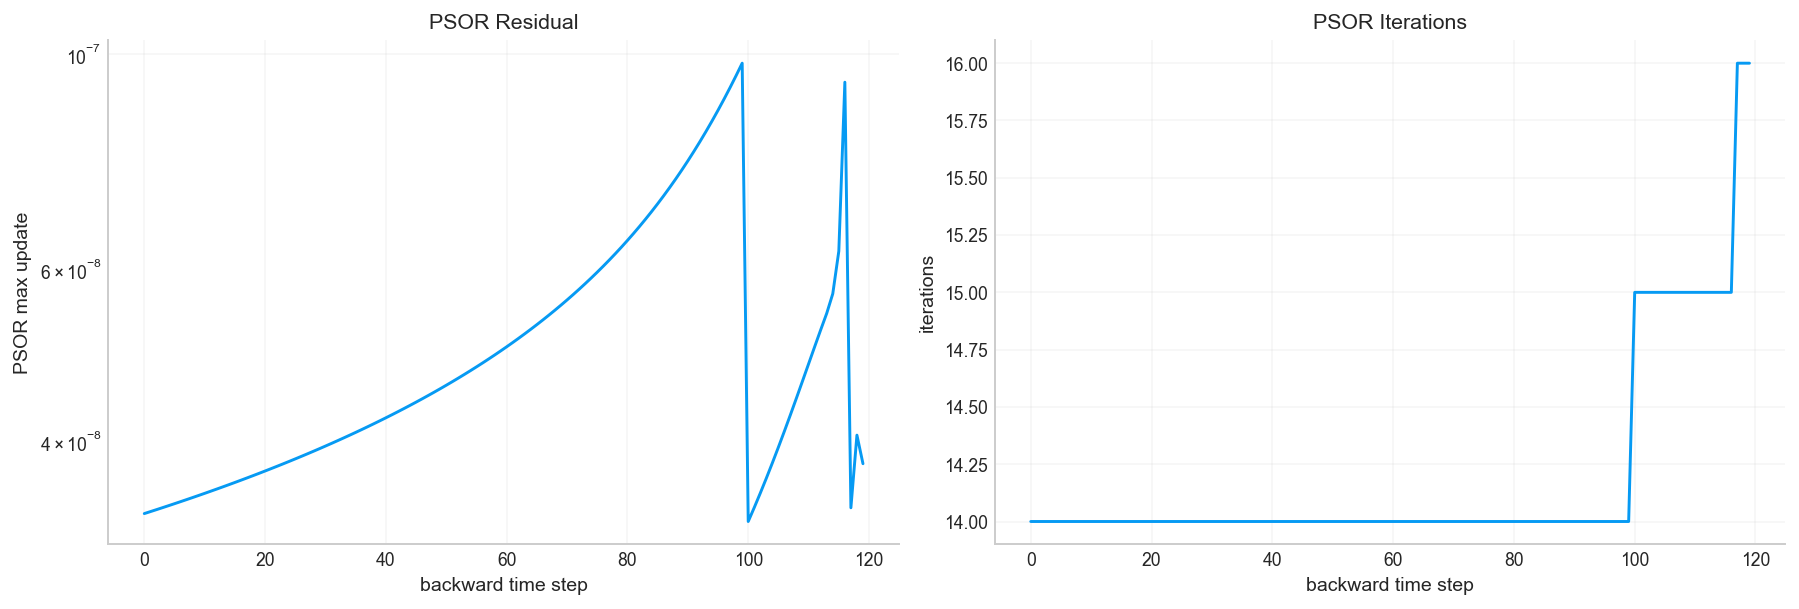

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(np.maximum(pde_residuals, 1e-16))
axes[0].set_xlabel("backward time step")
axes[0].set_ylabel("PSOR max update")
axes[0].set_title("PSOR Residual")
axes[1].plot(pde_iterations)
axes[1].set_xlabel("backward time step")
axes[1].set_ylabel("iterations")
axes[1].set_title("PSOR Iterations")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


In [48]:
from quantfinlab import _kernels

def regime_grid(q):
    data = q.copy().reset_index(drop=True)
    data["dte_bucket"] = pd.cut(data["dte_days"], [7, 14, 30, 60, 90, 120, 180], include_lowest=True)
    data["moneyness_bucket"] = pd.cut(data["moneyness"], [0.65, 0.80, 0.90, 0.97, 1.03, 1.10, 1.25, 1.45], include_lowest=True)
    data["sigma_bucket"] = pd.cut(data["sigma_used"], [0.03, 0.15, 0.22, 0.32, 0.50, 2.50], include_lowest=True)
    data["dividend_bucket"] = np.where(data["dividend_in_life"].gt(0), "dividend", "none")
    data["ex_div_bucket"] = pd.cut(data["days_to_next_dividend"].fillna(10_000), [-1, 7, 21, 10_000], labels=["0_7", "8_21", "none"], include_lowest=True)
    keys = ["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket"]
    coverage = data.groupby(keys, observed=True).agg(cell_rows=("mid", "size"), median_dte=("dte_days", "median"), median_moneyness=("moneyness", "median"), median_sigma=("sigma_used", "median"), median_spread=("relative_spread", "median")).reset_index()
    data = data.merge(coverage, on=keys, how="left")
    data["_distance"] = (data["dte_days"] - data["median_dte"]).abs() / ann_days + (data["moneyness"] - data["median_moneyness"]).abs() + (data["sigma_used"] - data["median_sigma"]).abs()
    out = data.sort_values(keys + ["_distance", "relative_spread", "date"]).drop_duplicates(subset=keys, keep="first").drop(columns=["_distance"]).reset_index(drop=True)
    out["coverage_rows"] = out["cell_rows"]
    out["coverage_pct"] = out["coverage_rows"] / len(data)
    return out

pde_regime = regime_grid(spy_quotes)
display(pd.DataFrame([{"full_chain_rows": len(spy_quotes), "pde_regime_cells": len(pde_regime), "covered_rows": int(pde_regime["coverage_rows"].sum()), "coverage_pct": float(pde_regime["coverage_rows"].sum() / len(spy_quotes))}]))
display(pde_regime.groupby(["option_type", "dividend_bucket"], observed=True)["coverage_rows"].agg(["count", "sum", "median"]).reset_index())

validation_rows = pde_regime.sort_values(["option_type", "dte_days", "moneyness"]).iloc[:max(50, min(80, len(pde_regime)))].copy()
validation_records = []
for _, row in validation_rows.iterrows():
    flag = int(option_flag([row["option_type"]])[0])
    t0 = time.perf_counter()
    nb = implicit_psor_pde(float(row["spot"]), float(row["strike"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), flag, 100, 80, 3.0, 1.35, 1e-7, 5000)
    nb_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    cpp = _kernels.american_pde_psor(float(row["spot"]), float(row["strike"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), flag, 100, 80, 3.0, 1.35, 1e-7, 5000, True)
    cpp_time = time.perf_counter() - t0
    nb_boundary = nb[3]
    cpp_boundary = np.asarray(cpp["boundary"], dtype=float)
    boundary_diff = np.nanmedian(np.abs(nb_boundary - cpp_boundary))
    validation_records.append({"date": row["date"], "option_type": row["option_type"], "dte_days": row["dte_days"], "moneyness": row["moneyness"], "numba_price": nb[0], "cpp_price": cpp["price"], "abs_price_diff": abs(nb[0] - cpp["price"]), "boundary_diff": boundary_diff, "numba_max_residual": np.nanmax(nb[4]), "cpp_max_residual": np.nanmax(cpp["residuals"]), "numba_sec": nb_time, "cpp_sec": cpp_time})
pde_validation = pd.DataFrame(validation_records)
display(pde_validation[["abs_price_diff", "boundary_diff", "numba_max_residual", "cpp_max_residual", "numba_sec", "cpp_sec"]].agg(["count", "mean", "max", "median"]).round(8))


,full_chain_rows,pde_regime_cells,covered_rows,coverage_pct
0,1839734,1095,1839734,1.0


,option_type,dividend_bucket,count,sum,median
0,call,dividend,370,509493,554.0
1,call,none,164,383627,217.5
2,put,dividend,398,537746,597.5
3,put,none,163,408868,285.0


,abs_price_diff,boundary_diff,numba_max_residual,cpp_max_residual,numba_sec,cpp_sec
count,80.0,80.0,8.000000e+01,8.000000e+01,80.000000,80.000000
mean,0.0,0.0,9.000000e-08,9.000000e-08,0.011797,0.001566
max,0.0,0.0,1.000000e-07,1.000000e-07,0.819875,0.001934
median,0.0,0.0,1.000000e-07,1.000000e-07,0.001551,0.001551


In [49]:
pde_variant_cache = cache_dir / "spy_pde_regime_method_comparison.parquet"
pde_variant_meta = cache_dir / "spy_pde_regime_method_comparison.meta.json"
pde_variant_settings = {"dataset": "SPY OptionsDX 2022-2023", "cells": int(len(pde_regime)), "s_steps": 80, "t_steps": 60, "methods": ["implicit_psor", "crank_nicolson_psor", "rannacher_cn_psor"], "engine": "numba"}
use_variant_cache = pde_variant_cache.exists() and pde_variant_meta.exists() and json.loads(pde_variant_meta.read_text()).get("settings") == pde_variant_settings
if use_variant_cache:
    pde_method_regime = pd.read_parquet(pde_variant_cache)
else:
    pde_method_rows = []
    pde_refs = pde_regime.merge(tree_full_chain[["date", "expiry", "option_type", "strike", "american_tree_price", "european_tree_price"]], on=["date", "expiry", "option_type", "strike"], how="left")
    for _, row in pde_refs.iterrows():
        flag = int(option_flag([row["option_type"]])[0])
        method_specs = [("implicit_psor", 1.0, 0), ("crank_nicolson_psor", 0.5, 0), ("rannacher_cn_psor", 0.5, 4)]
        for method, theta_value, rannacher_steps in method_specs:
            t0 = time.perf_counter()
            out = theta_psor_pde(float(row["spot"]), float(row["strike"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), flag, 80, 60, 3.0, theta_value, rannacher_steps, 1.35, 1e-7, 5000)
            elapsed = time.perf_counter() - t0
            boundary_now = float(out[3][0]) if len(out[3]) else np.nan
            pde_method_rows.append({"method": method, "date": row["date"], "expiry": row["expiry"], "option_type": row["option_type"], "strike": row["strike"], "spot": row["spot"], "moneyness": row["moneyness"], "dte_days": row["dte_days"], "sigma_used": row["sigma_used"], "coverage_rows": int(row["coverage_rows"]), "pde_price": float(out[0]), "tree_price": float(row["american_tree_price"]), "european_tree_price": float(row["european_tree_price"]), "abs_tree_diff": abs(float(out[0]) - float(row["american_tree_price"])), "boundary_now": boundary_now, "max_residual": float(np.nanmax(out[4])), "median_iterations": float(np.nanmedian(out[5])), "runtime_sec": elapsed, "dte_bucket": str(row["dte_bucket"]), "moneyness_bucket": str(row["moneyness_bucket"]), "sigma_bucket": str(row["sigma_bucket"]), "dividend_bucket": row["dividend_bucket"], "ex_div_bucket": str(row["ex_div_bucket"])})
    pde_method_regime = pd.DataFrame(pde_method_rows)
    pde_method_regime.to_parquet(pde_variant_cache, index=False)
    pde_variant_meta.write_text(json.dumps({"settings": pde_variant_settings, "rows": len(pde_method_regime), "created_utc": pd.Timestamp.now("UTC").isoformat()}, indent=2))

pde_method_summary_rows = []
for method, g in pde_method_regime.groupby("method"):
    pde_method_summary_rows.append({"method": method, "cells": len(g), "rows_represented": g["coverage_rows"].sum(), "weighted_abs_tree_diff": np.average(g["abs_tree_diff"], weights=g["coverage_rows"]), "median_abs_tree_diff": g["abs_tree_diff"].median(), "p95_abs_tree_diff": g["abs_tree_diff"].quantile(0.95), "median_residual": g["max_residual"].median(), "median_iterations": g["median_iterations"].median(), "total_runtime_sec": g["runtime_sec"].sum()})
pde_method_summary = pd.DataFrame(pde_method_summary_rows)
pde_method_summary["score"] = pde_method_summary["weighted_abs_tree_diff"] + 0.05 * pde_method_summary["p95_abs_tree_diff"] + 0.001 * pde_method_summary["total_runtime_sec"]
selected_pde_method = str(pde_method_summary.sort_values("score").iloc[0]["method"])
display(pde_method_summary.round(8))
display(pd.DataFrame([{"selected_pde_method": selected_pde_method, "regime_cells": len(pde_regime), "rows_represented": int(pde_method_regime.loc[pde_method_regime["method"].eq(selected_pde_method), "coverage_rows"].sum())}]))


,method,cells,rows_represented,weighted_abs_tree_diff,median_abs_tree_diff,p95_abs_tree_diff,median_residual,median_iterations,total_runtime_sec,score
0,crank_nicolson_psor,1095,1839734,0.242315,0.120990,0.544745,1.000000e-07,15.0,1.168534,0.270721
1,implicit_psor,1095,1839734,0.239925,0.120438,0.544158,1.000000e-07,14.0,1.118736,0.268251
2,rannacher_cn_psor,1095,1839734,0.241791,0.119935,0.544692,1.000000e-07,15.0,1.130402,0.270156


,selected_pde_method,regime_cells,rows_represented
0,implicit_psor,1095,1839734


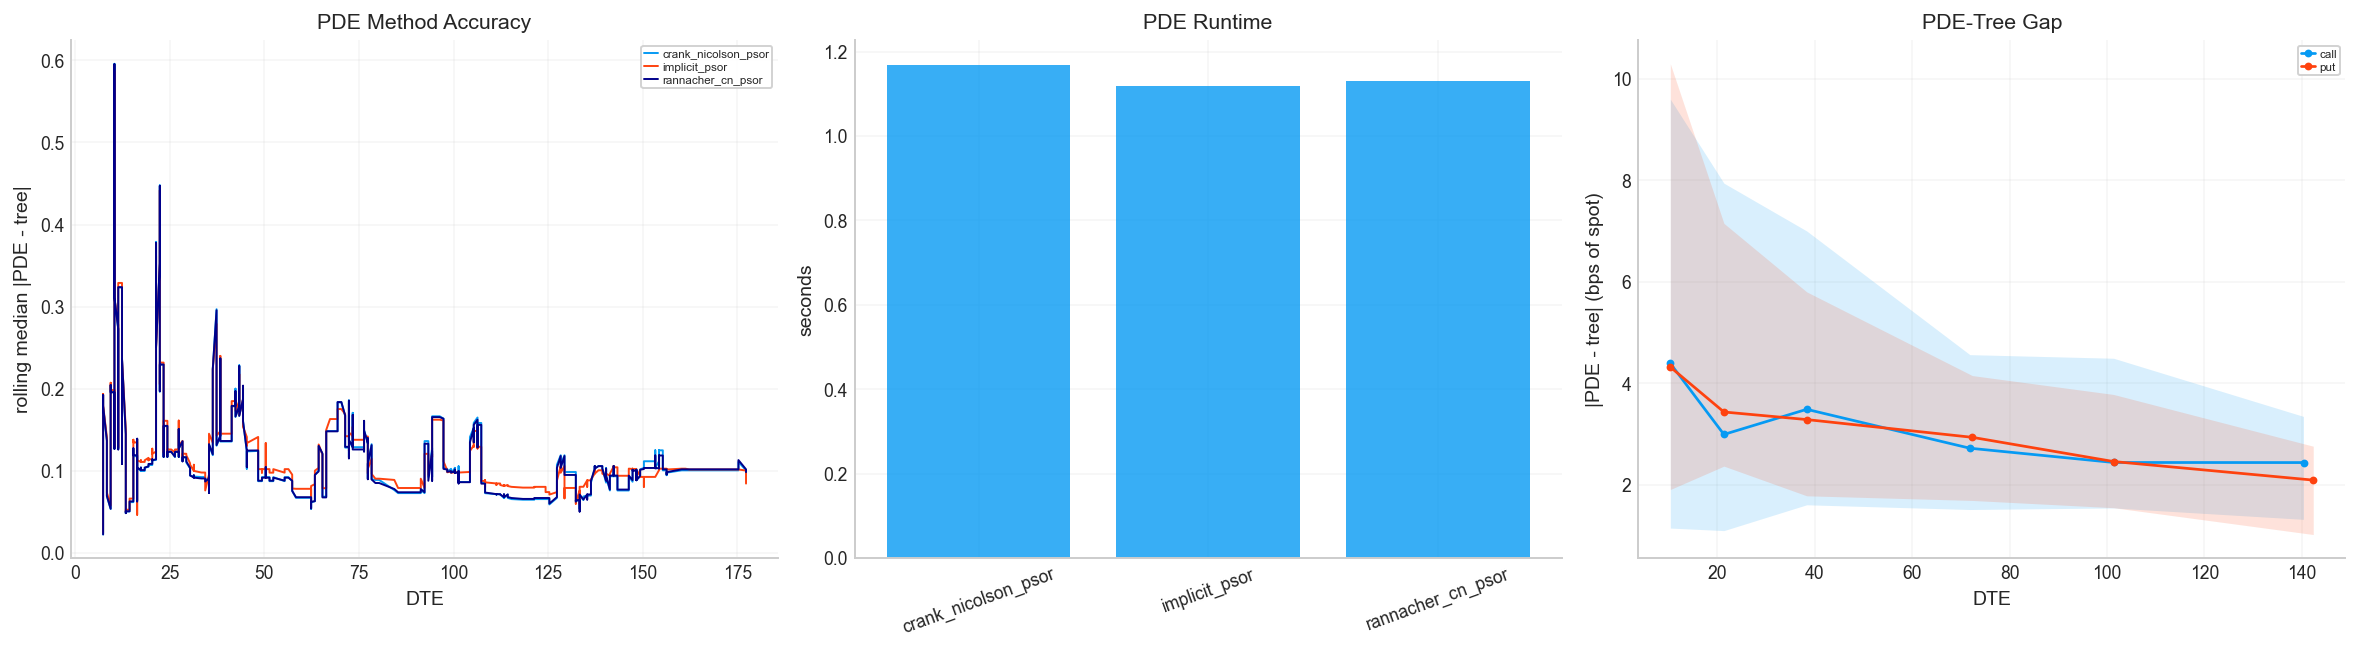

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for method, group in pde_method_regime.groupby("method"):
    ordered = group.sort_values("dte_days")
    axes[0].plot(ordered["dte_days"], ordered["abs_tree_diff"].rolling(25, min_periods=5).median(), lw=1.0, label=method)
axes[0].set_xlabel("DTE")
axes[0].set_ylabel("rolling median |PDE - tree|")
axes[0].set_title("PDE Method Accuracy")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
summary_plot = pde_method_summary.set_index("method")
axes[1].bar(summary_plot.index.astype(str), summary_plot["total_runtime_sec"], color=palette[0], alpha=0.8)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("seconds")
axes[1].set_title("PDE Runtime")
chosen = pde_method_regime[pde_method_regime["method"].eq(selected_pde_method)].copy()
chosen["gap_bps"] = 10000.0 * chosen["abs_tree_diff"].abs() / chosen["spot"].replace(0.0, np.nan)
for i, (opt, group) in enumerate(chosen.groupby("option_type", observed=True)):
    by = group.groupby("dte_bucket", observed=True).agg(
        x=("dte_days", "median"),
        med=("gap_bps", "median"),
        lo=("gap_bps", lambda v: np.nanquantile(v, 0.25)),
        hi=("gap_bps", lambda v: np.nanquantile(v, 0.75)),
    ).dropna().sort_values("x")
    axes[2].plot(by["x"], by["med"], marker="o", ms=3, lw=1.4, color=palette[i % len(palette)], label=str(opt))
    axes[2].fill_between(by["x"].to_numpy(float), by["lo"].to_numpy(float), by["hi"].to_numpy(float), color=palette[i % len(palette)], alpha=0.15, lw=0)
axes[2].set_xlabel("DTE")
axes[2].set_ylabel("|PDE - tree| (bps of spot)")
axes[2].set_title("PDE-Tree Gap")
axes[2].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


,coverage_rows,pde_price,american_tree_price_tree,pde_tree_disagreement,pde_max_residual
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.0
mean,1680.122374,34.244931,34.252744,-0.007812,0.0
std,3034.149618,42.554879,42.541189,0.089905,0.0
min,1.000000,0.006188,0.002803,-0.861869,0.0
5%,4.000000,0.062725,0.039597,-0.148140,0.0
50%,484.000000,14.487873,14.557214,0.015099,0.0
95%,8005.000000,125.633897,125.625251,0.070503,0.0
max,23934.000000,203.513950,203.506264,0.172708,0.0


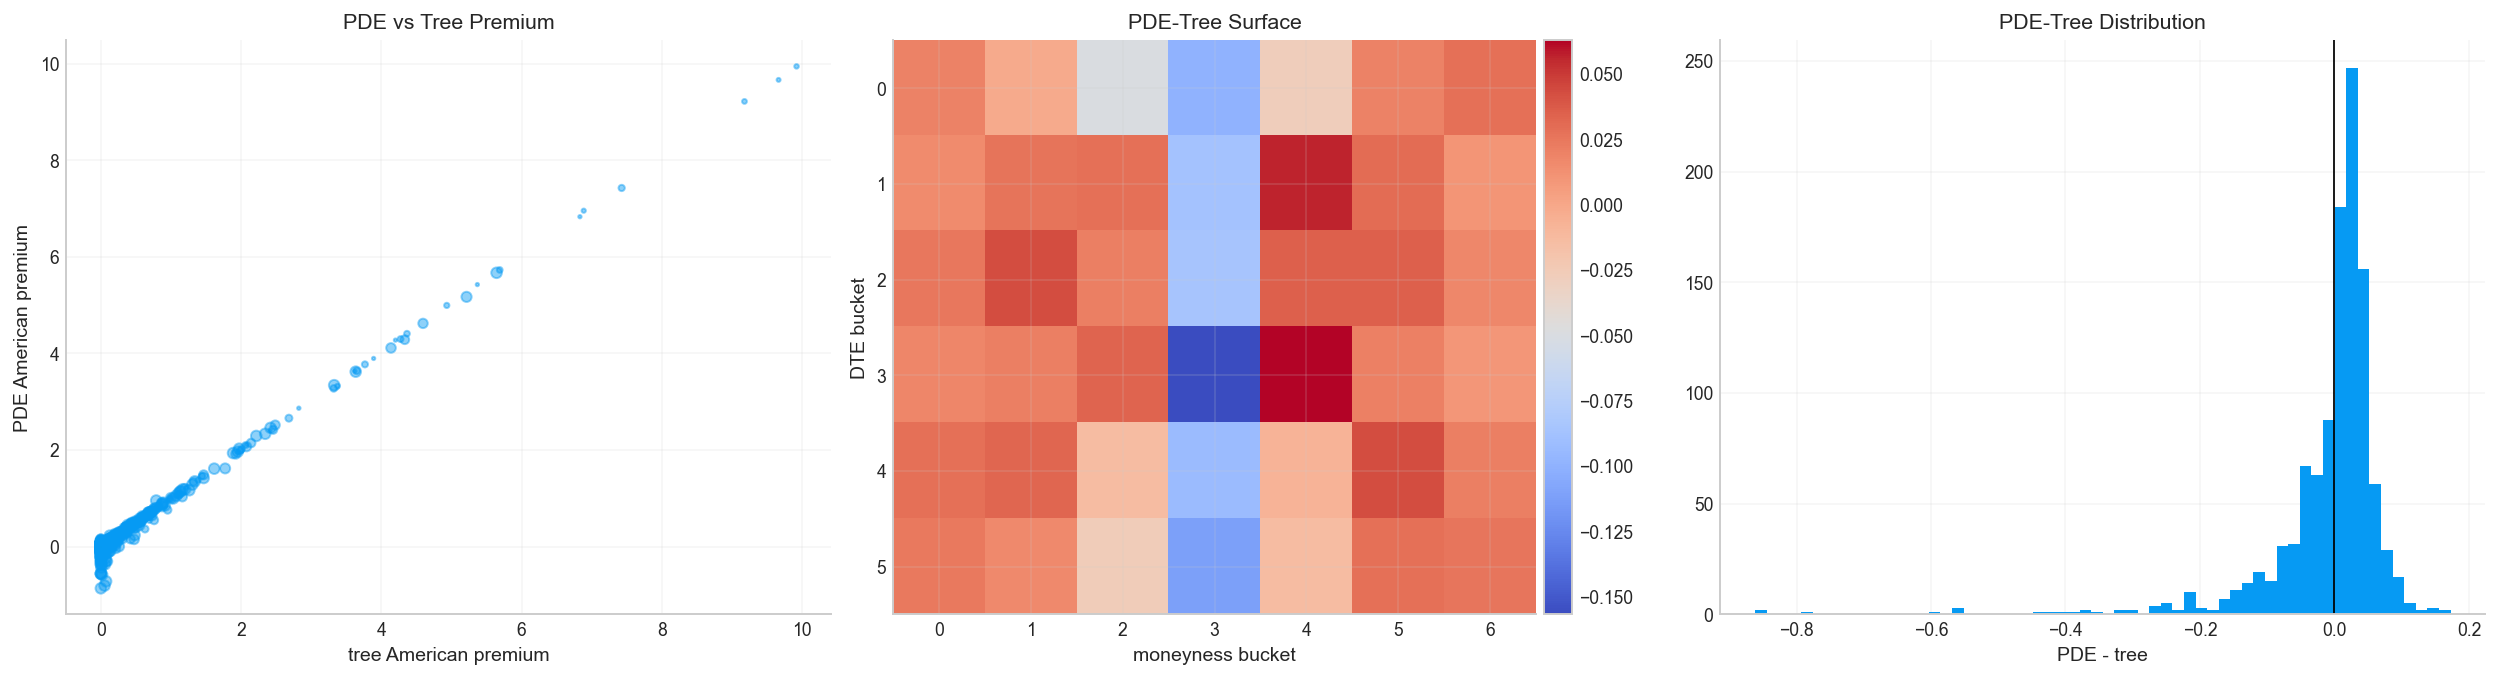

In [51]:
pde_cache = cache_dir / "spy_pde_full_or_regime.parquet"
pde_meta = cache_dir / "spy_pde_full_or_regime.meta.json"
pde_settings = {"dataset": "SPY OptionsDX 2022-2023", "method": "systematic_pde_regime_grid", "cells": int(len(pde_regime)), "s_steps": 120, "t_steps": 90, "scheme": selected_pde_method, "engine": "cpp" if selected_pde_method == "implicit_psor" else "numba"}
use_pde_cache = pde_cache.exists() and pde_meta.exists() and json.loads(pde_meta.read_text()).get("settings") == pde_settings
if use_pde_cache:
    pde_full_or_regime = pd.read_parquet(pde_cache)
else:
    pde_records = []
    for _, row in pde_regime.iterrows():
        flag = int(option_flag([row["option_type"]])[0])
        if selected_pde_method == "implicit_psor":
            out = _kernels.american_pde_psor(float(row["spot"]), float(row["strike"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), flag, 120, 90, 3.0, 1.35, 1e-7, 5000, True)
            price = float(out["price"])
            boundary = np.asarray(out["boundary"], dtype=float)
            residuals = np.asarray(out["residuals"], dtype=float)
            iterations = np.asarray(out["iterations"], dtype=float) if "iterations" in out else np.full_like(residuals, np.nan)
        else:
            theta_value = 0.5
            rannacher_steps = 4 if selected_pde_method == "rannacher_cn_psor" else 0
            out = theta_psor_pde(float(row["spot"]), float(row["strike"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), flag, 120, 90, 3.0, theta_value, rannacher_steps, 1.35, 1e-7, 5000)
            price = float(out[0])
            boundary = np.asarray(out[3], dtype=float)
            residuals = np.asarray(out[4], dtype=float)
            iterations = np.asarray(out[5], dtype=float)
        pde_records.append({"date": row["date"], "expiry": row["expiry"], "option_type": row["option_type"], "spot": row["spot"], "strike": row["strike"], "tau": row["tau"], "dte_days": row["dte_days"], "moneyness": row["moneyness"], "sigma_used": row["sigma_used"], "rate": row["rate"], "dividend_yield": row["dividend_yield"], "mid": row["mid"], "american_tree_price": row.get("american_tree_price", np.nan), "pde_price": price, "pde_boundary_now": float(boundary[0]) if len(boundary) else np.nan, "pde_max_residual": float(np.nanmax(residuals)), "pde_median_iterations": float(np.nanmedian(iterations)), "coverage_rows": int(row["coverage_rows"]), "dte_bucket": str(row["dte_bucket"]), "moneyness_bucket": str(row["moneyness_bucket"]), "sigma_bucket": str(row["sigma_bucket"]), "dividend_bucket": row["dividend_bucket"], "ex_div_bucket": str(row["ex_div_bucket"]), "pde_scheme": selected_pde_method})
    pde_full_or_regime = pd.DataFrame(pde_records)
    pde_full_or_regime.to_parquet(pde_cache, index=False)
    pde_meta.write_text(json.dumps({"settings": pde_settings, "rows": len(pde_full_or_regime), "created_utc": pd.Timestamp.now("UTC").isoformat()}, indent=2))

pde_tree = pde_full_or_regime.merge(tree_full_chain[["date", "expiry", "option_type", "strike", "american_tree_price", "european_tree_price", "american_premium"]], on=["date", "expiry", "option_type", "strike"], how="left", suffixes=("", "_tree"))
pde_tree["pde_american_premium"] = pde_tree["pde_price"] - pde_tree["european_tree_price"]
pde_tree["pde_tree_disagreement"] = pde_tree["pde_price"] - pde_tree["american_tree_price_tree"]
display(pde_tree[["coverage_rows", "pde_price", "american_tree_price_tree", "pde_tree_disagreement", "pde_max_residual"]].describe(percentiles=[0.05, 0.5, 0.95]).round(6))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(pde_tree["american_premium"], pde_tree["pde_american_premium"], s=np.sqrt(pde_tree["coverage_rows"]).clip(3, 30), alpha=0.45)
axes[0].set_xlabel("tree American premium")
axes[0].set_ylabel("PDE American premium")
axes[0].set_title("PDE vs Tree Premium")
dis_table = pde_tree.pivot_table(index="dte_bucket", columns="moneyness_bucket", values="pde_tree_disagreement", aggfunc="median", observed=True)
im = axes[1].imshow(dis_table.to_numpy(float), aspect="auto", cmap="coolwarm")
axes[1].set_title("PDE-Tree Surface")
axes[1].set_xlabel("moneyness bucket")
axes[1].set_ylabel("DTE bucket")
fig.colorbar(im, ax=axes[1], pad=0.01)
axes[2].hist(pde_tree["pde_tree_disagreement"].dropna(), bins=60)
axes[2].axvline(0.0, color="black", lw=0.9)
axes[2].set_title("PDE-Tree Distribution")
axes[2].set_xlabel("PDE - tree")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


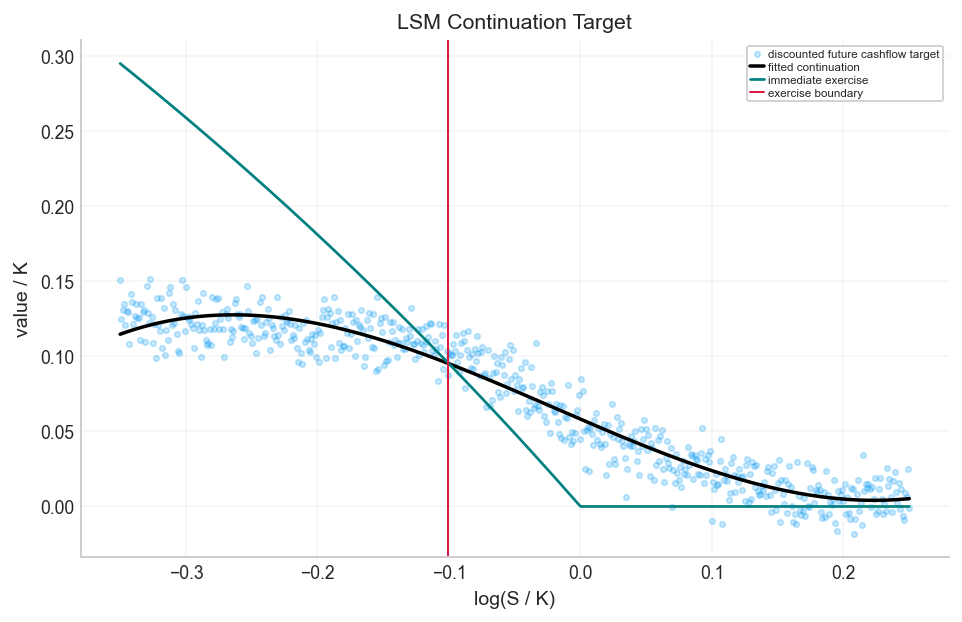

In [52]:
np.random.seed(7)
x_demo = np.linspace(-0.35, 0.25, 600)
payoff_demo = np.maximum(1.0 - np.exp(x_demo), 0.0)
true_cont_demo = 0.42 * payoff_demo + 0.065 * np.exp(-((x_demo + 0.08) / 0.18) ** 2)
cashflow_demo = true_cont_demo + np.random.normal(0.0, 0.012, size=x_demo.size)
beta_demo = np.polyfit(x_demo, cashflow_demo, 3)
fit_demo = np.polyval(beta_demo, x_demo)
exercise_demo = payoff_demo > fit_demo
boundary_demo = x_demo[exercise_demo][-1] if exercise_demo.any() else np.nan
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(x_demo, cashflow_demo, s=8, alpha=0.22, label="discounted future cashflow target")
ax.plot(x_demo, fit_demo, color="black", lw=1.8, label="fitted continuation")
ax.plot(x_demo, payoff_demo, color=palette[3], lw=1.4, label="immediate exercise")
if np.isfinite(boundary_demo):
    ax.axvline(boundary_demo, color=palette[6], lw=1.0, label="exercise boundary")
ax.set_xlabel("log(S / K)")
ax.set_ylabel("value / K")
ax.set_title("LSM Continuation Target")
ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
plt.show()


In [53]:
@njit
def make_paths(s0, r, q, sigma, tau, normals):
    paths, steps = normals.shape
    out = np.empty((paths, steps + 1))
    dt = tau / steps
    drift = (r - q - 0.5 * sigma * sigma) * dt
    vol = sigma * math.sqrt(dt)
    for i in range(paths):
        out[i, 0] = s0
        for t in range(steps):
            out[i, t + 1] = out[i, t] * math.exp(drift + vol * normals[i, t])
    return out


In [54]:
@njit
def basis(x, degree):
    out = np.empty(degree + 1)
    out[0] = 1.0
    for j in range(1, degree + 1):
        out[j] = out[j - 1] * x
    return out


In [55]:
@njit
def solve_linear(a, b):
    n = b.size
    aug = np.empty((n, n + 1))
    for i in range(n):
        for j in range(n):
            aug[i, j] = a[i, j]
        aug[i, n] = b[i]
    for i in range(n):
        pivot = i
        best = abs(aug[i, i])
        for rrow in range(i + 1, n):
            val = abs(aug[rrow, i])
            if val > best:
                best = val
                pivot = rrow
        if pivot != i:
            for j in range(i, n + 1):
                tmp = aug[i, j]
                aug[i, j] = aug[pivot, j]
                aug[pivot, j] = tmp
        diag = aug[i, i]
        if abs(diag) < 1e-12:
            diag = 1e-12
        for j in range(i, n + 1):
            aug[i, j] /= diag
        for rrow in range(n):
            if rrow != i:
                f = aug[rrow, i]
                for j in range(i, n + 1):
                    aug[rrow, j] -= f * aug[i, j]
    x = np.empty(n)
    for i in range(n):
        x[i] = aug[i, n]
    return x


In [56]:
@njit
def lsm_train(paths, strike, r, tau, flag, degree):
    n_paths, cols = paths.shape
    steps = cols - 1
    dt = tau / steps
    cash = np.empty(n_paths)
    ex_time = np.full(n_paths, steps)
    coeffs = np.zeros((steps + 1, degree + 1))
    for i in range(n_paths):
        cash[i] = payoff(paths[i, steps], strike, flag)
    for t in range(steps - 1, 0, -1):
        rows = 0
        for i in range(n_paths):
            if payoff(paths[i, t], strike, flag) > 0.0:
                rows += 1
        if rows >= degree + 2:
            ata = np.zeros((degree + 1, degree + 1))
            aty = np.zeros(degree + 1)
            for i in range(n_paths):
                ex = payoff(paths[i, t], strike, flag)
                if ex > 0.0:
                    x = math.log(paths[i, t] / strike)
                    b = basis(x, degree)
                    y = cash[i] * math.exp(-r * dt * (ex_time[i] - t))
                    for a in range(degree + 1):
                        aty[a] += b[a] * y
                        for c in range(degree + 1):
                            ata[a, c] += b[a] * b[c]
            beta = solve_linear(ata, aty)
            for j in range(degree + 1):
                coeffs[t, j] = beta[j]
            for i in range(n_paths):
                ex = payoff(paths[i, t], strike, flag)
                if ex > 0.0:
                    x = math.log(paths[i, t] / strike)
                    b = basis(x, degree)
                    cont = 0.0
                    for j in range(degree + 1):
                        cont += beta[j] * b[j]
                    if ex > cont:
                        cash[i] = ex
                        ex_time[i] = t
    price = 0.0
    for i in range(n_paths):
        price += cash[i] * math.exp(-r * dt * ex_time[i])
    return price / n_paths, ex_time, coeffs


In [57]:
@njit
def lsm_value(paths, strike, r, tau, flag, coeffs):
    n_paths, cols = paths.shape
    steps = cols - 1
    dt = tau / steps
    degree = coeffs.shape[1] - 1
    cash = np.empty(n_paths)
    ex_time = np.full(n_paths, steps)
    for i in range(n_paths):
        cash[i] = payoff(paths[i, steps], strike, flag)
    for t in range(1, steps):
        for i in range(n_paths):
            if ex_time[i] == steps:
                ex = payoff(paths[i, t], strike, flag)
                if ex > 0.0:
                    x = math.log(paths[i, t] / strike)
                    b = basis(x, degree)
                    cont = 0.0
                    for j in range(degree + 1):
                        cont += coeffs[t, j] * b[j]
                    if ex > cont:
                        cash[i] = ex
                        ex_time[i] = t
    price = 0.0
    for i in range(n_paths):
        price += cash[i] * math.exp(-r * dt * ex_time[i])
    return price / n_paths, ex_time


In [58]:
@njit
def lsm_cashflow_target(paths, strike, r, tau, flag, coeffs, t0):
    n_paths, cols = paths.shape
    steps = cols - 1
    dt = tau / steps
    degree = coeffs.shape[1] - 1
    target = np.empty(n_paths)
    immediate = np.empty(n_paths)
    decision = np.zeros(n_paths)
    for i in range(n_paths):
        immediate[i] = payoff(paths[i, t0], strike, flag)
        cash = payoff(paths[i, steps], strike, flag)
        ex_time = steps
        for t in range(t0 + 1, steps):
            ex = payoff(paths[i, t], strike, flag)
            if ex > 0.0:
                x = math.log(paths[i, t] / strike)
                b = basis(x, degree)
                cont = 0.0
                for j in range(degree + 1):
                    cont += coeffs[t, j] * b[j]
                if ex > cont:
                    cash = ex
                    ex_time = t
                    break
        x0 = math.log(paths[i, t0] / strike)
        b0 = basis(x0, degree)
        cont0 = 0.0
        for j in range(degree + 1):
            cont0 += coeffs[t0, j] * b0[j]
        if immediate[i] > cont0 and immediate[i] > 0.0:
            decision[i] = 1.0
        target[i] = cash * math.exp(-r * dt * (ex_time - t0))
    return target, immediate, decision


In [59]:
def antithetic_normals(paths, steps, seed):
    rng = np.random.default_rng(seed)
    half = int(math.ceil(paths / 2))
    z = rng.standard_normal((half, steps))
    z = np.vstack([z, -z])[:paths]
    return z


,train_price,evaluation_price,tree_reference,reference_gap,exercise_probability
0,67.11104,66.918092,66.846885,-0.071207,0.943875


,paths,basis_degree,seed_rep,train_price,evaluation_price,reference_gap,exercise_probability,runtime_sec
0,16000,2,0,66.905195,66.867915,-0.021030,0.899438,0.142354
1,16000,3,0,66.900088,66.772146,0.074739,0.948875,0.147556
2,16000,3,1,67.011826,66.872786,-0.025902,0.928500,0.146433
3,16000,3,2,66.918485,66.775701,0.071184,0.928562,0.140900
4,16000,4,0,67.034751,66.941384,-0.094499,0.956438,0.149479
5,64000,2,0,66.782463,66.856250,-0.009365,0.897297,0.627518
6,64000,3,0,66.936537,66.891823,-0.044938,0.899062,0.669118
7,64000,3,1,66.989451,66.819189,0.027696,0.924719,0.648441
8,64000,3,2,66.851862,66.849156,-0.002271,0.914672,0.743126
9,64000,4,0,66.884894,66.810951,0.035934,0.946938,0.780157


,paths,evaluation_price,price_std,reference_gap,runtime_sec,exercise_probability,price_se,ci_low,ci_high
0,16000,66.806878,0.057106,0.040007,0.146433,0.935312,0.032970,66.742256,66.871500
1,64000,66.853389,0.036502,-0.006504,0.669118,0.912818,0.021074,66.812084,66.894694
2,128000,66.773729,0.028704,0.073156,1.571610,0.920911,0.016573,66.741247,66.806211
3,256000,66.821925,0.014423,0.024960,2.921103,0.926467,0.008327,66.805603,66.838246


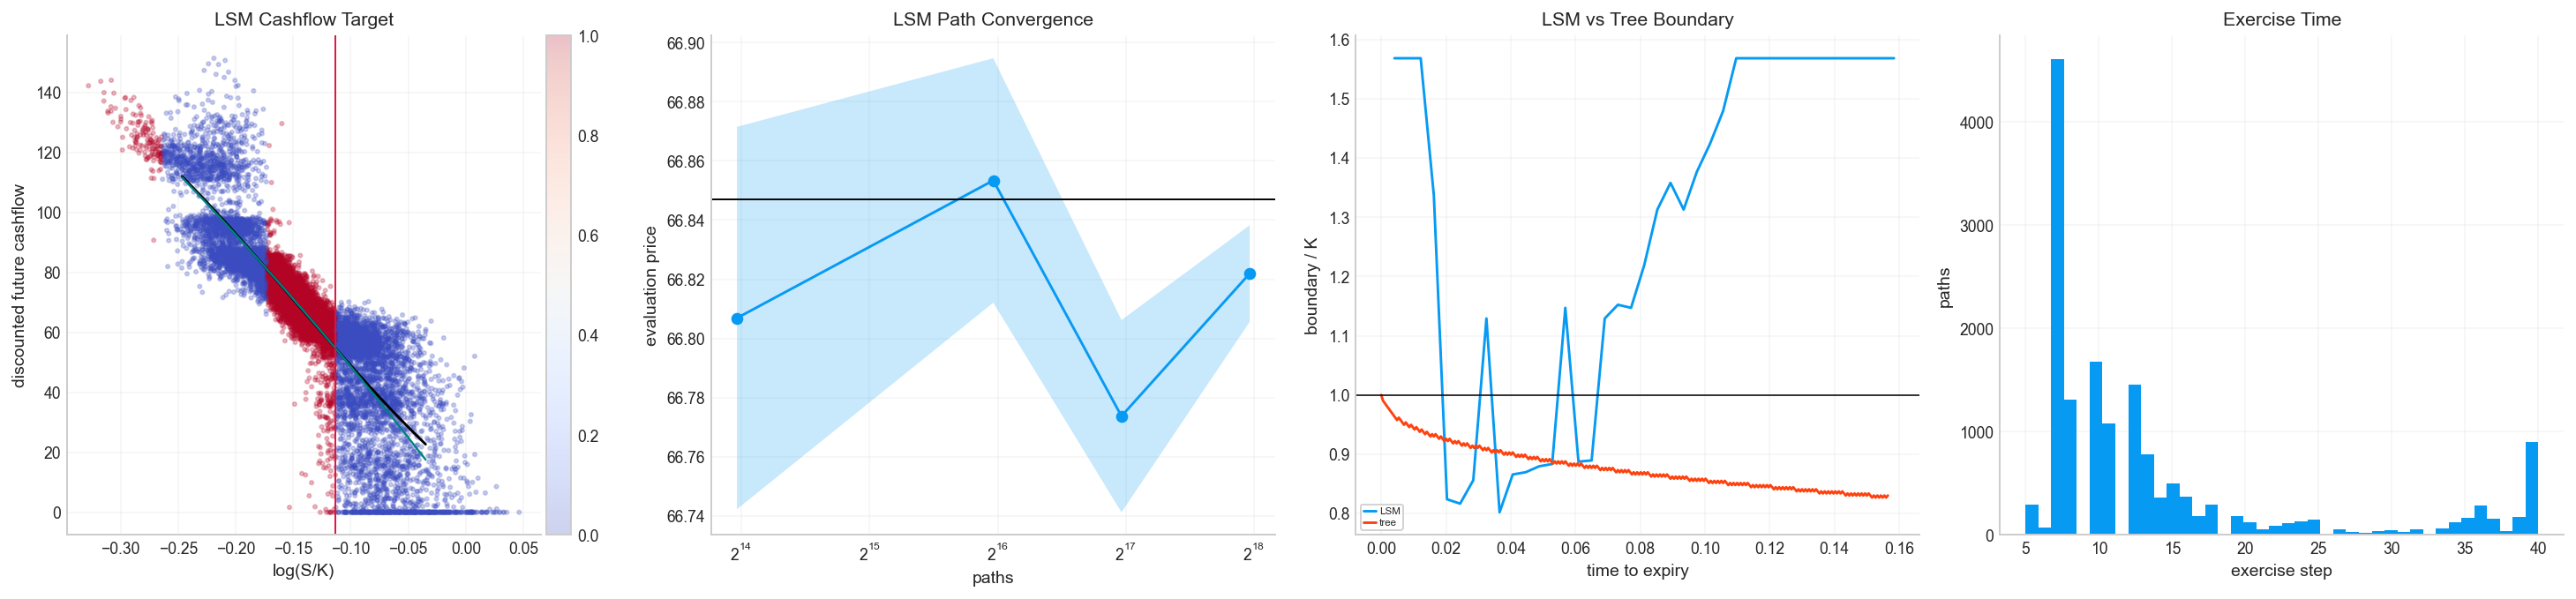

In [60]:
lsm_row = put_row
lsm_steps = 40
z_train = antithetic_normals(16000, lsm_steps, 13)
z_eval = antithetic_normals(16000, lsm_steps, 1013)
train_paths = make_paths(float(lsm_row["spot"]), float(lsm_row["rate"]), float(lsm_row["dividend_yield"]), float(lsm_row["sigma_used"]), float(lsm_row["tau"]), z_train)
eval_paths = make_paths(float(lsm_row["spot"]), float(lsm_row["rate"]), float(lsm_row["dividend_yield"]), float(lsm_row["sigma_used"]), float(lsm_row["tau"]), z_eval)
train_price, train_exercise, coeffs = lsm_train(train_paths, float(lsm_row["strike"]), float(lsm_row["rate"]), float(lsm_row["tau"]), int(option_flag([lsm_row["option_type"]])[0]), 3)
eval_price, eval_exercise = lsm_value(eval_paths, float(lsm_row["strike"]), float(lsm_row["rate"]), float(lsm_row["tau"]), int(option_flag([lsm_row["option_type"]])[0]), coeffs)
reference_gap = ref - eval_price

lsm_stability_rows = []
for paths in [16000, 64000, 128000, 256000]:
    for degree in [2, 3, 4]:
        reps = [0, 1, 2] if degree == 3 else [0]
        for rep in reps:
            z1 = antithetic_normals(paths, lsm_steps, 31 + paths + degree + 97 * rep)
            z2 = antithetic_normals(paths, lsm_steps, 1031 + paths + degree + 197 * rep)
            t0 = time.perf_counter()
            p1 = make_paths(float(lsm_row["spot"]), float(lsm_row["rate"]), float(lsm_row["dividend_yield"]), float(lsm_row["sigma_used"]), float(lsm_row["tau"]), z1)
            p2 = make_paths(float(lsm_row["spot"]), float(lsm_row["rate"]), float(lsm_row["dividend_yield"]), float(lsm_row["sigma_used"]), float(lsm_row["tau"]), z2)
            tr, ex_tr, cf = lsm_train(p1, float(lsm_row["strike"]), float(lsm_row["rate"]), float(lsm_row["tau"]), int(option_flag([lsm_row["option_type"]])[0]), degree)
            ev, ex_ev = lsm_value(p2, float(lsm_row["strike"]), float(lsm_row["rate"]), float(lsm_row["tau"]), int(option_flag([lsm_row["option_type"]])[0]), cf)
            elapsed = time.perf_counter() - t0
            lsm_stability_rows.append({"paths": paths, "basis_degree": degree, "seed_rep": rep, "train_price": tr, "evaluation_price": ev, "reference_gap": ref - ev, "exercise_probability": float(np.mean(ex_ev < lsm_steps)), "runtime_sec": elapsed})
lsm_path_convergence = pd.DataFrame(lsm_stability_rows)
lsm_path_ci = lsm_path_convergence[lsm_path_convergence["basis_degree"].eq(3)].groupby("paths").agg(evaluation_price=("evaluation_price", "mean"), price_std=("evaluation_price", "std"), reference_gap=("reference_gap", "mean"), runtime_sec=("runtime_sec", "median"), exercise_probability=("exercise_probability", "mean")).reset_index()
lsm_path_ci["price_se"] = lsm_path_ci["price_std"].fillna(0.0) / np.sqrt(3.0)
lsm_path_ci["ci_low"] = lsm_path_ci["evaluation_price"] - 1.96 * lsm_path_ci["price_se"]
lsm_path_ci["ci_high"] = lsm_path_ci["evaluation_price"] + 1.96 * lsm_path_ci["price_se"]
display(pd.DataFrame([{"train_price": train_price, "evaluation_price": eval_price, "tree_reference": ref, "reference_gap": reference_gap, "exercise_probability": float(np.mean(eval_exercise < lsm_steps))}]).round(6))
display(lsm_path_convergence.round(6))
display(lsm_path_ci.round(6))

t_mid = int(lsm_steps * 0.5)
x = np.log(train_paths[:, t_mid] / float(lsm_row["strike"]))
cash_target, immediate_payoff_mid, exercise_decision_mid = lsm_cashflow_target(train_paths, float(lsm_row["strike"]), float(lsm_row["rate"]), float(lsm_row["tau"]), int(option_flag([lsm_row["option_type"]])[0]), coeffs, t_mid)
grid_x = np.linspace(np.nanquantile(x, 0.02), np.nanquantile(x, 0.98), 300)
cont = np.zeros_like(grid_x)
for j in range(coeffs.shape[1]):
    cont += coeffs[t_mid, j] * grid_x ** j
stock_grid_for_lsm = float(lsm_row["strike"]) * np.exp(grid_x)
if str(lsm_row["option_type"]).startswith("c"):
    payoff_curve = np.maximum(stock_grid_for_lsm - float(lsm_row["strike"]), 0.0)
else:
    payoff_curve = np.maximum(float(lsm_row["strike"]) - stock_grid_for_lsm, 0.0)
decision_grid = payoff_curve > cont
boundary_x = grid_x[decision_grid][-1] if decision_grid.any() and not str(lsm_row["option_type"]).startswith("c") else (grid_x[decision_grid][0] if decision_grid.any() else np.nan)
boundary_rows = []
s_grid = float(lsm_row["strike"]) * np.exp(np.linspace(-0.45, 0.45, 401))
for t in range(1, coeffs.shape[0] - 1):
    x_grid = np.log(s_grid / float(lsm_row["strike"]))
    continuation = np.zeros_like(s_grid)
    for j in range(coeffs.shape[1]):
        continuation += coeffs[t, j] * x_grid ** j
    ex = np.maximum(float(lsm_row["strike"]) - s_grid, 0.0) > continuation
    boundary_rows.append({"step": t, "boundary": float(s_grid[ex][-1]) if ex.any() else np.nan})
lsm_boundary_df = pd.DataFrame(boundary_rows)

fig, axes = plt.subplots(1, 4, figsize=(21, 5))
sc = axes[0].scatter(x, cash_target, c=exercise_decision_mid, s=5, alpha=0.25, cmap="coolwarm")
axes[0].plot(grid_x, cont, color="black", lw=1.5)
axes[0].plot(grid_x, payoff_curve, color=palette[3], lw=1.2)
if np.isfinite(boundary_x):
    axes[0].axvline(boundary_x, color=palette[6], lw=1.0)
axes[0].set_title("LSM Cashflow Target")
axes[0].set_xlabel("log(S/K)")
axes[0].set_ylabel("discounted future cashflow")
fig.colorbar(sc, ax=axes[0], pad=0.01)
axes[1].plot(lsm_path_ci["paths"], lsm_path_ci["evaluation_price"], marker="o")
axes[1].fill_between(lsm_path_ci["paths"], lsm_path_ci["ci_low"], lsm_path_ci["ci_high"], alpha=0.22)
axes[1].axhline(ref, color="black", lw=1.0)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("paths")
axes[1].set_ylabel("evaluation price")
axes[1].set_title("LSM Path Convergence")
axes[2].plot(lsm_boundary_df["step"] / lsm_steps * float(lsm_row["tau"]), lsm_boundary_df["boundary"] / float(lsm_row["strike"]), label="LSM")
axes[2].plot(tree_boundary_df["time_to_expiry"], tree_boundary_df["boundary_over_k"], label="tree")
axes[2].axhline(1.0, color="black", lw=0.8)
axes[2].set_title("LSM vs Tree Boundary")
axes[2].set_xlabel("time to expiry")
axes[2].set_ylabel("boundary / K")
axes[2].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
axes[3].hist(eval_exercise, bins=lsm_steps)
axes[3].set_title("Exercise Time")
axes[3].set_xlabel("exercise step")
axes[3].set_ylabel("paths")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


,full_chain_rows,lsm_regime_cells,covered_rows,coverage_pct,paths_per_cell
0,1839734,1095,1839734,1.0,64000


,option_type,dividend_bucket,count,sum,median
0,call,dividend,370,509493,554.0
1,call,none,164,383627,217.5
2,put,dividend,398,537746,597.5
3,put,none,163,408868,285.0


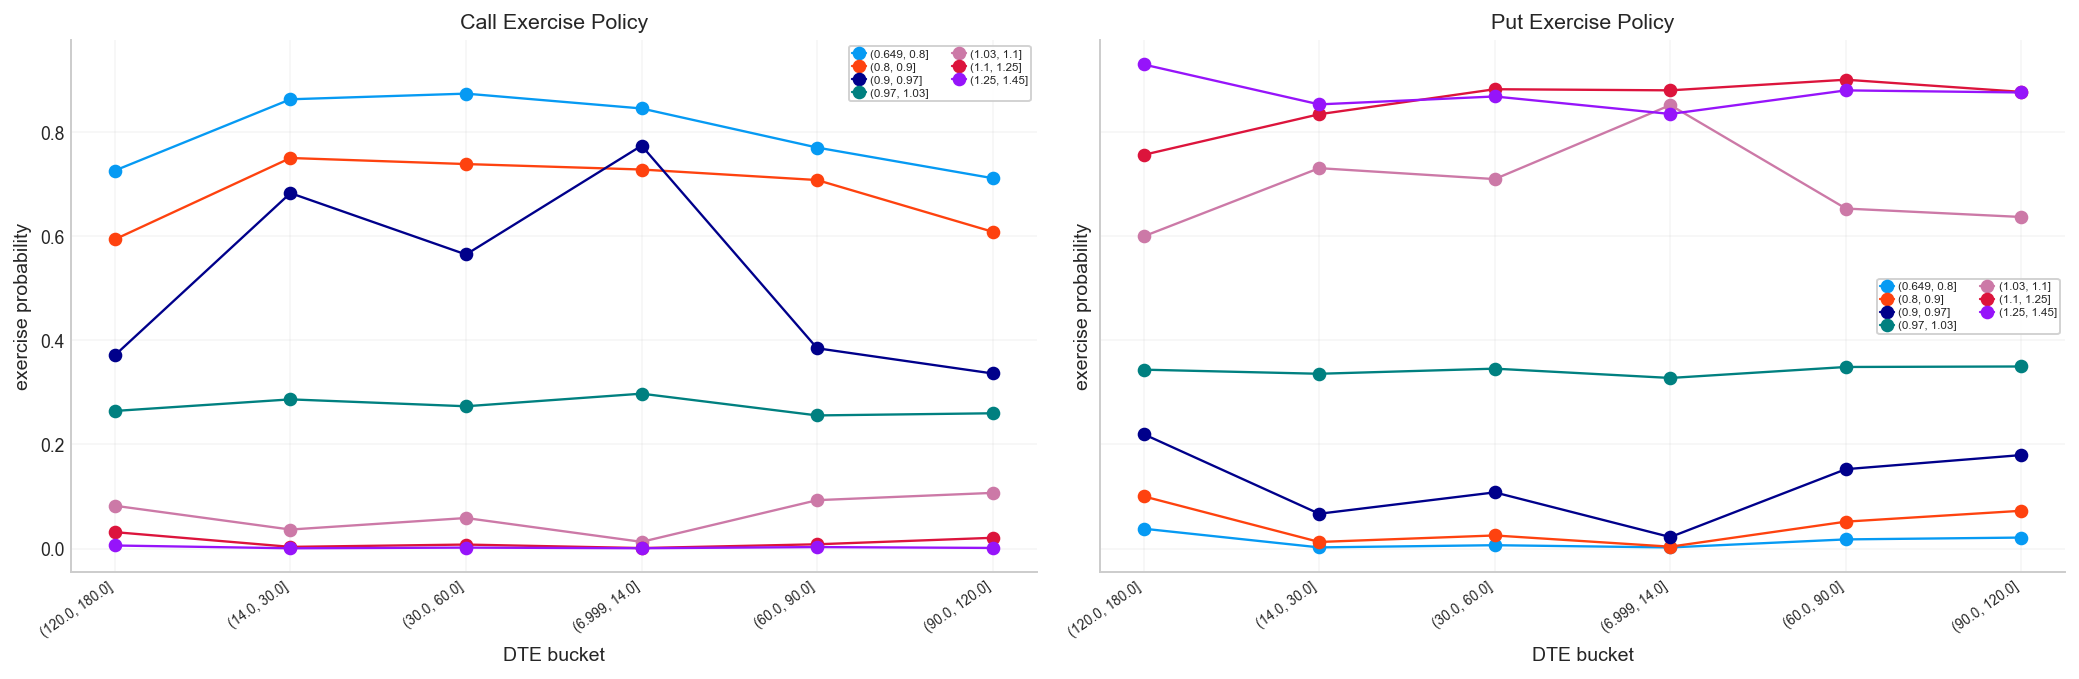

In [61]:
from quantfinlab import _kernels

lsm_cache = cache_dir / "spy_lsm_regime.parquet"
lsm_meta = cache_dir / "spy_lsm_regime.meta.json"
lsm_settings = {"dataset": "SPY OptionsDX 2022-2023", "method": "lsm_empirical_regime_grid", "paths": 64000, "steps": 40, "degree": 3, "eval_repeats": 3, "engine": "cpp", "keys": ["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket"]}
lsm_regime = regime_grid(spy_quotes)
use_lsm_cache = lsm_cache.exists() and lsm_meta.exists() and json.loads(lsm_meta.read_text()).get("settings") == lsm_settings
if use_lsm_cache:
    lsm_regime_results = pd.read_parquet(lsm_cache)
else:
    lsm_records = []
    for i, row in lsm_regime.iterrows():
        cpp_train_paths = _kernels.gbm_paths_antithetic(float(row["spot"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), 40, 64000, 17 + i)
        flag = int(option_flag([row["option_type"]])[0])
        train = _kernels.lsm_backward(cpp_train_paths, float(row["strike"]), float(row["rate"]), float(row["tau"]), flag, 3)
        eval_prices = []
        exercise_rates = []
        for rep in range(3):
            cpp_eval_paths = _kernels.gbm_paths_antithetic(float(row["spot"]), float(row["rate"]), float(row["dividend_yield"]), float(row["sigma_used"]), float(row["tau"]), 40, 64000, 10017 + i + rep * 7919)
            val = _kernels.lsm_eval_policy(cpp_eval_paths, float(row["strike"]), float(row["rate"]), float(row["tau"]), flag, train["coefficients"])
            ex_time = np.asarray(val["exercise_time"])
            eval_prices.append(float(val["price"]))
            exercise_rates.append(float(np.mean(ex_time < 40)))
        eval_prices = np.asarray(eval_prices)
        price_se = float(eval_prices.std(ddof=1) / np.sqrt(3.0))
        lsm_records.append({"date": row["date"], "expiry": row["expiry"], "option_type": row["option_type"], "spot": row["spot"], "strike": row["strike"], "tau": row["tau"], "dte_days": row["dte_days"], "moneyness": row["moneyness"], "sigma_used": row["sigma_used"], "rate": row["rate"], "dividend_yield": row["dividend_yield"], "coverage_rows": int(row["coverage_rows"]), "lsm_train_price": float(train["price"]), "lsm_price": float(eval_prices.mean()), "lsm_price_std": float(eval_prices.std(ddof=1)), "lsm_price_se": price_se, "lsm_ci_low": float(eval_prices.mean() - 1.96 * price_se), "lsm_ci_high": float(eval_prices.mean() + 1.96 * price_se), "exercise_probability": float(np.mean(exercise_rates)), "exercise_probability_std": float(np.std(exercise_rates, ddof=1)), "paths": 64000, "steps": 40, "basis_degree": 3, "eval_repeats": 3, "dte_bucket": str(row["dte_bucket"]), "moneyness_bucket": str(row["moneyness_bucket"]), "sigma_bucket": str(row["sigma_bucket"]), "dividend_bucket": row["dividend_bucket"], "ex_div_bucket": str(row["ex_div_bucket"])} )
    lsm_regime_results = pd.DataFrame(lsm_records)
    lsm_regime_results.to_parquet(lsm_cache, index=False)
    lsm_meta.write_text(json.dumps({"settings": lsm_settings, "rows": len(lsm_regime_results), "created_utc": pd.Timestamp.now("UTC").isoformat()}, indent=2))

display(pd.DataFrame([{"full_chain_rows": len(spy_quotes), "lsm_regime_cells": len(lsm_regime_results), "covered_rows": int(lsm_regime_results["coverage_rows"].sum()), "coverage_pct": float(lsm_regime_results["coverage_rows"].sum() / len(spy_quotes)), "paths_per_cell": int(lsm_regime_results["paths"].median())}]))
display(lsm_regime_results.groupby(["option_type", "dividend_bucket"], observed=True)["coverage_rows"].agg(["count", "sum", "median"]).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
lsm_policy_curves = []
for ax, opt in zip(axes, ["call", "put"]):
    subset = lsm_regime_results[lsm_regime_results["option_type"].eq(opt)].copy()
    subset["dte_bucket_order"] = pd.Categorical(subset["dte_bucket"], categories=sorted(subset["dte_bucket"].dropna().unique()), ordered=True)
    for label, part in subset.groupby("moneyness_bucket", observed=True):
        grouped = part.groupby("dte_bucket", observed=True).apply(lambda x: np.average(x["exercise_probability"], weights=x["coverage_rows"])).reset_index(name="exercise_probability")
        x = np.arange(len(grouped))
        ax.plot(x, grouped["exercise_probability"], marker="o", lw=1.2, label=str(label))
        lsm_policy_curves.append(grouped.assign(option_type=opt, moneyness_bucket=str(label)))
    ax.set_xticks(np.arange(len(sorted(subset["dte_bucket"].dropna().unique()))))
    ax.set_xticklabels(sorted(subset["dte_bucket"].dropna().unique()), rotation=35, ha="right", fontsize=7)
    ax.set_xlabel("DTE bucket")
    ax.set_ylabel("exercise probability")
    ax.set_title(f"{opt.title()} Exercise Policy")
    ax.legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35, ncol=2)
lsm_policy_curves = pd.concat(lsm_policy_curves, ignore_index=True) if lsm_policy_curves else pd.DataFrame()
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


In [62]:
lsm_uncertainty_table = lsm_regime_results.sort_values("lsm_price_se", ascending=False).head(20).copy()
display(lsm_uncertainty_table[["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket", "coverage_rows", "lsm_price", "lsm_price_se", "exercise_probability"]].round(6))


,option_type,dte_bucket,moneyness_bucket,sigma_bucket,dividend_bucket,ex_div_bucket,coverage_rows,lsm_price,lsm_price_se,exercise_probability
1018,put,"(90.0, 120.0]","(1.25, 1.45]","(0.5, 2.5]",dividend,8_21,3,203.323513,0.181986,0.896276
309,call,"(60.0, 90.0]","(0.649, 0.8]","(0.5, 2.5]",dividend,none,708,150.976163,0.181371,0.841875
487,call,"(120.0, 180.0]","(0.9, 0.97]","(0.15, 0.22]",dividend,none,7228,37.740961,0.145746,0.286229
307,call,"(60.0, 90.0]","(0.649, 0.8]","(0.5, 2.5]",dividend,0_7,16,128.213737,0.144242,0.830938
388,call,"(90.0, 120.0]","(0.649, 0.8]","(0.32, 0.5]",dividend,0_7,1006,105.349159,0.125602,0.856990
481,call,"(120.0, 180.0]","(0.8, 0.9]","(0.32, 0.5]",dividend,none,853,79.522552,0.123254,0.653641
393,call,"(90.0, 120.0]","(0.649, 0.8]","(0.5, 2.5]",dividend,8_21,32,144.023821,0.122797,0.803979
1092,put,"(120.0, 180.0]","(1.25, 1.45]","(0.32, 0.5]",dividend,8_21,759,162.682713,0.120215,0.930448
117,call,"(14.0, 30.0]","(0.8, 0.9]","(0.5, 2.5]",dividend,none,107,77.632383,0.113153,0.883078
932,put,"(60.0, 90.0]","(1.25, 1.45]","(0.5, 2.5]",dividend,none,511,173.951854,0.109170,0.898594


In [63]:
lsm_gap_table = lsm_regime_results.assign(train_eval_gap=lsm_regime_results["lsm_price"] - lsm_regime_results["lsm_train_price"]).sort_values("train_eval_gap", key=lambda x: x.abs(), ascending=False).head(20)
display(lsm_gap_table[["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket", "coverage_rows", "lsm_train_price", "lsm_price", "train_eval_gap", "lsm_price_se"]].round(6))


,option_type,dte_bucket,moneyness_bucket,sigma_bucket,dividend_bucket,ex_div_bucket,coverage_rows,lsm_train_price,lsm_price,train_eval_gap,lsm_price_se
392,call,"(90.0, 120.0]","(0.649, 0.8]","(0.5, 2.5]",dividend,0_7,18,138.584303,138.107060,-0.477243,0.008937
466,call,"(120.0, 180.0]","(0.649, 0.8]","(0.32, 0.5]",dividend,none,8886,121.135249,120.712182,-0.423067,0.075895
211,call,"(30.0, 60.0]","(0.649, 0.8]","(0.32, 0.5]",none,none,4887,113.205617,112.867489,-0.338129,0.042548
388,call,"(90.0, 120.0]","(0.649, 0.8]","(0.32, 0.5]",dividend,0_7,1006,105.680639,105.349159,-0.331480,0.125602
1018,put,"(90.0, 120.0]","(1.25, 1.45]","(0.5, 2.5]",dividend,8_21,3,203.634368,203.323513,-0.310855,0.181986
742,put,"(14.0, 30.0]","(1.25, 1.45]","(0.5, 2.5]",none,none,2100,128.214856,127.913232,-0.301625,0.075981
90,call,"(14.0, 30.0]","(0.649, 0.8]","(0.22, 0.32]",none,none,35,81.615942,81.323284,-0.292658,0.032857
740,put,"(14.0, 30.0]","(1.25, 1.45]","(0.5, 2.5]",dividend,none,602,156.905352,156.620222,-0.285130,0.046428
461,call,"(120.0, 180.0]","(0.649, 0.8]","(0.22, 0.32]",dividend,8_21,753,96.823976,96.540499,-0.283477,0.019364
1004,put,"(90.0, 120.0]","(1.1, 1.25]","(0.32, 0.5]",dividend,0_7,39,110.284203,110.015058,-0.269145,0.069718


,pde_cells,lsm_cells,merged_method_rows,missing_lsm_rows
0,1095,1095,1095,0


,option_type,dte_bucket,moneyness_bucket,rows_represented,tree_price,pde_price,lsm_price,model_disagreement,exercise_probability
48,put,"(120.0, 180.0]","(1.25, 1.45]",11726,131.763217,131.797180,131.470888,0.189922,0.876039
62,put,"(30.0, 60.0]","(1.25, 1.45]",7823,122.617739,122.634531,122.604615,0.177255,0.849836
55,put,"(14.0, 30.0]","(1.25, 1.45]",5398,124.001920,124.005574,123.965168,0.176452,0.763359
14,call,"(30.0, 60.0]","(0.649, 0.8]",20591,94.403129,94.430982,94.227537,0.176084,0.885786
36,call,"(90.0, 120.0]","(0.8, 0.9]",14781,61.746634,61.773772,61.718643,0.166039,0.599667
66,put,"(6.999, 14.0]","(0.97, 1.03]",45844,5.387674,5.183669,5.367902,0.162949,0.251870
83,put,"(90.0, 120.0]","(1.25, 1.45]",7635,130.822561,130.859438,130.592580,0.162535,0.873742
24,call,"(6.999, 14.0]","(0.97, 1.03]",46773,6.644894,6.432658,6.609286,0.161840,0.358323
53,put,"(14.0, 30.0]","(1.03, 1.1]",42188,28.439498,28.512038,28.423584,0.143598,0.694318
0,call,"(120.0, 180.0]","(0.649, 0.8]",17666,120.919735,120.955933,120.843088,0.137625,0.768935


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3660\2592896659.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(worst_disagreement[["date", "expiry", "option_type", "strike", "moneyness", "dte_days", "american_tree_price_tree", "pde_price", "lsm_price", "model_disagreement", "coverage_rows"]].round(6))


,date,expiry,option_type,strike,moneyness,dte_days,american_tree_price_tree,pde_price,lsm_price,model_disagreement,coverage_rows
572,2023-08-25,2023-09-05,put,440.0,1.000114,10.333333,3.090315,2.232023,3.098816,0.866792,2209
39,2023-08-25,2023-09-05,call,440.0,1.000114,10.333333,3.603141,2.741273,3.584902,0.861869,2360
37,2023-06-15,2023-06-26,call,443.0,1.000881,10.333333,2.676858,1.885617,2.675717,0.791241,1540
1085,2022-02-25,2022-07-15,put,560.0,1.279532,139.333333,124.738193,124.778922,124.167010,0.611912,94
140,2023-06-14,2023-07-07,call,437.0,0.999657,22.333333,4.690059,4.091215,4.668343,0.598844,978
926,2022-03-14,2022-05-20,put,544.0,1.304619,66.333333,130.269385,130.321655,129.757095,0.564560,380
571,2023-09-07,2023-09-20,put,444.0,0.998089,12.333333,3.946964,3.387146,3.917159,0.559818,913
570,2023-06-09,2023-06-20,put,429.0,0.997837,10.333333,3.452908,2.894000,3.431664,0.558908,1700
671,2023-09-07,2023-09-29,put,445.0,1.000337,21.333333,5.317624,4.764606,5.299115,0.553019,1727
620,2022-06-16,2022-06-29,put,475.0,1.294666,12.333333,110.545264,110.571272,110.028431,0.542841,189


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3660\2592896659.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(best_agreement[["date", "expiry", "option_type", "strike", "moneyness", "dte_days", "american_tree_price_tree", "pde_price", "lsm_price", "model_disagreement", "coverage_rows"]].round(6))


,date,expiry,option_type,strike,moneyness,dte_days,american_tree_price_tree,pde_price,lsm_price,model_disagreement,coverage_rows
1036,2022-06-15,2022-10-21,put,315.0,0.830806,127.333333,6.024161,6.024318,6.024816,0.000654,108
7,2023-11-24,2023-12-08,call,396.0,0.869756,13.333333,60.101488,60.101480,60.099930,0.001558,2
473,2023-07-20,2023-12-15,call,402.0,0.889007,147.333333,60.750052,60.749004,60.750786,0.001782,801
566,2023-03-13,2023-03-24,put,357.0,0.926575,10.333333,1.051435,1.050624,1.052450,0.001826,572
356,2022-08-05,2022-10-21,call,439.0,1.061823,76.333333,4.723951,4.726198,4.725735,0.002248,5276
706,2022-03-02,2022-04-01,put,484.0,1.105553,29.333333,47.525395,47.525834,47.522939,0.002895,5
728,2022-06-07,2022-06-30,put,585.0,1.407299,22.333333,170.575508,170.575475,170.572198,0.003310,1
729,2022-03-09,2022-03-31,put,560.0,1.310371,21.333333,133.947068,133.947044,133.943745,0.003322,1
202,2023-07-14,2023-08-18,call,320.0,0.712314,34.333333,130.855815,130.855770,130.852476,0.003338,1
86,2022-09-21,2022-09-30,call,503.0,1.332803,8.333333,0.003265,0.006188,0.001837,0.004351,200


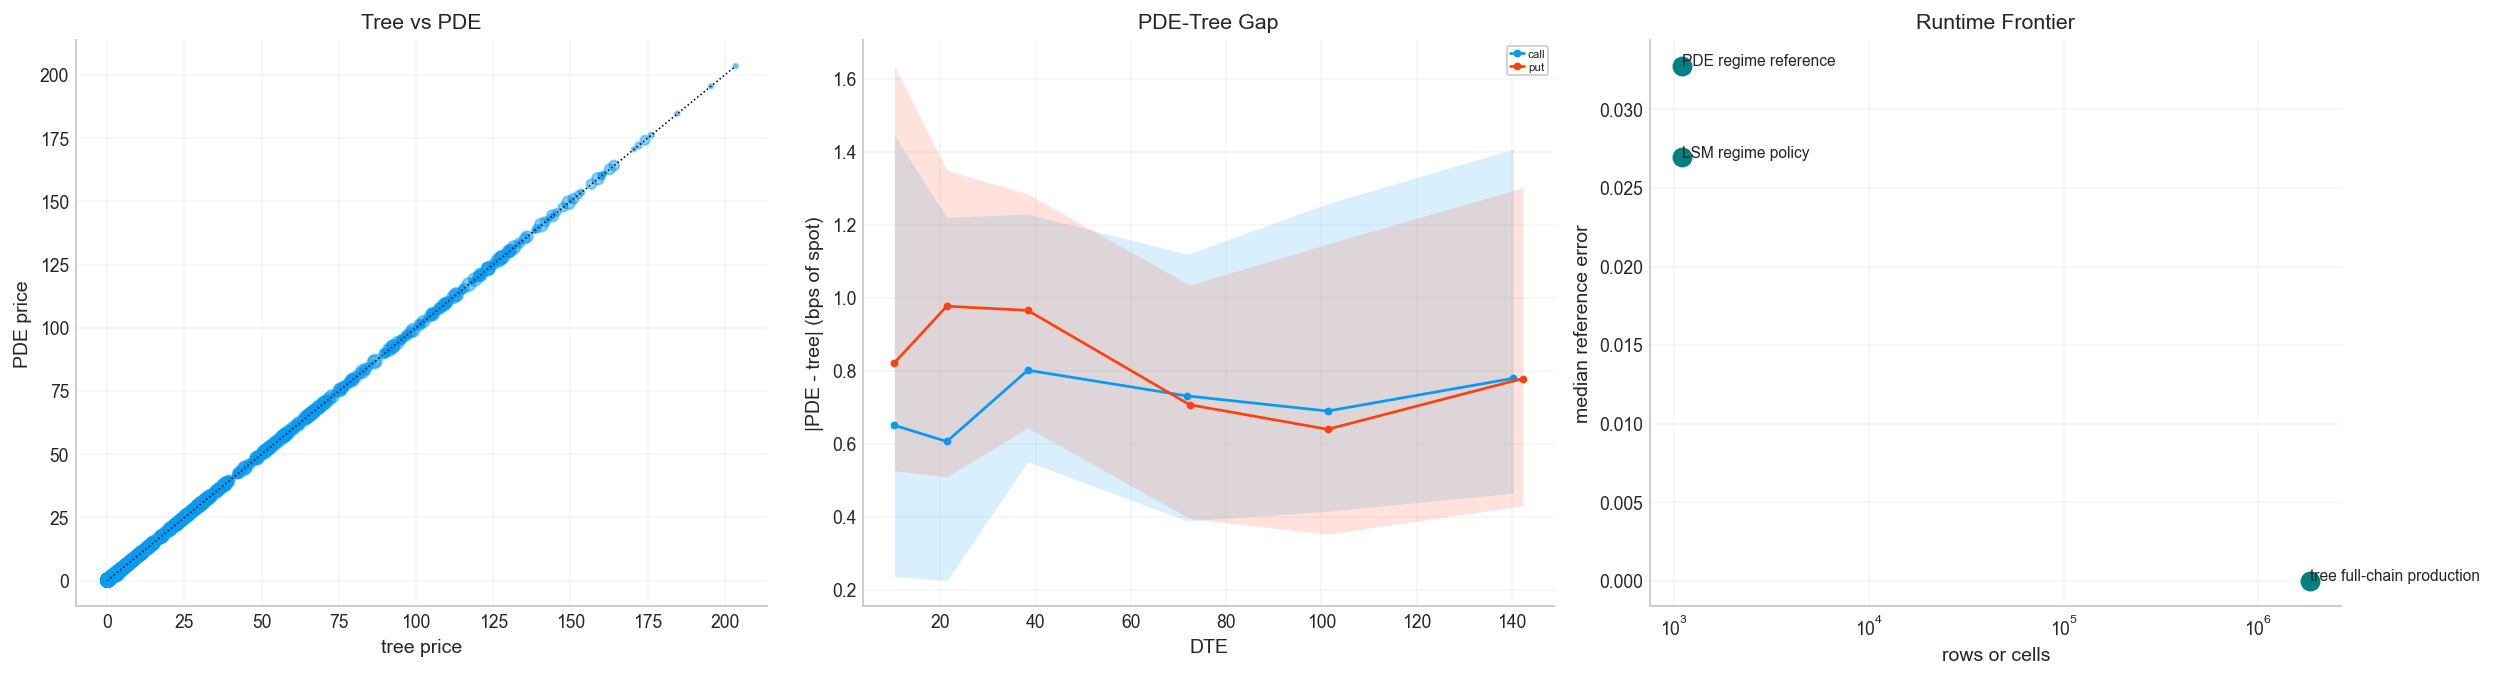

In [64]:
method_keys = ["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket"]
for name in method_keys:
    pde_tree[name] = pde_tree[name].astype(str)
    lsm_regime_results[name] = lsm_regime_results[name].astype(str)
method_comparison = pde_tree.merge(lsm_regime_results[method_keys + ["lsm_price", "lsm_price_se", "lsm_ci_low", "lsm_ci_high", "exercise_probability"]], on=method_keys, how="left", validate="one_to_one")
method_comparison["model_disagreement"] = np.nanmax(method_comparison[["american_tree_price_tree", "pde_price", "lsm_price"]].to_numpy(float), axis=1) - np.nanmin(method_comparison[["american_tree_price_tree", "pde_price", "lsm_price"]].to_numpy(float), axis=1)
method_comparison["tree_lsm_reference_gap"] = method_comparison["american_tree_price_tree"] - method_comparison["lsm_price"]
method_disagreement = method_comparison.copy()
display(pd.DataFrame([{"pde_cells": len(pde_tree), "lsm_cells": len(lsm_regime_results), "merged_method_rows": len(method_comparison), "missing_lsm_rows": int(method_comparison["lsm_price"].isna().sum())}]))
method_summary = method_comparison.groupby(["option_type", "dte_bucket", "moneyness_bucket"], observed=True).agg(rows_represented=("coverage_rows", "sum"), tree_price=("american_tree_price_tree", "median"), pde_price=("pde_price", "median"), lsm_price=("lsm_price", "median"), model_disagreement=("model_disagreement", "median"), exercise_probability=("exercise_probability", "median")).reset_index()
worst_disagreement = method_comparison.sort_values("model_disagreement", ascending=False).iloc[:20].copy()
best_agreement = method_comparison.sort_values("model_disagreement", ascending=True).iloc[:20].copy()
display(method_summary.sort_values("model_disagreement", ascending=False).iloc[:30].round(6))
display(worst_disagreement[["date", "expiry", "option_type", "strike", "moneyness", "dte_days", "american_tree_price_tree", "pde_price", "lsm_price", "model_disagreement", "coverage_rows"]].round(6))
display(best_agreement[["date", "expiry", "option_type", "strike", "moneyness", "dte_days", "american_tree_price_tree", "pde_price", "lsm_price", "model_disagreement", "coverage_rows"]].round(6))

frontier = pd.DataFrame([
    {"method": "tree full-chain production", "runtime_sec": float(tree_full_chain["tree_runtime_sec_total"].median()), "median_abs_error": 0.0, "rows_or_cells": len(tree_full_chain)},
    {"method": "PDE regime reference", "runtime_sec": np.nan, "median_abs_error": float(method_comparison["pde_tree_disagreement"].abs().median()), "rows_or_cells": len(pde_full_or_regime)},
    {"method": "LSM regime policy", "runtime_sec": np.nan, "median_abs_error": float(method_comparison["tree_lsm_reference_gap"].abs().median()), "rows_or_cells": len(lsm_regime_results)},
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(method_comparison["american_tree_price_tree"], method_comparison["pde_price"], s=np.sqrt(method_comparison["coverage_rows"]).clip(5, 45), alpha=0.45, color=palette[0])
lo = np.nanmin(method_comparison[["american_tree_price_tree", "pde_price"]].to_numpy(float))
hi = np.nanmax(method_comparison[["american_tree_price_tree", "pde_price"]].to_numpy(float))
axes[0].plot([lo, hi], [lo, hi], color="black", lw=0.8, ls=":")
axes[0].set_xlabel("tree price")
axes[0].set_ylabel("PDE price")
axes[0].set_title("Tree vs PDE")
gap_curve = method_comparison.copy()
gap_curve["gap_bps"] = 10000.0 * gap_curve["pde_tree_disagreement"].abs() / gap_curve["spot"].replace(0.0, np.nan)
for i, (opt, group) in enumerate(gap_curve.groupby("option_type", observed=True)):
    by = group.groupby("dte_bucket", observed=True).agg(
        x=("dte_days", "median"),
        med=("gap_bps", "median"),
        lo=("gap_bps", lambda v: np.nanquantile(v, 0.25)),
        hi=("gap_bps", lambda v: np.nanquantile(v, 0.75)),
    ).dropna().sort_values("x")
    axes[1].plot(by["x"], by["med"], marker="o", ms=3, lw=1.4, color=palette[i % len(palette)], label=str(opt))
    axes[1].fill_between(by["x"].to_numpy(float), by["lo"].to_numpy(float), by["hi"].to_numpy(float), color=palette[i % len(palette)], alpha=0.15, lw=0)
axes[1].set_xlabel("DTE")
axes[1].set_ylabel("|PDE - tree| (bps of spot)")
axes[1].set_title("PDE-Tree Gap")
axes[1].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
axes[2].scatter(frontier["rows_or_cells"], frontier["median_abs_error"], s=85, color=palette[3])
for _, row in frontier.iterrows():
    axes[2].annotate(row["method"], (row["rows_or_cells"], row["median_abs_error"]), fontsize=8)
axes[2].set_xscale("log")
axes[2].set_xlabel("rows or cells")
axes[2].set_ylabel("median reference error")
axes[2].set_title("Runtime Frontier")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


,assignment_risk,itm_score,boundary_proximity,dividend_gap_score,low_time_value_score,ex_div_proximity,model_uncertainty_score
count,514523.000000,514523.000000,514523.000000,514523.000000,514523.000000,514523.000000,514523.000000
mean,0.118686,0.108629,0.033798,0.060013,0.438043,0.069246,0.017529
std,0.103060,0.084630,0.141620,0.106408,0.368670,0.201052,0.012300
min,0.000149,0.000024,0.000000,0.000000,0.000000,0.000000,0.000171
5%,0.003503,0.007963,0.000000,0.000000,0.000000,0.000000,0.002761
50%,0.099862,0.087814,0.000000,0.000000,0.460982,0.000000,0.015866
95%,0.301266,0.283030,0.302835,0.302035,0.948800,0.714286,0.037513
max,0.617649,0.349980,1.000000,0.486111,1.000000,0.928571,0.107110


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3660\1479589517.py:30: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(short_call_scores.sort_values("assignment_risk", ascending=False).iloc[:20][["date", "expiry", "option_type", "spot", "strike", "dte_days", "time_value", "next_dividend", "dividend_gap", "pde_boundary_now", "boundary_distance", "model_disagreement", "assignment_risk", "roll_signal"]].round(6))


,date,expiry,option_type,spot,strike,dte_days,time_value,next_dividend,dividend_gap,pde_boundary_now,boundary_distance,model_disagreement,assignment_risk,roll_signal
1799910,2023-12-13,2024-01-12,call,470.53,360.0,29.333333,0.075,1.906,1.831,468.83550,-0.003601,0.097451,0.617649,False
1799649,2023-12-13,2024-01-05,call,470.53,376.0,22.333333,0.070,1.906,1.836,468.83550,-0.003601,0.097451,0.611220,False
1796536,2023-12-12,2024-01-05,call,464.19,382.0,23.333333,0.040,1.906,1.866,462.79800,-0.002999,0.112823,0.604856,False
1796537,2023-12-12,2024-01-05,call,464.19,383.0,23.333333,0.045,1.906,1.861,462.79800,-0.002999,0.112823,0.604048,False
1796539,2023-12-12,2024-01-05,call,464.19,389.0,23.333333,0.040,1.906,1.866,462.79800,-0.002999,0.112823,0.601840,False
1796538,2023-12-12,2024-01-05,call,464.19,387.0,23.333333,0.055,1.906,1.851,462.79800,-0.002999,0.112823,0.601571,False
1796527,2023-12-12,2024-01-05,call,464.19,348.0,23.333333,-0.005,1.906,1.911,468.83550,0.010008,0.097451,0.600805,False
1796526,2023-12-12,2024-01-05,call,464.19,347.0,23.333333,0.015,1.906,1.891,468.83550,0.010008,0.097451,0.599835,False
1796525,2023-12-12,2024-01-05,call,464.19,346.0,23.333333,0.025,1.906,1.881,468.83550,0.010008,0.097451,0.599512,False
1796540,2023-12-12,2024-01-05,call,464.19,394.0,23.333333,0.065,1.906,1.841,462.79800,-0.002999,0.112823,0.597801,False


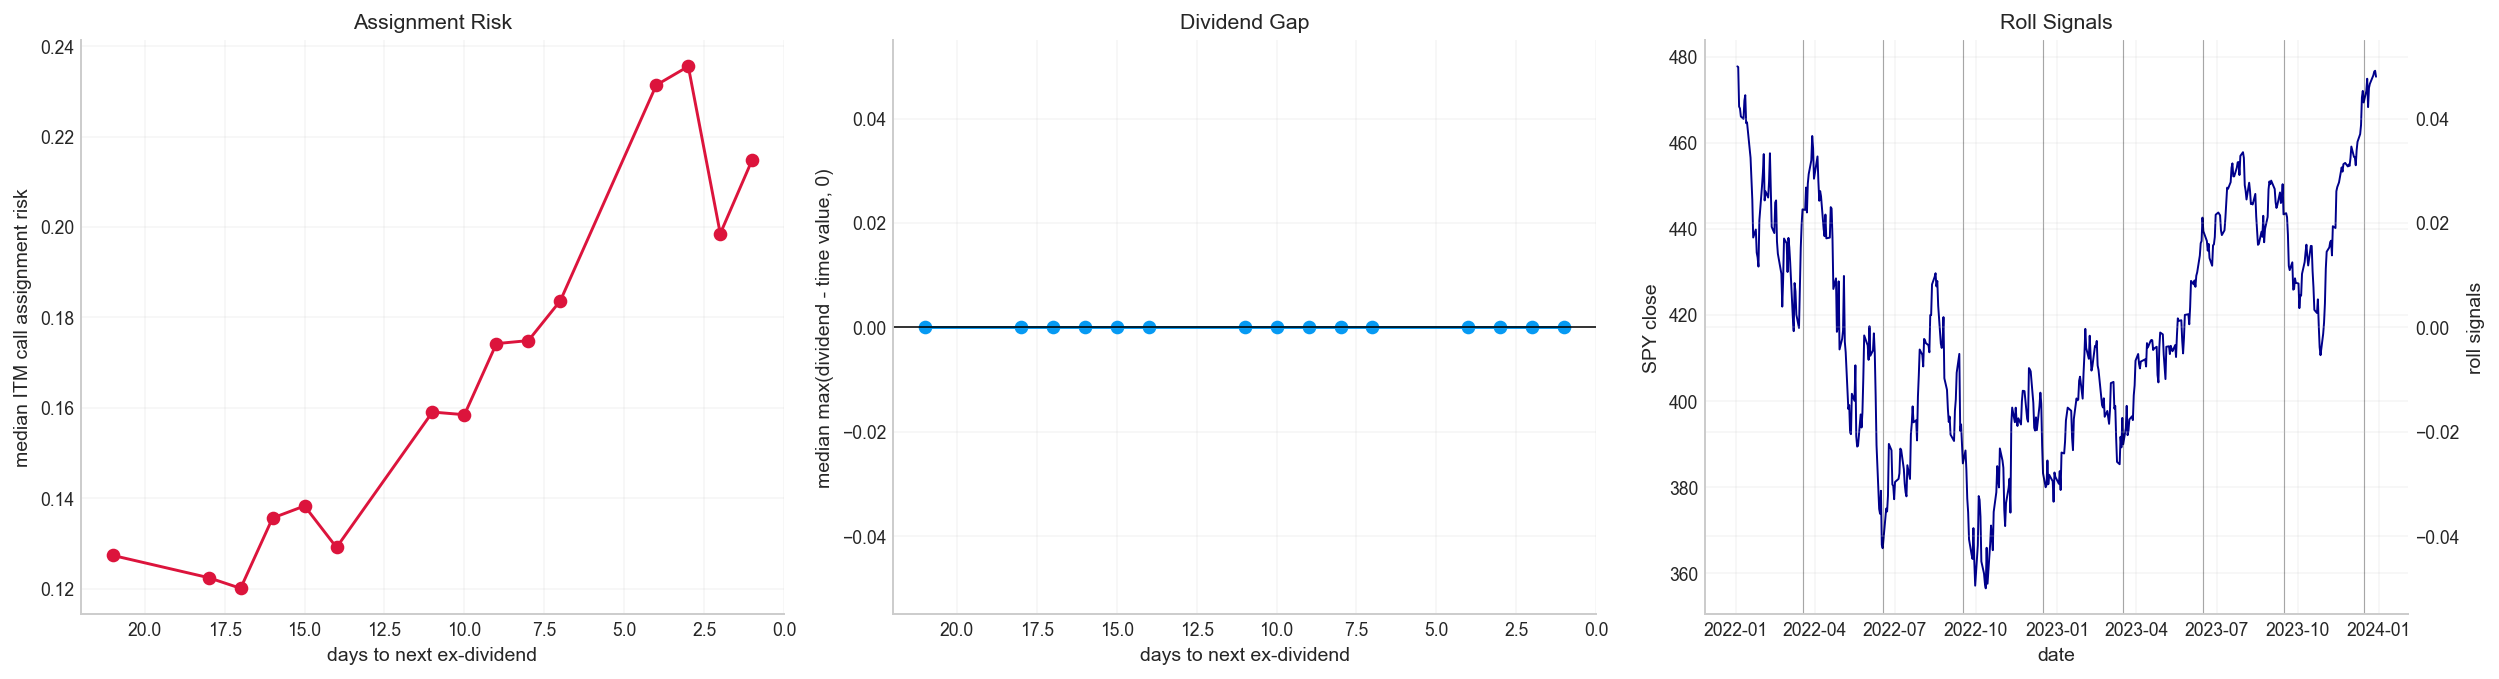

In [65]:
regime_keys = ["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket"]
assignment_scores = tree_full_chain.copy()
assignment_scores["dte_bucket"] = pd.cut(assignment_scores["dte_days"], [7, 14, 30, 60, 90, 120, 180], include_lowest=True)
assignment_scores["moneyness_bucket"] = pd.cut(assignment_scores["moneyness"], [0.65, 0.80, 0.90, 0.97, 1.03, 1.10, 1.25, 1.45], include_lowest=True)
assignment_scores["sigma_bucket"] = pd.cut(assignment_scores["sigma_used"], [0.03, 0.15, 0.22, 0.32, 0.50, 2.50], include_lowest=True)
assignment_scores["dividend_bucket"] = np.where(assignment_scores["dividend_in_life"].gt(0), "dividend", "none")
assignment_scores["ex_div_bucket"] = pd.cut(assignment_scores["days_to_next_dividend"].fillna(10_000), [-1, 7, 21, 10_000], labels=["0_7", "8_21", "none"], include_lowest=True)
for name in regime_keys:
    assignment_scores[name] = assignment_scores[name].astype(str)
regime_method = method_comparison[regime_keys + ["pde_boundary_now", "model_disagreement"]].drop_duplicates(subset=regime_keys)
assignment_scores = assignment_scores.merge(regime_method, on=regime_keys, how="left")
assignment_scores["boundary_distance"] = np.where(assignment_scores["option_type"].eq("call"), (assignment_scores["pde_boundary_now"] - assignment_scores["spot"]) / assignment_scores["spot"], (assignment_scores["spot"] - assignment_scores["pde_boundary_now"]) / assignment_scores["spot"])
assignment_scores.loc[~np.isfinite(assignment_scores["boundary_distance"]), "boundary_distance"] = np.nan
assignment_scores["model_disagreement"] = assignment_scores["model_disagreement"].fillna(assignment_scores["model_disagreement"].median())
assignment_scores["itm_score"] = np.where(assignment_scores["option_type"].eq("call"), np.maximum(assignment_scores["spot"] - assignment_scores["strike"], 0.0), np.maximum(assignment_scores["strike"] - assignment_scores["spot"], 0.0)) / assignment_scores["spot"]
assignment_scores["boundary_proximity"] = (1.0 - assignment_scores["boundary_distance"].abs() / 0.08).clip(0.0, 1.0).fillna(0.0)
assignment_scores["dividend_gap"] = (assignment_scores["next_dividend"] - assignment_scores["time_value"]).clip(lower=0.0)
assignment_scores["dividend_gap_score"] = (assignment_scores["dividend_gap"] / assignment_scores["spot"] / 0.01).clip(0.0, 1.0)
assignment_scores["low_time_value_score"] = (1.0 - (assignment_scores["time_value"] / assignment_scores["spot"] / 0.015)).clip(0.0, 1.0)
assignment_scores["ex_div_proximity"] = (1.0 - assignment_scores["days_to_next_dividend"].fillna(365.0) / 14.0).clip(0.0, 1.0)
assignment_scores["model_uncertainty_score"] = (assignment_scores["model_disagreement"] / assignment_scores["spot"] / 0.02).clip(0.0, 1.0)
assignment_scores["assignment_risk"] = (0.20 * assignment_scores["itm_score"].clip(0, 1) + 0.25 * assignment_scores["boundary_proximity"] + 0.25 * assignment_scores["dividend_gap_score"] + 0.15 * assignment_scores["low_time_value_score"] + 0.10 * assignment_scores["ex_div_proximity"] + 0.05 * assignment_scores["model_uncertainty_score"]).clip(0.0, 1.0)
assignment_scores.loc[~assignment_scores["option_type"].eq("call"), "assignment_risk"] = 0.0
assignment_scores["roll_signal"] = assignment_scores["assignment_risk"].ge(0.75) & assignment_scores["option_type"].eq("call") & assignment_scores["days_to_next_dividend"].between(0, 7)
assignment_scores["contract_key"] = assignment_scores["option_type"].astype(str) + "_" + pd.to_datetime(assignment_scores["expiry"]).dt.strftime("%Y-%m-%d") + "_" + assignment_scores["strike"].round(6).astype(str)
short_call_scores = assignment_scores[assignment_scores["option_type"].eq("call") & assignment_scores["spot"].gt(assignment_scores["strike"])].copy()
event_sample = short_call_scores[short_call_scores["days_to_next_dividend"].between(0, 21)].copy()
event_study = event_sample.groupby("days_to_next_dividend").agg(assignment_median=("assignment_risk", "median"), dividend_gap_median=("dividend_gap", "median"), rows=("assignment_risk", "size")).reset_index()
display(short_call_scores[["assignment_risk", "itm_score", "boundary_proximity", "dividend_gap_score", "low_time_value_score", "ex_div_proximity", "model_uncertainty_score"]].describe(percentiles=[0.05, 0.5, 0.95]).round(6))
display(short_call_scores.sort_values("assignment_risk", ascending=False).iloc[:20][["date", "expiry", "option_type", "spot", "strike", "dte_days", "time_value", "next_dividend", "dividend_gap", "pde_boundary_now", "boundary_distance", "model_disagreement", "assignment_risk", "roll_signal"]].round(6))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(event_study["days_to_next_dividend"], event_study["assignment_median"], marker="o", lw=1.5, color=palette[6])
axes[0].invert_xaxis()
axes[0].set_xlabel("days to next ex-dividend")
axes[0].set_ylabel("median ITM call assignment risk")
axes[0].set_title("Assignment Risk")
axes[1].plot(event_study["days_to_next_dividend"], event_study["dividend_gap_median"], marker="o", lw=1.5, color=palette[0])
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].invert_xaxis()
axes[1].set_xlabel("days to next ex-dividend")
axes[1].set_ylabel("median max(dividend - time value, 0)")
axes[1].set_title("Dividend Gap")
roll_daily = short_call_scores.groupby("date")["roll_signal"].sum().reindex(underlying_2022_2023.index).fillna(0.0)
ax2 = axes[2].twinx()
axes[2].plot(underlying_2022_2023.index, underlying_2022_2023["close"], lw=1.0, color=palette[2])
ax2.bar(roll_daily.index, roll_daily.values, color=palette[6], alpha=0.25, width=1.0)
for d in dividend_events["date"]:
    axes[2].axvline(d, color="black", lw=0.6, alpha=0.35)
axes[2].set_xlabel("date")
axes[2].set_ylabel("SPY close")
ax2.set_ylabel("roll signals")
axes[2].set_title("Roll Signals")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


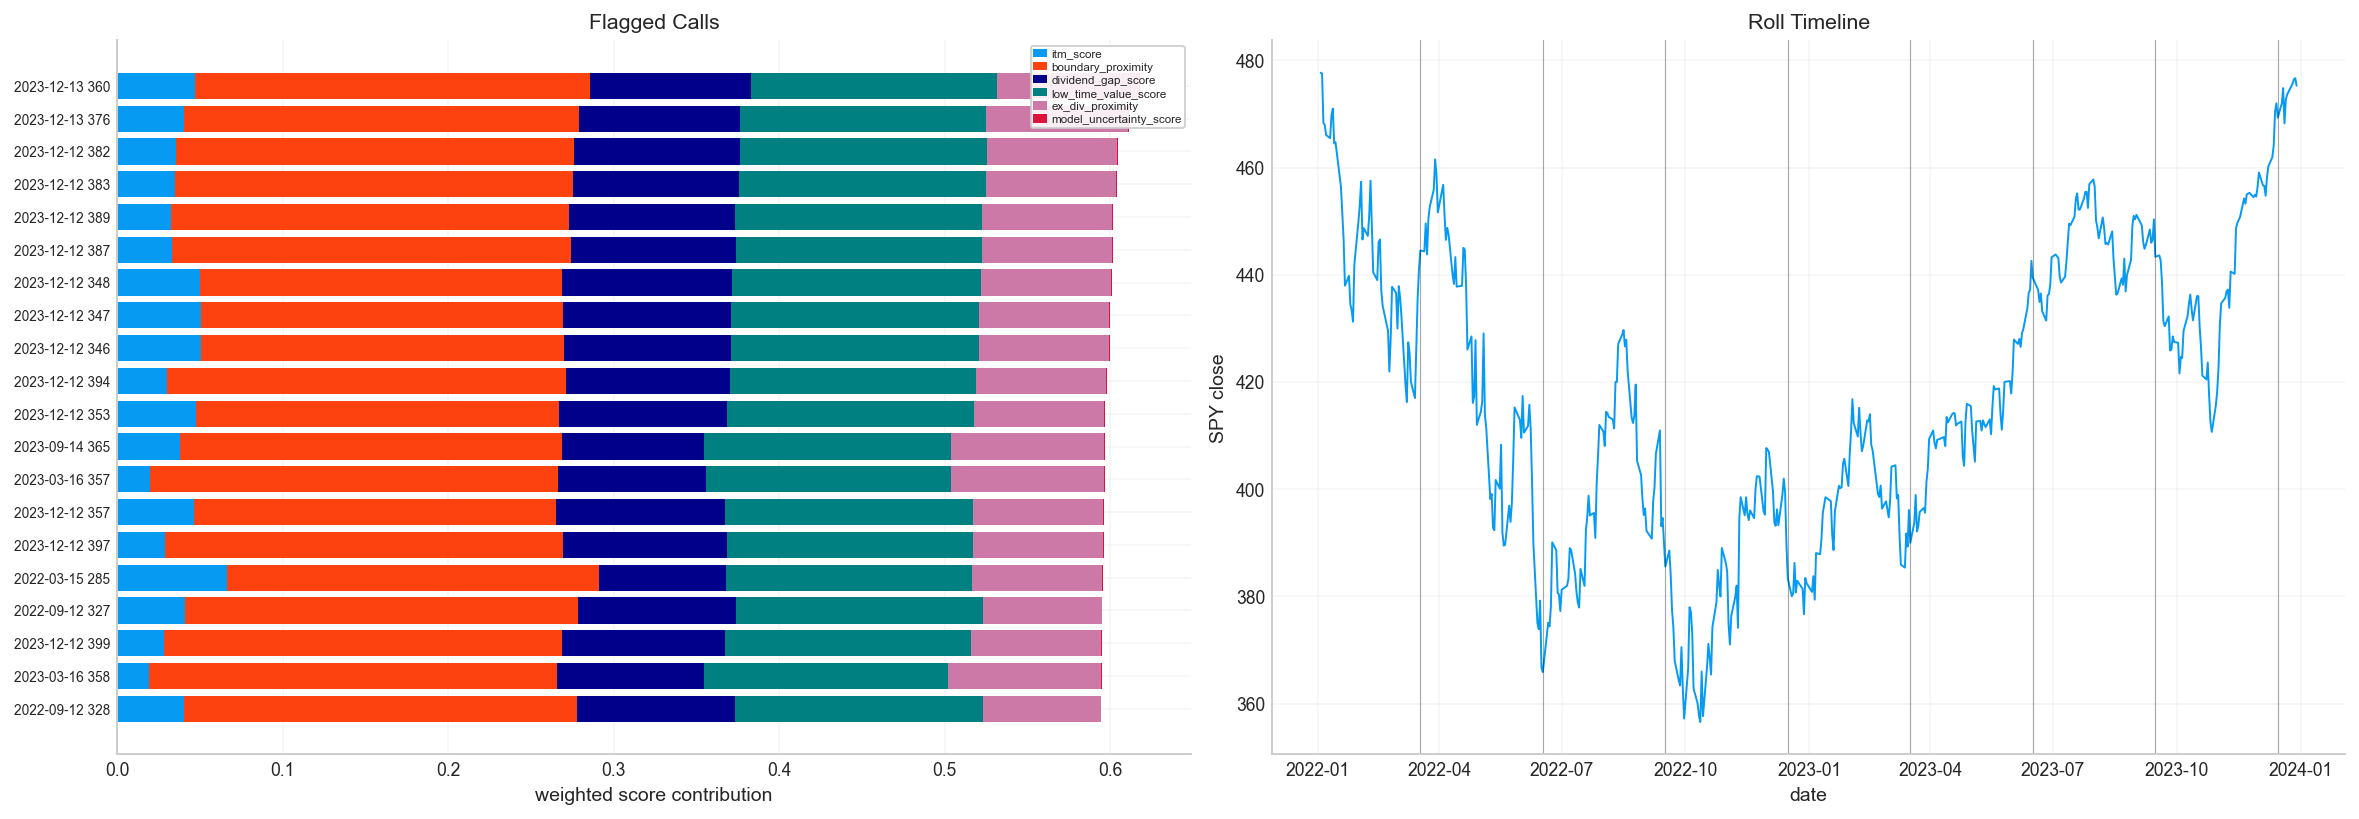

In [66]:
component_cols = ["itm_score", "boundary_proximity", "dividend_gap_score", "low_time_value_score", "ex_div_proximity", "model_uncertainty_score"]
top_calls = short_call_scores.sort_values("assignment_risk", ascending=False).head(20).copy()
component_weights = np.array([0.20, 0.25, 0.25, 0.15, 0.10, 0.05])
component_values = top_calls[component_cols].to_numpy(float) * component_weights
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
left = np.zeros(len(top_calls))
y = np.arange(len(top_calls))
labels = pd.to_datetime(top_calls["date"]).dt.strftime("%Y-%m-%d") + " " + top_calls["strike"].round(0).astype(int).astype(str)
for j, col in enumerate(component_cols):
    axes[0].barh(y, component_values[:, j], left=left, label=col)
    left += component_values[:, j]
axes[0].set_yticks(y)
axes[0].set_yticklabels(labels, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel("weighted score contribution")
axes[0].set_title("Flagged Calls")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
axes[1].plot(underlying_2022_2023.index, underlying_2022_2023["close"], lw=1.0)
roll_dates = short_call_scores.loc[short_call_scores["roll_signal"], "date"]
roll_spot = short_call_scores.loc[short_call_scores["roll_signal"], "spot"]
axes[1].scatter(roll_dates, roll_spot, s=18, color=palette[6], alpha=0.5)
for d in dividend_events["date"]:
    axes[1].axvline(d, color="black", lw=0.6, alpha=0.35)
axes[1].set_xlabel("date")
axes[1].set_ylabel("SPY close")
axes[1].set_title("Roll Timeline")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


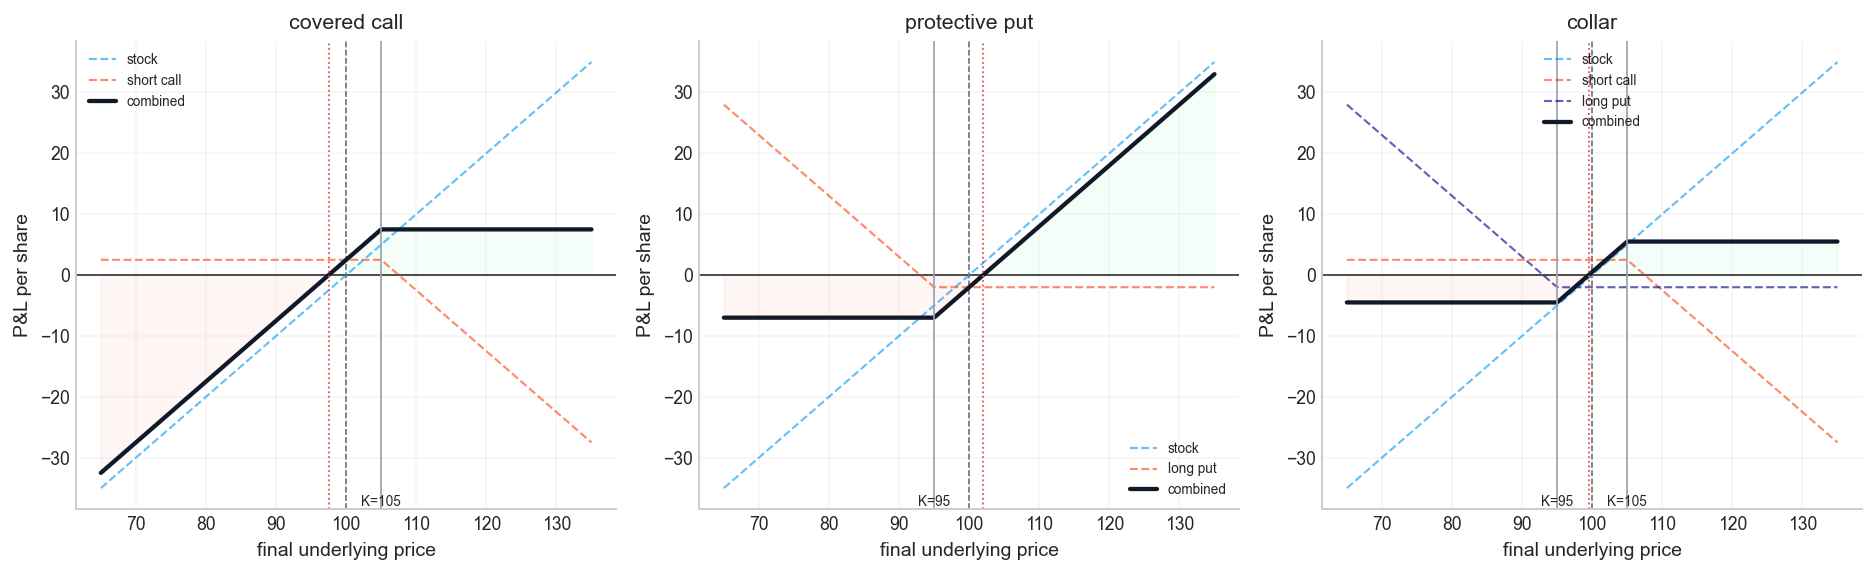

In [67]:
overlay_payoffs()
plt.show()


In [68]:
def contract_key(frame):
    return frame["option_type"].astype(str) + "_" + pd.to_datetime(frame["expiry"]).dt.strftime("%Y-%m-%d") + "_" + frame["strike"].round(6).astype(str)


In [69]:
def choose_one(candidates, score_col, ascending=False):
    if candidates.empty:
        return None
    return candidates.sort_values([score_col, "relative_spread", "dte_days"], ascending=[ascending, True, True]).iloc[0]


In [70]:
def make_schedules(q, dates):
    data = q.copy()
    data["contract_key"] = contract_key(data)
    rows = {name: [] for name in ["buy_hold_spy", "naive_covered_call", "boundary_covered_call", "naive_protective_put", "fair_value_protective_put", "naive_collar", "boundary_aware_collar"]}
    rebalance_dates = pd.Index(dates[::21])
    for d in rebalance_dates:
        day = data[data["date"].eq(d)].copy()
        if day.empty:
            continue
        calls = day[day["option_type"].eq("call") & day["dte_days"].between(25, 60) & day["moneyness"].between(1.00, 1.12)].copy()
        puts = day[day["option_type"].eq("put") & day["dte_days"].between(25, 75) & day["moneyness"].between(0.85, 1.02)].copy()
        if not calls.empty:
            calls["naive_score"] = (calls["moneyness"] - 1.04).abs() + (calls["dte_days"] - 35.0).abs() / ann_days + calls["relative_spread"]
            calls["aware_score"] = -calls["bid"] + 2.0 * calls["assignment_risk"] + calls["relative_spread"] + 0.25 * calls["model_disagreement"] / calls["spot"]
            naive_call = choose_one(calls, "naive_score", True)
            aware_call = choose_one(calls, "aware_score", True)
            rows["naive_covered_call"].append({"entry_date": d, "contract_key": naive_call["contract_key"], "quantity": -10.0, "label": "short_call"})
            rows["boundary_covered_call"].append({"entry_date": d, "contract_key": aware_call["contract_key"], "quantity": -10.0, "label": "short_call"})
        if not puts.empty:
            puts["naive_score"] = (puts["moneyness"] - 0.95).abs() + (puts["dte_days"] - 45.0).abs() / ann_days + puts["relative_spread"]
            puts["fair_value_score"] = (puts["american_tree_price"] - puts["ask"]) / puts["spot"] + 0.50 * np.maximum(0.95 - puts["moneyness"], 0.0) - 0.75 * puts["relative_spread"] - 0.25 * puts["model_disagreement"] / puts["spot"]
            naive_put = choose_one(puts, "naive_score", True)
            fair_put = choose_one(puts, "fair_value_score", False)
            rows["naive_protective_put"].append({"entry_date": d, "contract_key": naive_put["contract_key"], "quantity": 10.0, "label": "long_put"})
            rows["fair_value_protective_put"].append({"entry_date": d, "contract_key": fair_put["contract_key"], "quantity": 10.0, "label": "long_put"})
            if not calls.empty:
                rows["naive_collar"].append({"entry_date": d, "contract_key": naive_put["contract_key"], "quantity": 10.0, "label": "long_put"})
                rows["naive_collar"].append({"entry_date": d, "contract_key": naive_call["contract_key"], "quantity": -10.0, "label": "short_call"})
                rows["boundary_aware_collar"].append({"entry_date": d, "contract_key": fair_put["contract_key"], "quantity": 10.0, "label": "long_put"})
                rows["boundary_aware_collar"].append({"entry_date": d, "contract_key": aware_call["contract_key"], "quantity": -10.0, "label": "short_call"})
    return {name: pd.DataFrame(vals) for name, vals in rows.items()}


In [71]:
def run_overlay(schedules, quotes, price_series, dividend_series, initial_nav=1_000_000.0, shares=1000.0, assignment_threshold=0.25, defense_strategies=None):
    if defense_strategies is None:
        defense_strategies = {"boundary_covered_call", "boundary_aware_collar"}
    book = quotes.copy()
    book["contract_key"] = contract_key(book)
    book["date"] = pd.to_datetime(book["date"]).dt.normalize()
    book["expiry"] = pd.to_datetime(book["expiry"]).dt.normalize()
    dates = pd.Index(pd.to_datetime(price_series.index).normalize())
    prices = pd.Series(price_series.to_numpy(float), index=dates)
    dividends = pd.Series(dividend_series.reindex(dates).fillna(0.0).to_numpy(float), index=dates)
    date_key = {(r["date"], r["contract_key"]): r for _, r in book.iterrows()}
    results = {}
    trades = []
    cash_table = {}
    mark_table = {}
    holdings_table = {}
    for name, schedule in schedules.items():
        cash = initial_nav - shares * prices.iloc[0]
        positions = []
        nav = []
        cash_values = []
        mark_values = []
        holding_values = []
        sched = schedule.copy() if schedule is not None else pd.DataFrame()
        if not sched.empty:
            sched["entry_date"] = pd.to_datetime(sched["entry_date"]).dt.normalize()
        sched_by_date = {d: g for d, g in sched.groupby("entry_date")} if not sched.empty else {}
        for d in dates:
            cash += shares * dividends.loc[d]
            new_positions = []
            for pos in positions:
                key = pos["contract_key"]
                mark = date_key.get((d, key))
                if d >= pos["expiry"]:
                    settle = max(prices.loc[d] - pos["strike"], 0.0) if pos["option_type"] == "call" else max(pos["strike"] - prices.loc[d], 0.0)
                    cashflow = pos["quantity"] * settle * 100.0
                    cash += cashflow
                    trades.append({"strategy": name, "date": d, "event": "expiry_settlement", "contract_key": key, "quantity": pos["quantity"], "cashflow": cashflow, "price": settle, "strike": pos["strike"], "option_type": pos["option_type"]})
                    continue
                if name in defense_strategies and mark is not None and pos["quantity"] < 0 and pos["option_type"] == "call" and mark["assignment_risk"] >= assignment_threshold and pd.notna(mark["days_to_next_dividend"]) and mark["days_to_next_dividend"] <= 7:
                    price = float(mark["ask"])
                    cashflow = pos["quantity"] * price * 100.0
                    cash += cashflow
                    trades.append({"strategy": name, "date": d, "event": "assignment_defense_close", "contract_key": key, "quantity": pos["quantity"], "cashflow": cashflow, "price": price, "strike": pos["strike"], "option_type": pos["option_type"]})
                    continue
                if mark is not None:
                    pos["last_mid"] = float(mark["mid"])
                new_positions.append(pos)
            positions = new_positions
            if d in sched_by_date:
                for _, row in sched_by_date[d].iterrows():
                    label = row["label"]
                    keep = []
                    for pos in positions:
                        if pos["label"] == label:
                            mark = date_key.get((d, pos["contract_key"]))
                            if mark is not None:
                                close_price = float(mark["bid"] if pos["quantity"] > 0 else mark["ask"])
                                cashflow = pos["quantity"] * close_price * 100.0
                                cash += cashflow
                                trades.append({"strategy": name, "date": d, "event": "roll_close", "contract_key": pos["contract_key"], "quantity": pos["quantity"], "cashflow": cashflow, "price": close_price, "strike": pos["strike"], "option_type": pos["option_type"]})
                        else:
                            keep.append(pos)
                    positions = keep
                    key = row["contract_key"]
                    entry = date_key.get((d, key))
                    if entry is None:
                        continue
                    qty = float(row["quantity"])
                    price = float(entry["ask"] if qty > 0 else entry["bid"])
                    cashflow = -qty * price * 100.0
                    cash += cashflow
                    positions.append({"contract_key": key, "quantity": qty, "entry_price": price, "entry_date": d, "expiry": entry["expiry"], "strike": float(entry["strike"]), "option_type": entry["option_type"], "last_mid": float(entry["mid"]), "label": label})
                    trades.append({"strategy": name, "date": d, "event": "open", "contract_key": key, "quantity": qty, "cashflow": cashflow, "price": price, "strike": float(entry["strike"]), "option_type": entry["option_type"], "spread_cost": 0.5 * (entry["ask"] - entry["bid"]) * abs(qty) * 100.0})
            option_mark = 0.0
            for pos in positions:
                mark = date_key.get((d, pos["contract_key"]))
                if mark is not None:
                    pos["last_mid"] = float(mark["mid"])
                option_mark += pos["quantity"] * pos["last_mid"] * 100.0
            nav.append(cash + shares * prices.loc[d] + option_mark)
            cash_values.append(cash)
            mark_values.append(option_mark)
            holding_values.append(len(positions))
        results[name] = pd.Series(nav, index=dates)
        cash_table[name] = pd.Series(cash_values, index=dates)
        mark_table[name] = pd.Series(mark_values, index=dates)
        holdings_table[name] = pd.Series(holding_values, index=dates)
    overlay_nav = pd.DataFrame(results)
    overlay_drawdowns = overlay_nav / overlay_nav.cummax() - 1.0
    overlay_trades = pd.DataFrame(trades)
    overlay_cash = pd.DataFrame(cash_table)
    overlay_marks = pd.DataFrame(mark_table)
    overlay_holdings = pd.DataFrame(holdings_table)
    return overlay_nav, overlay_drawdowns, overlay_trades, overlay_cash, overlay_marks, overlay_holdings


In [72]:
spot_history = underlying_2022_2023["close"]
dividend_series = underlying_2022_2023["dividend"]
rebalance_dates = pd.Index(sorted(assignment_scores["date"].drop_duplicates()))
overlay_schedules = make_schedules(assignment_scores, rebalance_dates)
overlay_schedules["buy_hold_spy"] = pd.DataFrame(columns=["entry_date", "contract_key", "quantity", "label"])
overlay_nav, overlay_drawdown, overlay_trades, overlay_cash, overlay_marks, overlay_holdings = run_overlay(overlay_schedules, assignment_scores, spot_history, dividend_series)
overlay_summary_rows = []
for col in overlay_nav.columns:
    ret = overlay_nav[col].pct_change().dropna()
    monthly = overlay_nav[col].resample("ME").last().pct_change().dropna()
    tr = overlay_trades[overlay_trades["strategy"].eq(col)] if not overlay_trades.empty else pd.DataFrame()
    overlay_summary_rows.append({"strategy": col, "final_nav": overlay_nav[col].iloc[-1], "total_return": overlay_nav[col].iloc[-1] / overlay_nav[col].iloc[0] - 1.0, "annualized_return": (overlay_nav[col].iloc[-1] / overlay_nav[col].iloc[0]) ** (252.0 / max(len(overlay_nav) - 1, 1)) - 1.0, "annualized_vol": ret.std() * np.sqrt(252.0), "max_drawdown": overlay_drawdown[col].min(), "downside_deviation": ret[ret < 0].std() * np.sqrt(252.0), "worst_month": monthly.min() if len(monthly) else np.nan, "best_month": monthly.max() if len(monthly) else np.nan, "trades": len(tr), "roll_count": int(tr["event"].eq("roll_close").sum()) if not tr.empty else 0, "assignment_defense_closes": int(tr["event"].eq("assignment_defense_close").sum()) if not tr.empty else 0, "expiry_settlements": int(tr["event"].eq("expiry_settlement").sum()) if not tr.empty else 0, "spread_cost": tr.get("spread_cost", pd.Series(dtype=float)).sum() if not tr.empty else 0.0, "premium_income": tr.loc[(tr.get("event") == "open") & (tr.get("quantity") < 0), "cashflow"].sum() if not tr.empty else 0.0, "protection_cost": tr.loc[(tr.get("event") == "open") & (tr.get("quantity") > 0), "cashflow"].mul(-1).sum() if not tr.empty else 0.0})
overlay_summary = pd.DataFrame(overlay_summary_rows)
overlay_nav.to_parquet(cache_dir / "spy_overlay_results.parquet")
overlay_trades.to_parquet(cache_dir / "spy_overlay_trades.parquet", index=False)
display(overlay_summary.round(6))
display(overlay_trades.iloc[:30].round(6))


,strategy,final_nav,total_return,annualized_return,annualized_vol,max_drawdown,downside_deviation,worst_month,best_month,trades,roll_count,assignment_defense_closes,expiry_settlements,spread_cost,premium_income,protection_cost
0,buy_hold_spy,1.010553e+06,0.010553,0.005305,0.085177,-0.116611,0.057523,-0.040644,0.040146,0,0,0,0,0.0,0.0,0.0
1,naive_covered_call,1.067338e+06,0.067349,0.033395,0.074169,-0.090850,0.051791,-0.037543,0.042228,32,7,0,0,360.0,74510.0,0.0
2,boundary_covered_call,1.015443e+06,0.015479,0.007771,0.052570,-0.062733,0.042396,-0.027094,0.019917,49,22,2,0,630.0,298540.0,0.0
3,naive_protective_put,9.800880e+05,-0.019902,-0.010081,0.061317,-0.104177,0.037871,-0.028533,0.038572,48,23,0,0,290.0,0.0,127000.0
4,fair_value_protective_put,9.911080e+05,-0.008882,-0.004486,0.079541,-0.123262,0.051726,-0.039531,0.040190,47,21,0,1,135.0,0.0,34400.0
5,naive_collar,1.036873e+06,0.036894,0.018427,0.051303,-0.067487,0.030402,-0.022686,0.040800,80,30,0,0,650.0,74510.0,127000.0
6,boundary_aware_collar,9.959980e+05,-0.003957,-0.001996,0.045957,-0.063491,0.035689,-0.024291,0.017405,96,43,2,1,765.0,298540.0,34400.0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3660\1400246107.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(overlay_trades.iloc[:30].round(6))


,strategy,date,event,contract_key,quantity,cashflow,price,strike,option_type,spread_cost
0,naive_covered_call,2022-01-03,open,call_2022-02-11_496.0,-10.0,1100.0,1.10,496.0,call,10.0
1,naive_covered_call,2022-02-01,open,call_2022-03-11_471.0,-10.0,2660.0,2.66,471.0,call,30.0
2,naive_covered_call,2022-03-02,roll_close,call_2022-03-11_471.0,-10.0,-50.0,0.05,471.0,call,NaN
3,naive_covered_call,2022-03-02,open,call_2022-04-08_456.0,-10.0,4410.0,4.41,456.0,call,40.0
4,naive_covered_call,2022-03-31,roll_close,call_2022-04-08_456.0,-10.0,-2920.0,2.92,456.0,call,NaN
5,naive_covered_call,2022-03-31,open,call_2022-05-06_469.0,-10.0,2840.0,2.84,469.0,call,25.0
6,naive_covered_call,2022-04-29,open,call_2022-06-03_429.0,-10.0,5820.0,5.82,429.0,call,35.0
7,naive_covered_call,2022-05-31,open,call_2022-07-08_428.0,-10.0,5060.0,5.06,428.0,call,20.0
8,naive_covered_call,2022-07-01,open,call_2022-08-05_396.0,-10.0,5000.0,5.00,396.0,call,25.0
9,naive_covered_call,2022-08-01,open,call_2022-09-09_426.0,-10.0,4370.0,4.37,426.0,call,10.0


,threshold,strategy,total_return,max_drawdown,roll_count,assignment_defense_closes,close_cost
0,0.15,boundary_covered_call,0.031859,-0.062664,20,4,39700.0
1,0.15,boundary_aware_collar,0.012424,-0.063417,41,4,39700.0
2,0.25,boundary_covered_call,0.015479,-0.062733,22,2,12040.0
3,0.25,boundary_aware_collar,-0.003957,-0.063491,43,2,12040.0
4,0.35,boundary_covered_call,0.010278,-0.063321,24,0,-0.0
5,0.35,boundary_aware_collar,-0.009157,-0.065089,45,0,-0.0
6,0.45,boundary_covered_call,0.010278,-0.063321,24,0,-0.0
7,0.45,boundary_aware_collar,-0.009157,-0.065089,45,0,-0.0
8,0.55,boundary_covered_call,0.010278,-0.063321,24,0,-0.0
9,0.55,boundary_aware_collar,-0.009157,-0.065089,45,0,-0.0


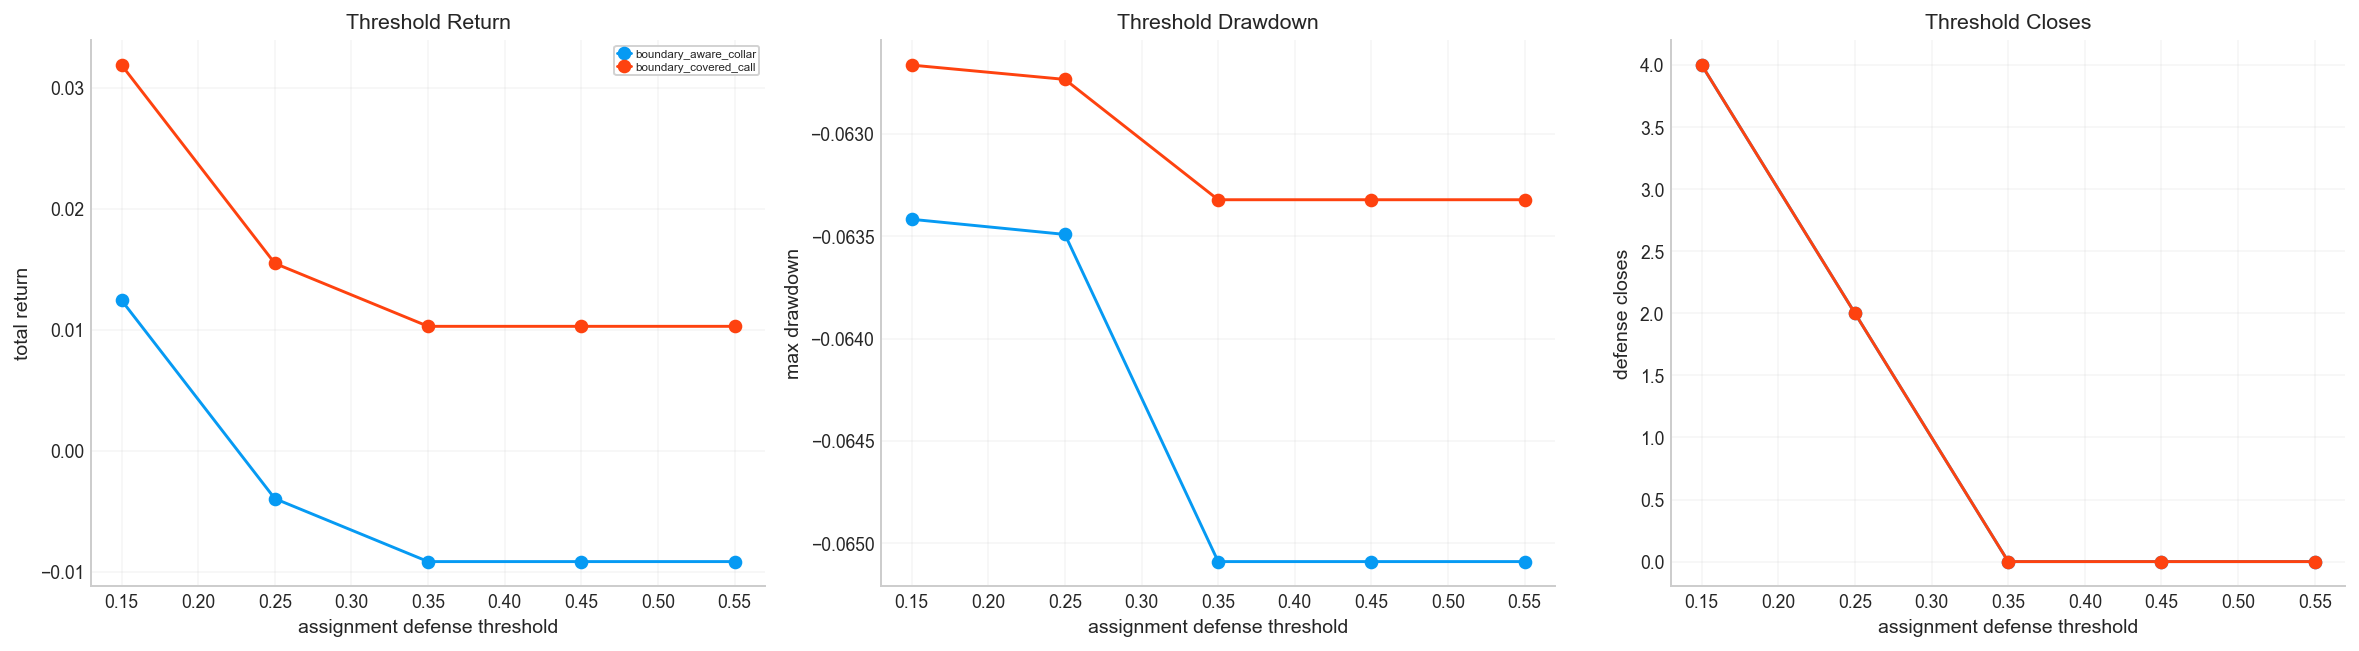

In [73]:
threshold_rows = []
aware_schedules = {k: v for k, v in overlay_schedules.items() if k in {"boundary_covered_call", "boundary_aware_collar", "buy_hold_spy"}}
for threshold in [0.15, 0.25, 0.35, 0.45, 0.55]:
    nav_t, dd_t, trades_t, cash_t, marks_t, holdings_t = run_overlay(aware_schedules, assignment_scores, spot_history, dividend_series, assignment_threshold=threshold, defense_strategies={"boundary_covered_call", "boundary_aware_collar"})
    for col in nav_t.columns:
        if col == "buy_hold_spy":
            continue
        tr = trades_t[trades_t["strategy"].eq(col)] if not trades_t.empty else pd.DataFrame()
        threshold_rows.append({"threshold": threshold, "strategy": col, "total_return": nav_t[col].iloc[-1] / nav_t[col].iloc[0] - 1.0, "max_drawdown": dd_t[col].min(), "roll_count": int(tr["event"].eq("roll_close").sum()) if not tr.empty else 0, "assignment_defense_closes": int(tr["event"].eq("assignment_defense_close").sum()) if not tr.empty else 0, "close_cost": -float(tr.loc[tr["event"].eq("assignment_defense_close"), "cashflow"].sum()) if not tr.empty else 0.0})
threshold_sensitivity = pd.DataFrame(threshold_rows)
display(threshold_sensitivity.round(6))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for strategy, group in threshold_sensitivity.groupby("strategy"):
    axes[0].plot(group["threshold"], group["total_return"], marker="o", label=strategy)
    axes[1].plot(group["threshold"], group["max_drawdown"], marker="o", label=strategy)
    axes[2].plot(group["threshold"], group["assignment_defense_closes"], marker="o", label=strategy)
axes[0].set_xlabel("assignment defense threshold")
axes[0].set_ylabel("total return")
axes[0].set_title("Threshold Return")
axes[1].set_xlabel("assignment defense threshold")
axes[1].set_ylabel("max drawdown")
axes[1].set_title("Threshold Drawdown")
axes[2].set_xlabel("assignment defense threshold")
axes[2].set_ylabel("defense closes")
axes[2].set_title("Threshold Closes")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


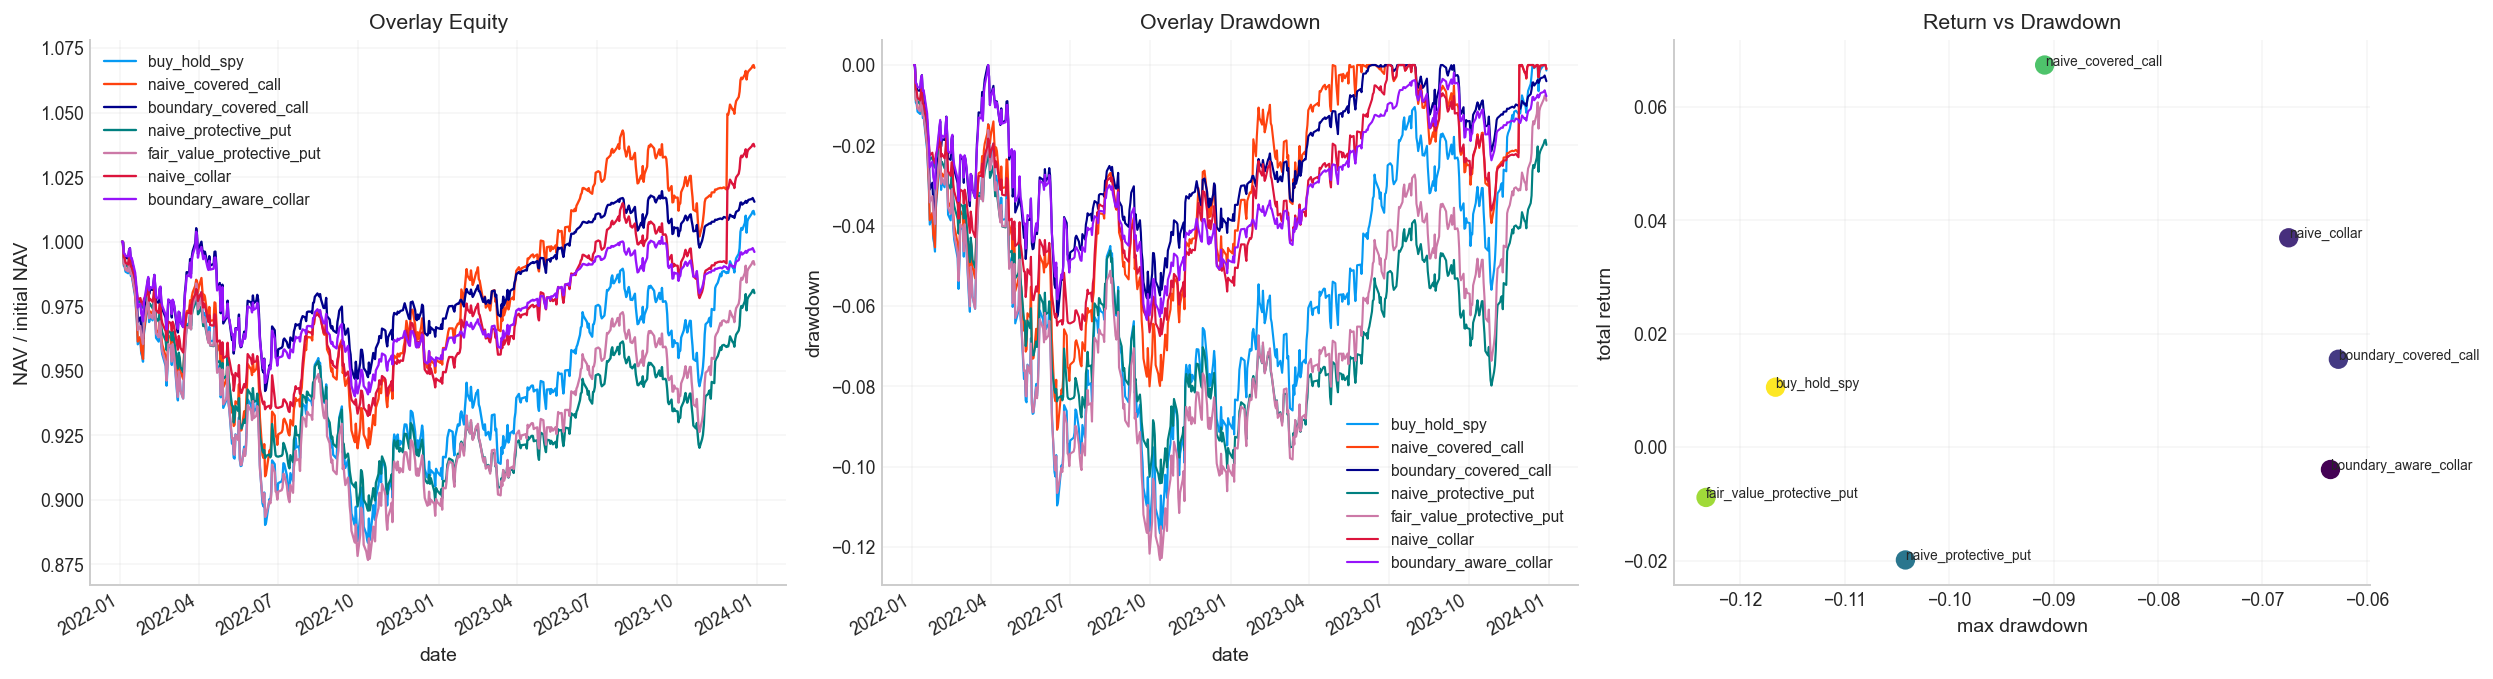

In [74]:
if "contract_key" not in assignment_scores.columns:
    assignment_scores["contract_key"] = contract_key(assignment_scores)
mark_lookup = assignment_scores[["date", "contract_key", "spot", "moneyness", "assignment_risk"]].drop_duplicates(["date", "contract_key"])
trade_marks = overlay_trades.merge(mark_lookup, on=["date", "contract_key"], how="left")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
(overlay_nav / overlay_nav.iloc[0]).plot(ax=axes[0], lw=1.2)
axes[0].set_title("Overlay Equity")
axes[0].set_xlabel("date")
axes[0].set_ylabel("NAV / initial NAV")
overlay_drawdown.plot(ax=axes[1], lw=1.1)
axes[1].set_title("Overlay Drawdown")
axes[1].set_xlabel("date")
axes[1].set_ylabel("drawdown")
axes[2].scatter(overlay_summary["max_drawdown"], overlay_summary["total_return"], s=80, c=overlay_summary["annualized_vol"], cmap="viridis")
for _, row in overlay_summary.iterrows():
    axes[2].annotate(row["strategy"], (row["max_drawdown"], row["total_return"]), fontsize=7)
axes[2].set_xlabel("max drawdown")
axes[2].set_ylabel("total return")
axes[2].set_title("Return vs Drawdown")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


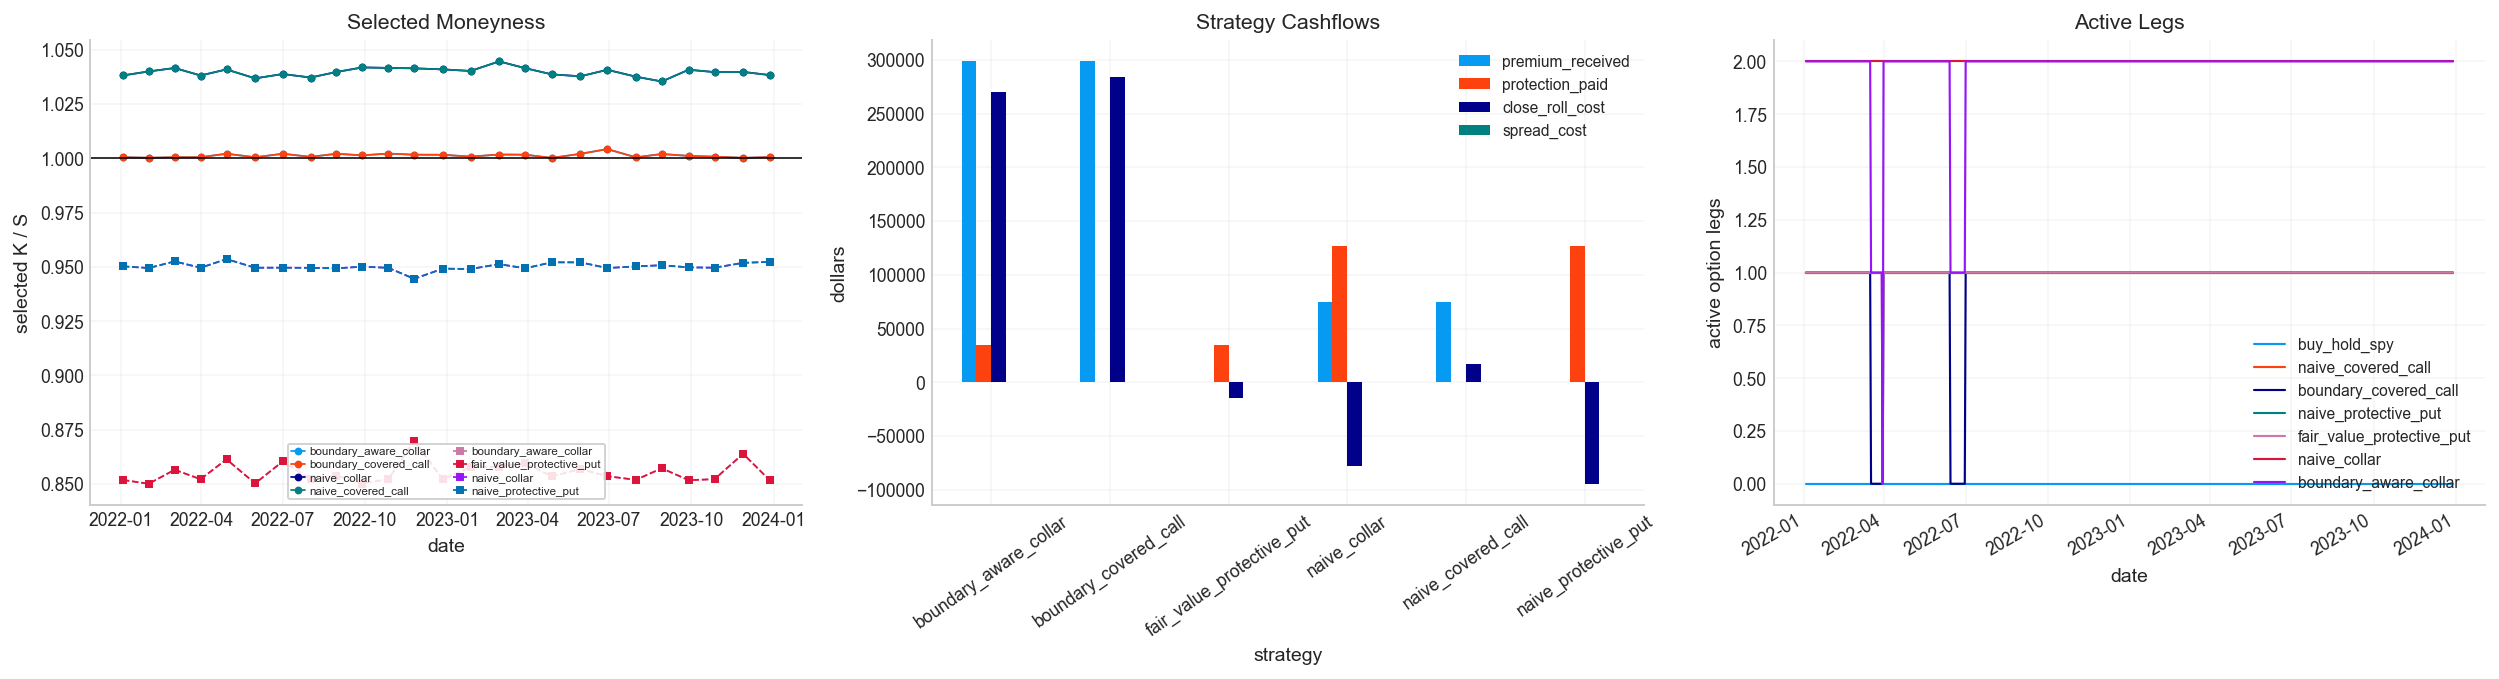

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short_calls = trade_marks[(trade_marks["event"].eq("open")) & (trade_marks["option_type"].eq("call"))].copy()
long_puts = trade_marks[(trade_marks["event"].eq("open")) & (trade_marks["option_type"].eq("put"))].copy()
for strategy, group in short_calls.groupby("strategy"):
    axes[0].plot(group["date"], group["moneyness"], marker="o", lw=0.9, ms=3, label=strategy)
for strategy, group in long_puts.groupby("strategy"):
    axes[0].plot(group["date"], group["moneyness"], marker="s", lw=0.9, ms=3, ls="--", label=strategy)
axes[0].axhline(1.0, color="black", lw=0.8)
axes[0].set_xlabel("date")
axes[0].set_ylabel("selected K / S")
axes[0].set_title("Selected Moneyness")
axes[0].legend(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35, ncol=2)
premium_parts = overlay_trades.copy()
premium_parts["premium_received"] = np.where((premium_parts["event"].eq("open")) & (premium_parts["quantity"].lt(0)), premium_parts["cashflow"], 0.0)
premium_parts["protection_paid"] = np.where((premium_parts["event"].eq("open")) & (premium_parts["quantity"].gt(0)), -premium_parts["cashflow"], 0.0)
premium_parts["close_roll_cost"] = np.where(premium_parts["event"].isin(["roll_close", "assignment_defense_close"]), -premium_parts["cashflow"], 0.0)
premium_parts["spread_cost"] = premium_parts.get("spread_cost", pd.Series(0.0, index=premium_parts.index)).fillna(0.0)
premium_summary = premium_parts.groupby("strategy")[["premium_received", "protection_paid", "close_roll_cost", "spread_cost"]].sum()
premium_summary.plot(kind="bar", ax=axes[1])
axes[1].set_xlabel("strategy")
axes[1].set_ylabel("dollars")
axes[1].set_title("Strategy Cashflows")
axes[1].tick_params(axis="x", rotation=35)
overlay_holdings.plot(ax=axes[2], lw=1.1)
axes[2].set_xlabel("date")
axes[2].set_ylabel("active option legs")
axes[2].set_title("Active Legs")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


In [76]:
project13_objects = {
    "cleaning_steps": cleaning_steps,
    "spy_quotes": spy_quotes,
    "dividend_events": dividend_events,
    "representative_contracts": representative_contracts,
    "tree_convergence": tree_convergence,
    "tree_cpp_speed": tree_cpp_speed,
    "tree_full_chain": tree_full_chain,
    "pde_validation": pde_validation,
    "pde_diagnostics": pde_summary,
    "pde_method_summary": pde_method_summary,
    "pde_full_or_regime": pde_full_or_regime,
    "lsm_path_convergence": lsm_path_convergence,
    "lsm_regime_results": lsm_regime_results,
    "method_comparison": method_comparison,
    "method_disagreement": method_disagreement,
    "assignment_scores": assignment_scores,
    "short_call_scores": short_call_scores,
    "threshold_sensitivity": threshold_sensitivity,
    "overlay_trades": overlay_trades,
    "overlay_nav": overlay_nav,
    "overlay_summary": overlay_summary,
}
object_summary = pd.DataFrame([{"name": name, "type": type(obj).__name__, "rows": len(obj) if hasattr(obj, "__len__") else np.nan, "columns": len(obj.columns) if isinstance(obj, pd.DataFrame) else np.nan} for name, obj in project13_objects.items()])
display(object_summary)


,name,type,rows,columns
0,cleaning_steps,DataFrame,8,3
1,spy_quotes,DataFrame,1839734,41
2,dividend_events,DataFrame,8,3
3,representative_contracts,DataFrame,5,42
4,tree_convergence,DataFrame,8,8
5,tree_cpp_speed,DataFrame,1,9
6,tree_full_chain,DataFrame,1839734,30
7,pde_validation,DataFrame,80,12
8,pde_diagnostics,DataFrame,4,6
9,pde_method_summary,DataFrame,3,10


,step,rows,removed
0,raw rows,1728392,NaN
1,after schema normalization,1728392,0.0
2,after positive quote filter,1625491,102901.0
3,after spread filter,1526259,99232.0
4,after DTE filter,946266,579993.0
5,after moneyness filter,876958,69308.0
6,after IV/sigma filter,811960,64998.0
7,final rows,811960,0.0


,rows,dates,expiries,contracts,median_american_premium,median_abs_pricing_error,contracts_per_sec
0,811960,256,182,42612,0.000043,0.157977,52158.909329


,pde_regime_cells,lsm_regime_cells,qqq_valid_rows,qqq_tree_rows
0,982,881,811960,811960


,strategy,final_nav,total_pnl,total_return,annualized_return,max_drawdown,downside_deviation,worst_month,best_month,trades,roll_closes,assignment_defense_closes,expiry_settlements,net_open_premium_cashflow,spread_cost,ann_vol
0,buy_hold_qqq,9.057760e+05,-94224.006104,-0.094224,-0.082131,-0.139165,0.064758,-0.050484,0.039324,0,0,0,0,NaN,NaN,0.104474
1,naive_covered_call,1.098336e+06,98335.998779,0.098336,0.084616,-0.087820,0.056714,-0.032604,0.093131,23,6,0,2,528490.0,760.0,0.122925
2,boundary_covered_call,9.954160e+05,-4584.006104,-0.004584,-0.003971,-0.073915,0.050658,-0.030930,0.026120,29,11,1,2,179610.0,435.0,0.074062
3,naive_protective_put,9.035760e+05,-96424.006104,-0.096424,-0.084061,-0.141058,0.064680,-0.050520,0.039271,17,0,0,2,-2200.0,110.0,0.104357
4,fair_value_protective_put,9.036260e+05,-96374.006104,-0.096374,-0.084018,-0.141038,0.064723,-0.050517,0.039280,17,0,0,2,-2150.0,115.0,0.104375
5,naive_collar,1.096136e+06,96135.998779,0.096136,0.082734,-0.089635,0.056610,-0.032773,0.093172,40,6,0,4,526290.0,870.0,0.122982
6,boundary_aware_collar,9.932660e+05,-6734.006104,-0.006734,-0.005834,-0.075174,0.050522,-0.030946,0.025739,46,11,1,4,177460.0,550.0,0.073933


,strategy,opens,closes,roll_closes,expiry_settlements,assignment_defense_closes,max_active_calls,max_active_puts,average_active_calls,average_active_puts,median_holding_days,median_entry_dte,median_entry_moneyness,median_option_entry_price,p95_option_entry_price,average_premium_per_open,total_premium_received,total_close_cost,total_spread_cost,total_dividends_received,net_trade_cashflow
0,buy_hold_qqq,0,0,0,0,0,0.0,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,0.0,2626.0,0.000000
1,naive_covered_call,15,6,6,2,0,10.0,0.0,8.527397,0.000000,21.0,37.333333,0.929488,26.020,90.8260,35232.666667,528490.0,181560.0,760.0,2626.0,192560.004883
2,boundary_covered_call,15,12,11,2,1,10.0,0.0,8.219178,0.000000,21.0,45.333333,1.002557,12.720,14.3330,11974.000000,179610.0,89970.0,435.0,2626.0,89640.000000
3,naive_protective_put,15,0,0,2,0,0.0,10.0,0.000000,7.773973,27.0,24.333333,0.712824,0.110,0.2630,146.666667,0.0,0.0,110.0,2626.0,-2200.000000
4,fair_value_protective_put,15,0,0,2,0,0.0,10.0,0.000000,7.773973,27.0,24.333333,0.694546,0.120,0.2460,143.333333,0.0,0.0,115.0,2626.0,-2150.000000
5,naive_collar,30,6,6,4,0,10.0,10.0,8.527397,7.773973,21.0,24.333333,0.741492,0.175,82.9285,17689.666667,528490.0,181560.0,870.0,2626.0,190360.004883
6,boundary_aware_collar,30,12,11,4,1,10.0,10.0,8.219178,7.773973,21.0,31.333333,0.872422,4.780,13.9130,6058.666667,179610.0,89970.0,550.0,2626.0,87490.000000


,contracts_per_rebalance,max_active_calls,max_active_puts,max_total_return,max_total_premium_received
0,10.0,10.0,10.0,0.098336,528490.0


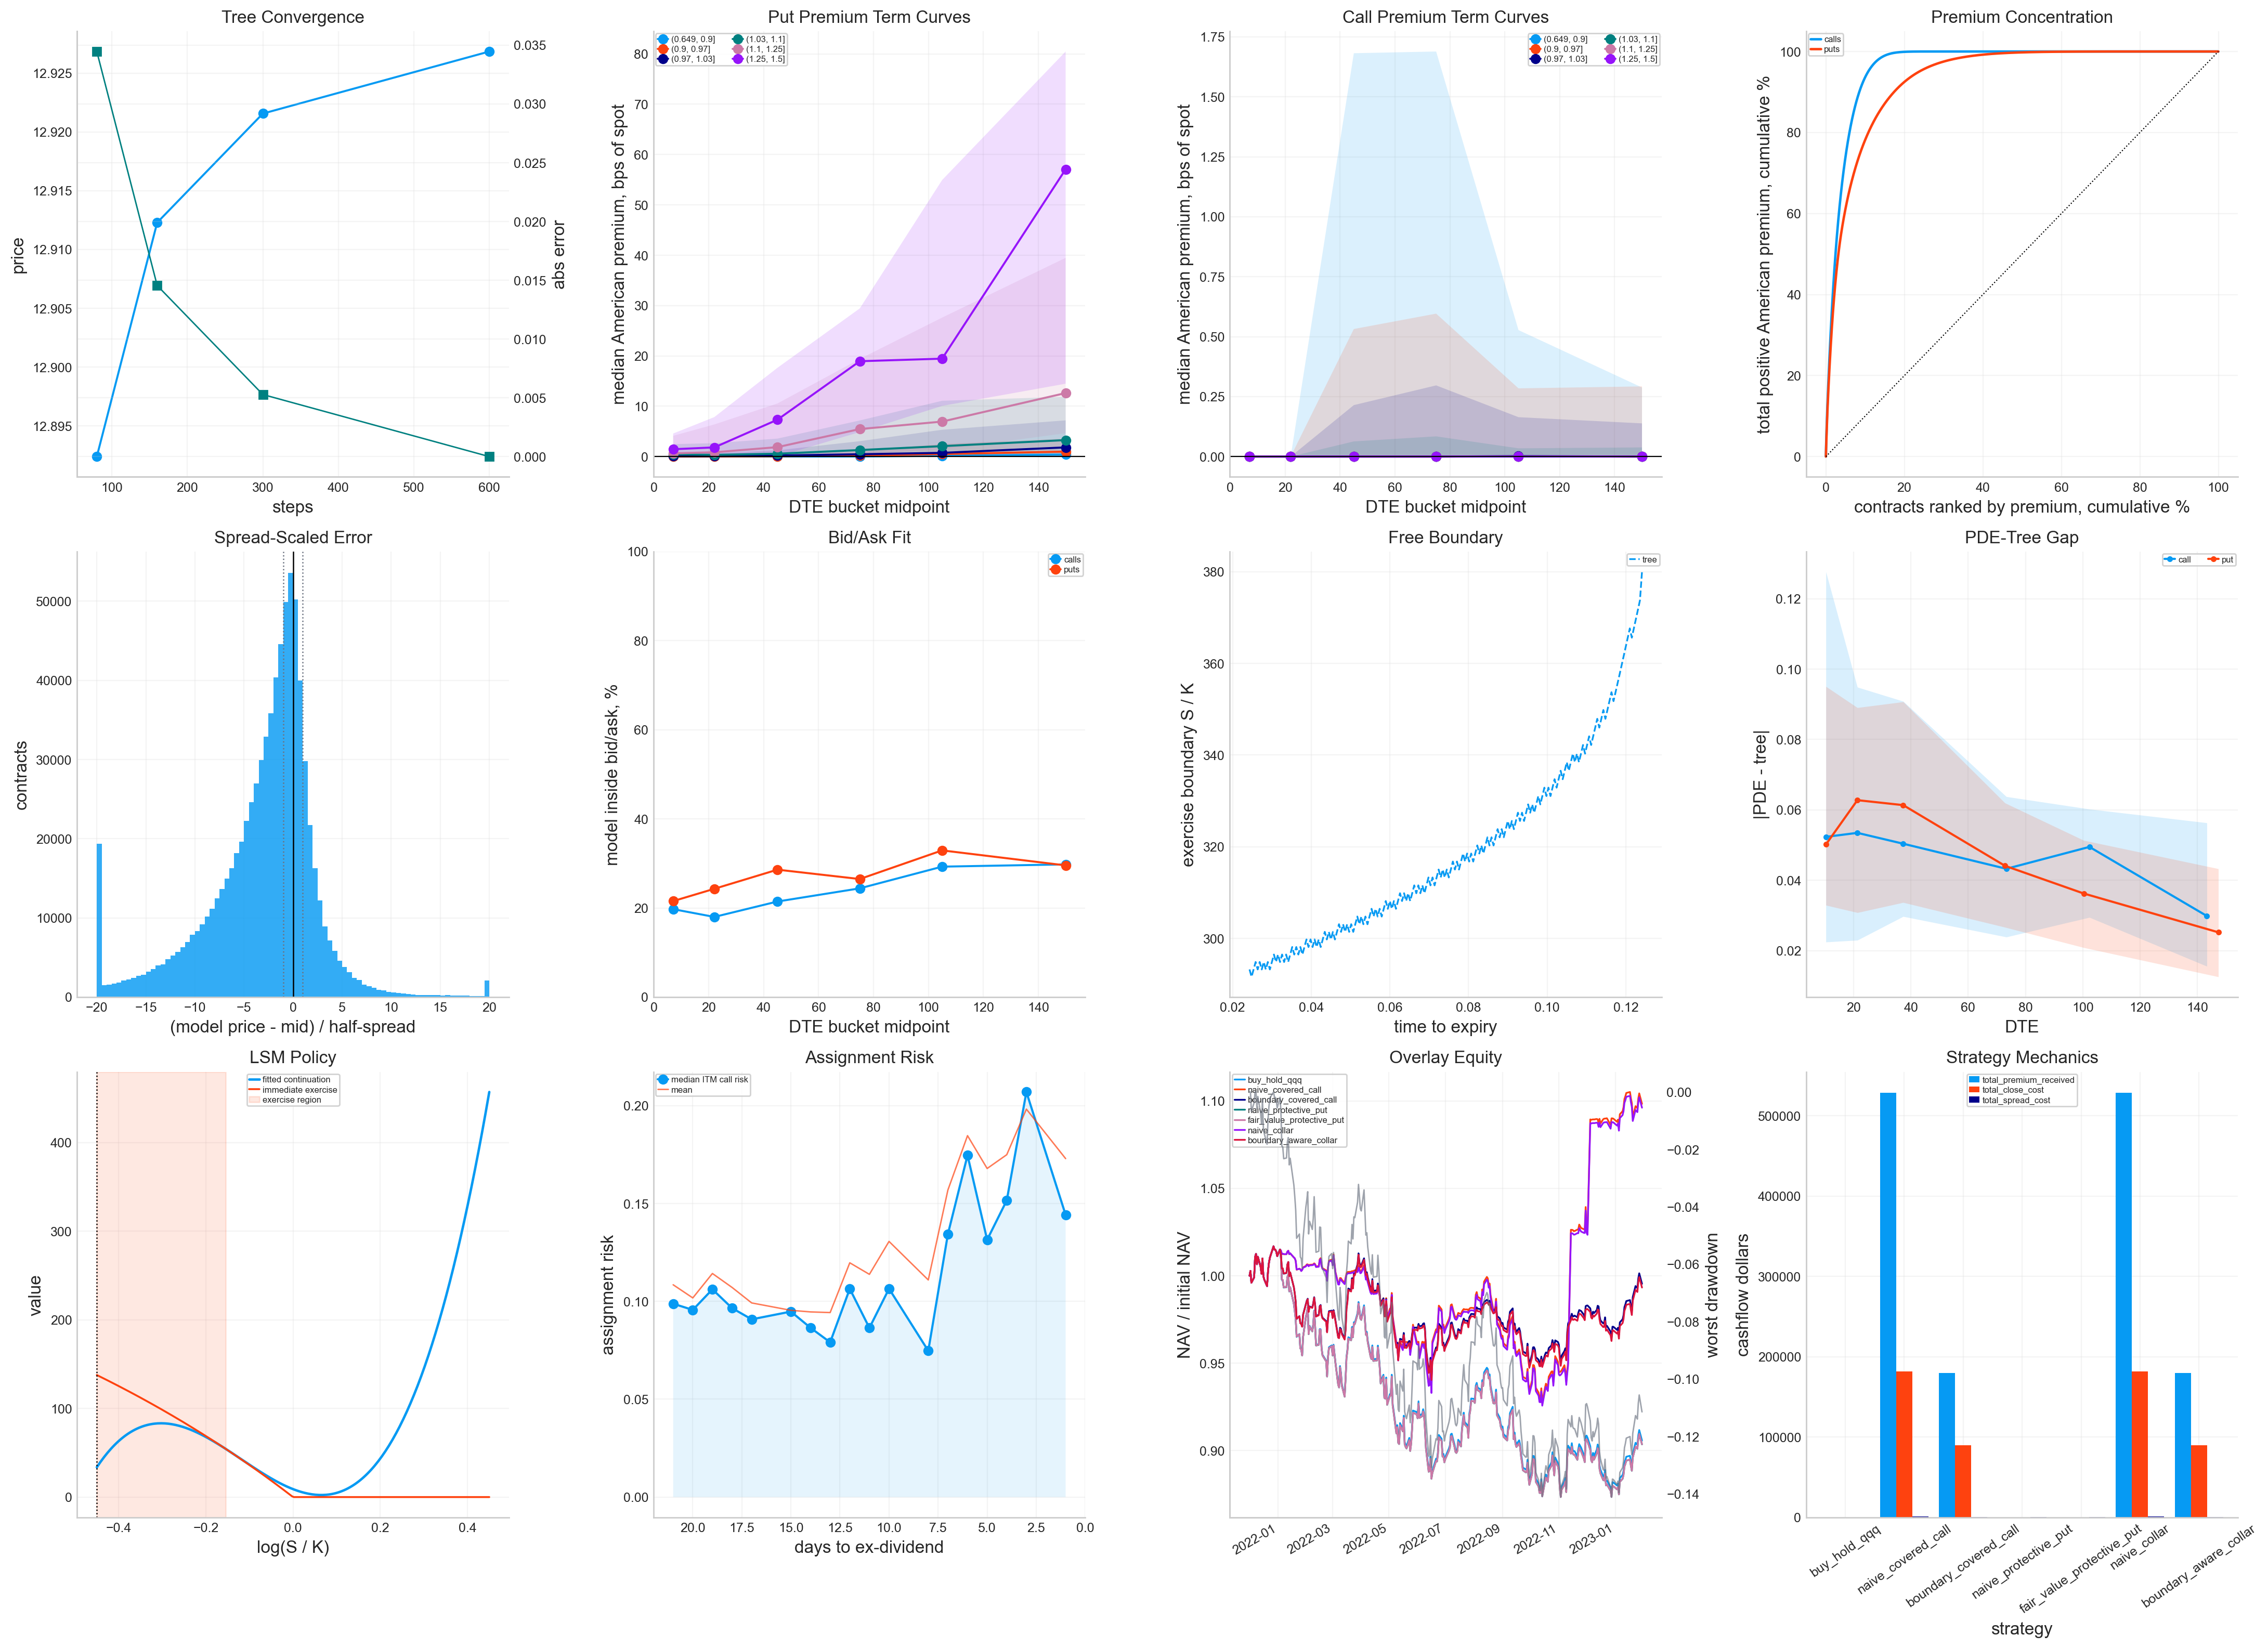

In [77]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from cycler import cycler
from quantfinlab.dataio import load_option_chain, load_par_yield_curve
from quantfinlab.fixed_income.bootstrap import build_zero_curve_panel_from_par_yields
from quantfinlab.calibration.american_numerics import prepare_american_quotes, select_teaching_contracts, full_chain_tree_scan, pde_regime_grid, american_scan_summary, overlay_candidates, method_disagreement_table
from quantfinlab.calibration.lsm import lsm_regime_grid, lsm_regime_map, lsm_crossfit
from quantfinlab.options.american import tree_batch, tree_boundary, pde_price, boundary_distance, assignment_risk
from quantfinlab.backtest.overlays import run_overlay_backtest, overlay_summary, overlay_mechanics_table, covered_call_schedule, protective_put_schedule, collar_schedule
from quantfinlab.plotting.options import tree_convergence, premium_term_curves, premium_concentration, pricing_error_spread, bid_ask_hit_rate, boundary_compare, pde_tree_gap_curves, lsm_policy_curve, assignment_event_study, overlay_equity_drawdown, strategy_mechanics_bars, overlay_return_drawdown
palette = ["#069AF3","#FE420F", "#00008B", "#008080" , "#CC79A7",
          "#9614fa", "#DC143C", "#7BC8F6", "#0072B2","#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})
project_root = Path.cwd()
data_dir = project_root / "../data"
rates_path = data_dir / "par-yield-curve-rates-1990-2026.csv"
option_columns = [
    "quote_date", "quote_readtime", "expire_date", "underlying_last", "strike",
    "c_bid", "c_ask", "p_bid", "p_ask", "c_iv", "p_iv",
    "c_delta", "p_delta", "c_gamma", "p_gamma", "c_vega", "p_vega",
    "c_theta", "p_theta", "c_volume", "p_volume",
]
qqq_cache = data_dir / "cache" / "project13" / "qqq"
qqq_cache.mkdir(parents=True, exist_ok=True)
qqq_raw = load_option_chain(data_dir / "qqq_options_chain_202201_202212.parquet", source="optionsdx_qqq", columns=option_columns)
qqq_underlying = pd.read_csv(data_dir / "qqq_yfinance.csv")
qqq_par = load_par_yield_curve(rates_path, source="us_treasury")
qqq_zero = build_zero_curve_panel_from_par_yields(qqq_par, method="pchip")
clean_quotes, clean_steps, qqq_dividends = prepare_american_quotes(qqq_raw, qqq_underlying, qqq_zero, min_dte=7, max_dte=180, moneyness_range=(0.65, 1.45), max_rel_spread=0.35)
representatives = select_teaching_contracts(clean_quotes)
tree_full = full_chain_tree_scan(clean_quotes, cache_path=qqq_cache / "qqq_tree_full_chain.parquet", settings={"dataset": "QQQ OptionsDX 2022"}, steps=300, engine="cpp", chunk_size=25000)
pde_cells = pde_regime_grid(clean_quotes, cache_path=qqq_cache / "qqq_pde_regime_grid.parquet", settings={"dataset": "QQQ OptionsDX 2022"})
lsm_cells = lsm_regime_grid(clean_quotes, dte_bins=(7, 14, 30, 60, 90, 120, 180), moneyness_bins=(0.65, 0.80, 0.90, 0.97, 1.03, 1.10, 1.25, 1.45), sigma_bins=(0.03, 0.15, 0.22, 0.32, 0.50, 2.50))
lsm_path = qqq_cache / "qqq_lsm_regime.parquet"
if lsm_path.exists():
    lsm_results = pd.read_parquet(lsm_path)
else:
    lsm_results = lsm_regime_map(lsm_cells, paths=64000, steps=40, degree=3, engine="cpp", repeats=3)
    lsm_results.to_parquet(lsm_path, index=False)
regime_keys = ["option_type", "dte_bucket", "moneyness_bucket", "sigma_bucket", "dividend_bucket", "ex_div_bucket"]
if "ex_div_bucket" not in lsm_results.columns or "lsm_price_se" not in lsm_results.columns:
    lsm_results = lsm_regime_map(lsm_cells, paths=64000, steps=40, degree=3, engine="cpp", repeats=3)
    lsm_results.to_parquet(lsm_path, index=False)
pde_price_path = qqq_cache / "qqq_pde_regime_prices.parquet"
if pde_price_path.exists():
    pde_results = pd.read_parquet(pde_price_path)
else:
    pde_rows = []
    for _, row in pde_cells.iterrows():
        pde = pde_price(row["spot"], row["strike"], row["rate"], row["dividend_yield"], row["sigma_used"], row["tau"], row["option_type"], s_steps=100, t_steps=80, engine="cpp")
        pde_rows.append({"date": row["date"], "expiry": row["expiry"], "option_type": row["option_type"], "strike": row["strike"], "pde_price": pde["price"], "pde_boundary_now": np.asarray(pde["boundary"], dtype=float)[0], "pde_max_residual": np.nanmax(pde["residuals"]), "coverage_rows": row["coverage_rows"], "dte_days": row["dte_days"], "moneyness": row["moneyness"], "sigma_used": row["sigma_used"], "dte_bucket": str(row["dte_bucket"]), "moneyness_bucket": str(row["moneyness_bucket"]), "sigma_bucket": str(row["sigma_bucket"]), "dividend_bucket": row["dividend_bucket"], "ex_div_bucket": str(row["ex_div_bucket"])} )
    pde_results = pd.DataFrame(pde_rows)
    pde_results.to_parquet(pde_price_path, index=False)
tree_for_methods = pde_results.merge(tree_full[["date", "expiry", "option_type", "strike", "american_tree_price", "european_tree_price"]], on=["date", "expiry", "option_type", "strike"], how="left")
for name in regime_keys:
    lsm_results[name] = lsm_results[name].astype(str)
lsm_for_methods = lsm_results[regime_keys + ["lsm_price", "lsm_price_se", "exercise_probability"]].drop_duplicates(subset=regime_keys)
tree_for_methods[regime_keys] = tree_for_methods[regime_keys].astype(str)
tree_for_methods = tree_for_methods.merge(lsm_for_methods, on=regime_keys, how="left")
method_comparison = method_disagreement_table(tree_for_methods.rename(columns={"american_tree_price": "tree_price"}))
method_comparison["pde_tree_disagreement"] = method_comparison["pde_price"] - method_comparison["tree_price"]
assignment_base = tree_full.copy()
assignment_base["dte_bucket"] = pd.cut(assignment_base["dte_days"], [7, 14, 30, 60, 90, 120, 180], include_lowest=True)
assignment_base["moneyness_bucket"] = pd.cut(assignment_base["moneyness"], [0.65, 0.80, 0.90, 0.97, 1.03, 1.10, 1.25, 1.45], include_lowest=True)
assignment_base["sigma_bucket"] = pd.cut(assignment_base["sigma_used"], [0.03, 0.15, 0.22, 0.32, 0.50, 2.50], include_lowest=True)
assignment_base["dividend_bucket"] = np.where(assignment_base["dividend_in_life"].gt(0), "dividend", "none")
assignment_base["ex_div_bucket"] = pd.cut(assignment_base["days_to_next_dividend"].fillna(10_000), [-1, 7, 21, 10_000], labels=["0_7", "8_21", "none"], include_lowest=True)
for name in regime_keys:
    assignment_base[name] = assignment_base[name].astype(str)
regime_method = method_comparison[regime_keys + ["pde_boundary_now", "model_disagreement"]].drop_duplicates(subset=regime_keys)
assignment_base = assignment_base.merge(regime_method, on=regime_keys, how="left")
assignment_base["boundary_distance"] = boundary_distance(assignment_base["spot"], assignment_base["pde_boundary_now"], assignment_base["option_type"])
assignment_base["model_disagreement"] = assignment_base["model_disagreement"].fillna(assignment_base["model_disagreement"].median())
assignment_scores = assignment_risk(assignment_base)
assignment_scores.loc[~assignment_scores["option_type"].astype(str).eq("call"), "assignment_risk"] = 0.0
assignment_scores["contract_key"] = assignment_scores["option_type"].astype(str) + "_" + pd.to_datetime(assignment_scores["expiry"]).dt.strftime("%Y-%m-%d") + "_" + assignment_scores["strike"].round(6).astype(str)
under = qqq_underlying.copy()
under["date"] = pd.to_datetime(under["Date"]).dt.normalize()
under = under.set_index("date").sort_index()
contracts = float(int(1000.0 // 100.0))
aware_quotes = overlay_candidates(assignment_scores)
naive_call_schedule = covered_call_schedule(assignment_scores, contracts=contracts, rebalance_every=21, target_delta=0.30)
boundary_call_schedule = covered_call_schedule(assignment_scores, contracts=contracts, rebalance_every=21, target_delta=0.25, risk_weight=2.0)
naive_put_schedule = protective_put_schedule(assignment_scores, contracts=contracts, rebalance_every=21, target_delta=0.25)
fair_put_schedule = protective_put_schedule(aware_quotes, contracts=contracts, rebalance_every=21, target_delta=0.25, value_weight=1.0)
naive_collar_schedule = collar_schedule(assignment_scores, contracts=contracts, rebalance_every=21, put_delta=0.25, call_delta=0.25)
boundary_collar_schedule = collar_schedule(aware_quotes, contracts=contracts, rebalance_every=21, put_delta=0.25, call_delta=0.20, call_risk_weight=2.0, put_value_weight=1.0)
schedules = {
    "buy_hold_qqq": pd.DataFrame(columns=["entry_date", "contract_key", "quantity", "label"]),
    "naive_covered_call": naive_call_schedule,
    "boundary_covered_call": boundary_call_schedule,
    "naive_protective_put": naive_put_schedule,
    "fair_value_protective_put": fair_put_schedule,
    "naive_collar": naive_collar_schedule,
    "boundary_aware_collar": boundary_collar_schedule,
}
overlay_results = run_overlay_backtest(schedules, assignment_scores, under["Close"], shares=1000.0, dividends=under["Dividends"], contract_multiplier=100.0, assignment_risk_threshold=0.25, assignment_defense_strategies={"boundary_covered_call", "boundary_aware_collar"})
overlay_table = overlay_summary(overlay_results)
mechanics = overlay_mechanics_table(overlay_results, shares=1000.0, dividends=under["Dividends"])
tree_table = american_scan_summary(tree_full)
short_call_final = assignment_scores[assignment_scores["option_type"].astype(str).eq("call") & assignment_scores["spot"].gt(assignment_scores["strike"])].copy()
validity = pd.DataFrame([{"contracts_per_rebalance": contracts, "max_active_calls": mechanics["max_active_calls"].max(), "max_active_puts": mechanics["max_active_puts"].max(), "max_total_return": overlay_table["total_return"].max(), "max_total_premium_received": mechanics["total_premium_received"].max()}])
display(clean_steps)
display(tree_table.round(6))
display(pd.DataFrame([{"pde_regime_cells": len(pde_results), "lsm_regime_cells": len(lsm_results), "qqq_valid_rows": len(clean_quotes), "qqq_tree_rows": len(tree_full)}]))
display(overlay_table.round(6))
display(mechanics.round(6))
display(validity.round(6))

row = representatives.iloc[0]
tb = tree_boundary(row["spot"], row["strike"], row["rate"], row["dividend_yield"], row["sigma_used"], row["tau"], row["option_type"], steps=240, engine="cpp")
pde_one = pde_price(row["spot"], row["strike"], row["rate"], row["dividend_yield"], row["sigma_used"], row["tau"], row["option_type"], s_steps=120, t_steps=90, engine="cpp")
lsm_one = lsm_crossfit(row["spot"], row["strike"], row["rate"], row["dividend_yield"], row["sigma_used"], row["tau"], row["option_type"], paths=32000, steps=40, engine="cpp")
conv = pd.DataFrame({"steps": [80, 160, 300, 600], "price": [tree_batch([row["spot"]], [row["strike"]], [row["rate"]], [row["dividend_yield"]], [row["sigma_used"]], [row["tau"]], [row["option_type"]], steps=n, engine="cpp")[0] for n in [80, 160, 300, 600]]})
conv["reference_error"] = (conv["price"] - conv["price"].iloc[-1]).abs()

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.ravel()
tree_convergence(axes[0], conv, "Tree Convergence")
premium_term_curves(axes[1], tree_full, option_type="put", title="Put Premium Term Curves")
premium_term_curves(axes[2], tree_full, option_type="call", title="Call Premium Term Curves")
premium_concentration(axes[3], tree_full, "Premium Concentration")
pricing_error_spread(axes[4], tree_full, "Spread-Scaled Error")
bid_ask_hit_rate(axes[5], tree_full, "Bid/Ask Fit")
boundary_compare(axes[6], pde_one, tb, "Free Boundary")
pde_tree_gap_curves(axes[7], method_comparison, "PDE-Tree Gap")
lsm_policy_curve(axes[8], lsm_one["coefficients"], strike=row["strike"], option_type=row["option_type"], title="LSM Policy")
assignment_event_study(axes[9], short_call_final[short_call_final["days_to_next_dividend"].between(0, 21)], "Assignment Risk")
overlay_equity_drawdown(axes[10], overlay_results, "Overlay Equity")
strategy_mechanics_bars(axes[11], mechanics, "Strategy Mechanics")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()
